# Full BNS + NSBH likelihood

This notebook runs the six-parameter joint likelihood directly. It does **not** load a BNS-only backend or use a KDE posterior as a prior. For each run, $f_j^{\rm BNS}$, the geometry-efficiency function, $\alpha_{\rm CE}$, and the NSBH population are fixed; the spectral parameters and both opening angles are sampled.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib                import Path
import matplotlib.pyplot    as plt
#plt.style.use('../../../configurations/style.mplstyle')
from montecarlo_combined import run_pop
from maggpy.top_hat.geometric_eff import create_geometric_efficiency_lognormal_interpolator
interp_ln = create_geometric_efficiency_lognormal_interpolator()
def geometric_efficiency_lognormal(theta): return interp_ln(theta)

## Run configuration

Edit `FJ_LIST` and `NSBH_POPULATIONS` before launching the chains. Every combination gets its own resumable `emcee.h5` backend.

In [38]:
from pathlib import Path

POPULATION_NAMES = {
    "F":     "fiducial",
    "F19":   "farmer19",
    "F5M":   "fiducial_5M",
    "K150":  "kick150",
    "K265":  "kick265",
    "LC":    "l01",
    "LK":    "klencki",
    "LX":    "xuli",
    "NT":    "no_tides",
    "NTC":   "no_tides_pericirc",
    "OPT":   "HG_optimistic",
    "QCBB":  "rad",
    "QCBSE": "qcbse",
    "QHE":   "qhe",
    "RBSE":  "fmtbse",
    "SND":   "delayed",
}

DATAFILES       = Path('../../datafiles')
IMAGES_FOLDER_   = Path('Images')

MRD_FOLDER = DATAFILES / "MRD_outputs"

GEOM_EFF_FUNC = geometric_efficiency_lognormal
GEOM_NAME       = GEOM_EFF_FUNC.__name__
GEOM_LABEL_DIC = {
    "geometric_efficiency_flat_midpoint"    : "midpoint",
    "geometric_efficiency_fixed"            : "fixed",
    "geometric_efficiency_lognormal"        : "lognormal",
}
GEOM_LABEL_CURRENT  = GEOM_LABEL_DIC[GEOM_NAME]

print(f"Current geometric efficiency function: {GEOM_NAME} ({GEOM_LABEL_CURRENT})")

unique_populations = [POPULATION_NAMES[p] for p in POPULATION_NAMES.keys()]
print(f"Unique populations: {unique_populations}")

POSSIBLE_ALPHAS = ['A0.5', 'A1.0', 'A3.0', 'A5.0']
NSBH_AFFIX = [
    'NSBH_DD2_uniform_chi_0_1',
    'NSBH_SFHo_uniform_chi_0_1',
]

OUTPUT_FOLDER = Path('Outputs')
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

IMAGE_FOLDER = IMAGES_FOLDER_ / GEOM_NAME # As to not overwrite previous plots with different geometric efficiency functions
IMAGE_FOLDER.mkdir(parents=True, exist_ok=True)

N_STEPS = 6000
DISCARD = 300 
FJ_LIST = [0.1, 0.5, 1.0]

Current geometric efficiency function: geometric_efficiency_lognormal (lognormal)
Unique populations: ['fiducial', 'farmer19', 'fiducial_5M', 'kick150', 'kick265', 'l01', 'klencki', 'xuli', 'no_tides', 'no_tides_pericirc', 'HG_optimistic', 'rad', 'qcbse', 'qhe', 'fmtbse', 'delayed']


## Run or resume all chains

The initial walkers are generated inside the flat-prior support; no previous chain is read. Re-running this cell resumes matching backends up to `N_STEPS`.

In [26]:
from multiprocessing import Pool
from itertools import product

combinations = list(product(unique_populations, POSSIBLE_ALPHAS, FJ_LIST, NSBH_AFFIX))

def run_arguments(pop, alpha, fj_bns, nsbh_series):
    return (
        MRD_FOLDER / f"{pop}_{alpha.replace('.', '_')}_BNS.csv",
        MRD_FOLDER / f"{pop}_{alpha.replace('.', '_')}_{nsbh_series}.csv",
        fj_bns,
        GEOM_EFF_FUNC,
        DATAFILES,
        OUTPUT_FOLDER / f"{pop}_{alpha.replace('.', '_')}_{nsbh_series}_fj{fj_bns}_{GEOM_LABEL_CURRENT}",
        1,
        24,
        N_STEPS,
    )

total_number_of_combinations = len(combinations)
completed = 0
print(f"Running {total_number_of_combinations} combinations")

def progress(_result):
    global completed
    completed += 1
    print(f"{completed}/{total_number_of_combinations}", end=' ', flush=True)

def report_error(error):
    print(f"\nWorker failed: {error!r}", flush=True)

def run_pop_wrapper(*args, **kwargs):
    # so run_pop returns the sampler that is not pickleable, we wrap it in a function that returns None
    _ = run_pop(*args, **kwargs)
    return None

with Pool() as pool:
    jobs = [
        pool.apply_async(
            run_pop_wrapper,
            args=run_arguments(pop, alpha, fj_bns, nsbh_series),
            callback=progress,
            error_callback=report_error,
        )
        for pop, alpha, fj_bns, nsbh_series in combinations
    ]
    pool.close()
    pool.join()

print("\nAll submitted jobs finished.")

Running 384 combinations
1/384 2/384 3/384 4/384 5/384 6/384 7/384 8/384 9/384 10/384 11/384 12/384 13/384 14/384 15/384 16/384 17/384 18/384 19/384 20/384 21/384 22/384 23/384 24/384 25/384 26/384 27/384 28/384 29/384 30/384 31/384 32/384 33/384 34/384 35/384 36/384 37/384 38/384 39/384 40/384 41/384 42/384 43/384 44/384 45/384 46/384 47/384 48/384 49/384 50/384 51/384 52/384 53/384 54/384 55/384 56/384 57/384 58/384 59/384 60/384 61/384 62/384 63/384 64/384 65/384 66/384 67/384 68/384 69/384 70/384 71/384 72/384 73/384 74/384 75/384 76/384 77/384 78/384 79/384 80/384 81/384 82/384 83/384 84/384 85/384 86/384 87/384 88/384 89/384 90/384 91/384 92/384 93/384 94/384 95/384 96/384 97/384 98/384 99/384 100/384 101/384 102/384 103/384 104/384 105/384 106/384 107/384 108/384 109/384 110/384 111/384 112/384 113/384 114/384 115/384 116/384 117/384 118/384 119/384 120/384 121/384 122/384 123/384 124/384 125/384 126/384 127/384 128/384 129/384 130/384 131/384 132/384 133/384 134/384 135/384 136

# Plotting

In [56]:
import numpy as np
import pandas as pd
import emcee

eta_dict = {}

def local_rates(mrd_bns_path, mrd_nsbh_path):
    mrd_bns     = pd.read_csv(mrd_bns_path)
    mrd_nsbh    = pd.read_csv(mrd_nsbh_path)
    return mrd_bns.values[0], mrd_nsbh.values[0]

for pop, alpha, fj_bns, nsbh_series in combinations:
    mrd_bns_path        = MRD_FOLDER / f"{pop}_{alpha.replace('.', '_')}_BNS.csv"
    mrd_nsbh_path       = MRD_FOLDER / f"{pop}_{alpha.replace('.', '_')}_{nsbh_series}.csv"

    backend_dir         = OUTPUT_FOLDER / f"{pop}_{alpha.replace('.', '_')}_{nsbh_series}_fj{fj_bns}_{GEOM_LABEL_CURRENT}"
    backend_emcee       = emcee.backends.HDFBackend(backend_dir / "mcmc_run.h5")
    blobs               = backend_emcee.get_blobs() 
    nsbh_contributions  = blobs["predicted_nsbh"]
    bns_contributions   = blobs["predicted_bns"]
    total_contributions = nsbh_contributions + bns_contributions

    valid               = total_contributions > 0
    nsbh_contributions  = nsbh_contributions[valid]
    bns_contributions   = bns_contributions[valid]
    total_contributions = total_contributions[valid]

    eta_nsbh            = nsbh_contributions / total_contributions
    eta_bns             = bns_contributions / total_contributions

    e_bns_50, e_bns_05, e_bns_95 = np.percentile(eta_bns, [50, 5, 95])
    e_nsbh_50, e_nsbh_05, e_nsbh_95 = np.percentile(eta_nsbh, [50, 5, 95])

    bns_local_rate, nsbh_local_rate_cut = local_rates(mrd_bns_path, mrd_nsbh_path)

    mrd_nsbh_path_uncut = MRD_FOLDER / (
        f"{pop}_{alpha.replace('.', '_')}_NSBH_uncut.csv"
    )
    _, nsbh_local_rate_uncut = local_rates(mrd_bns_path, mrd_nsbh_path_uncut)

    eta_dict[(pop, alpha, fj_bns, nsbh_series)] = {
        "eta_bns": (e_bns_50, e_bns_05, e_bns_95),
        "eta_nsbh": (e_nsbh_50, e_nsbh_05, e_nsbh_95),
        "bns_local_rate": bns_local_rate,
        "nsbh_local_rate": nsbh_local_rate_uncut,
        "nsbh_local_rate_cut": nsbh_local_rate_cut,
    }

In [57]:
GWTC_ONLY       = True   # False = include all models regardless of GWTC compatibility
MODEL_GROUP     = "problematic"     # "all" | "problematic" | "okay"

LOG_NORMAL_COMPATIBLE = {
    "fiducial":        {"A0.5": True,  "A1.0": True,  "A3.0": True,  "A5.0": True},
    "kick265":         {"A0.5": False, "A1.0": True,  "A3.0": True,  "A5.0": False},
    "kick150":         {"A0.5": True,  "A1.0": True,  "A3.0": True,  "A5.0": True},
    "qcbse":           {"A0.5": False, "A1.0": True,  "A3.0": False, "A5.0": False},
    "rad":             {"A0.5": True,  "A1.0": True,  "A3.0": True,  "A5.0": False},
    "fmtbse":          {"A0.5": False, "A1.0": True,  "A3.0": True,  "A5.0": False},
    "klencki":         {"A0.5": False, "A1.0": False, "A3.0": True,  "A5.0": True},
    "l01":             {"A0.5": False, "A1.0": True,  "A3.0": True,  "A5.0": True},
    "xuli":            {"A0.5": False, "A1.0": False, "A3.0": True,  "A5.0": True},
    "HG_optimistic":   {"A0.5": False, "A1.0": True,  "A3.0": True,  "A5.0": False},
    "farmer19":        {"A0.5": True,  "A1.0": True,  "A3.0": True,  "A5.0": True},
    "fiducial_5M":     {"A0.5": True,  "A1.0": True,  "A3.0": True,  "A5.0": True},
    "delayed":         {"A0.5": True,  "A1.0": True,  "A3.0": True,  "A5.0": True},
    "qhe":             {"A0.5": True,  "A1.0": True,  "A3.0": True,  "A5.0": True},
    "no_tides":        {"A0.5": True,  "A1.0": True,  "A3.0": True,  "A5.0": True},
    "no_tides_pericirc": {"A0.5": True, "A1.0": True, "A3.0": True, "A5.0": True},
}

selected_populations = unique_populations

def model_is_problematic(pop, alpha):
    vals = LOG_NORMAL_COMPATIBLE.get(pop, {})
    return bool(vals) and vals.get(alpha, False) is False

In [58]:
# BNS local rate x, vs eta_nsbh error bars y
# fig1
ETA_THRESHOLD   = 0.5
GWTC_5          = [5.1, 154.7]
GWTC_5_NSBH     = [6.7, 32.8]
FONTSIZE        = 16
#change default font size
plt.rcParams.update({'font.size': FONTSIZE})
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

ALPHA_COLORS = {
    "0.5": "darkblue",
    "1.0": "blueviolet",
    "3.0": "palevioletred",
    "5.0": "sandybrown",
}

models = sorted(unique_populations)
markers = Line2D.filled_markers
MODEL_MARKERS = {
    pop: markers[i % len(markers)]
    for i, pop in enumerate(models)
}

alpha_handles = [
Line2D(
    [0], [0],
    marker="o",
    color="none",
    markerfacecolor=ALPHA_COLORS[key],
    markeredgecolor=ALPHA_COLORS[key],
    markersize=10,
    label=rf"$\alpha_{{\rm CE}} = {key}$",
)
for key in ["5.0", "3.0", "1.0", "0.5"]
]

model_handles = [
    Line2D(
        [0], [0],
        marker=MODEL_MARKERS[pop],
        color="black",
        linestyle="None",
        markersize=10,
        label=pop,
    )
    for pop in models
]

maximum_bns_local_rate = max(
    data["bns_local_rate"][1]
    for data in eta_dict.values()
)
minimum_bns_local_rate = min(
    data["bns_local_rate"][1]
    for data in eta_dict.values()
)

# make a function to simplify 
def save_figure(fig, filename, fj_bsn, gwtc_only=GWTC_ONLY, model_group=MODEL_GROUP):
    # change folder based on the flat first GWTC-5 Y/N then all, problematic, okay
    if gwtc_only:
        folder = IMAGE_FOLDER / "gw_GWTC"
    else:
        folder = IMAGE_FOLDER / "gw_all"
    # append model group to create a subfolder
    folder = folder / model_group
    folder.mkdir(parents=True, exist_ok=True)
    file = folder / f"{filename}_{GEOM_LABEL_CURRENT}_{fj_bsn}.pdf" # no need to add GWTC or model group to the filename, since they are already in the folder name
    fig.savefig(file, dpi=300, bbox_inches='tight')

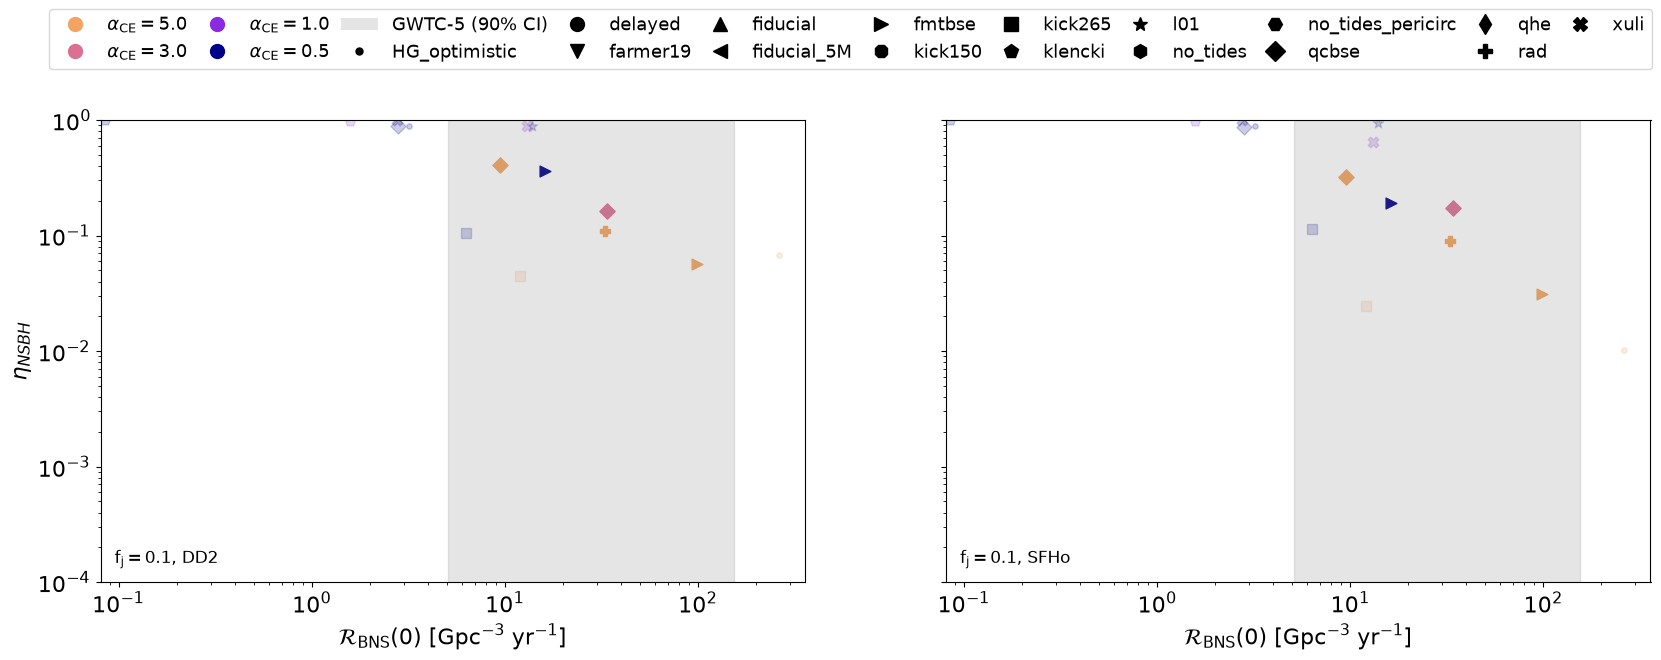

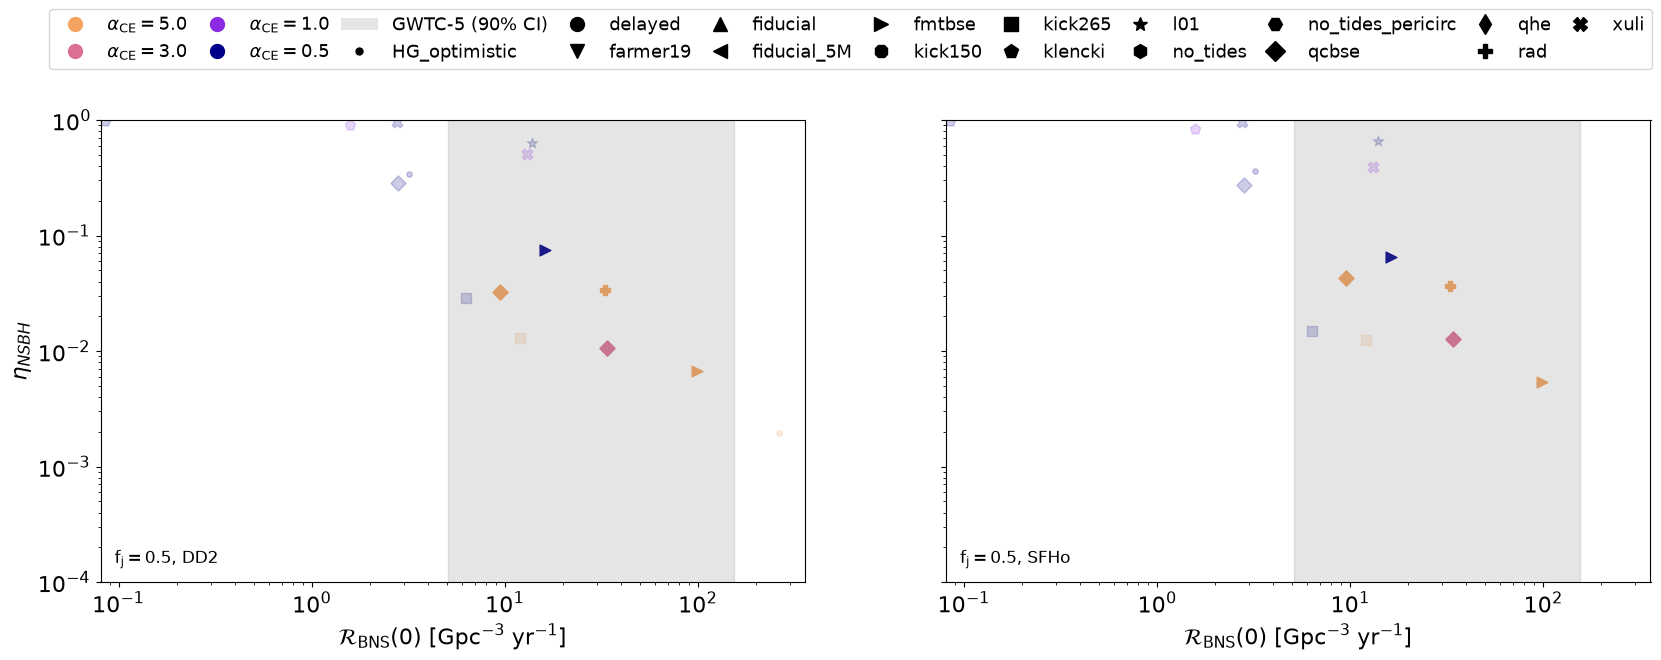

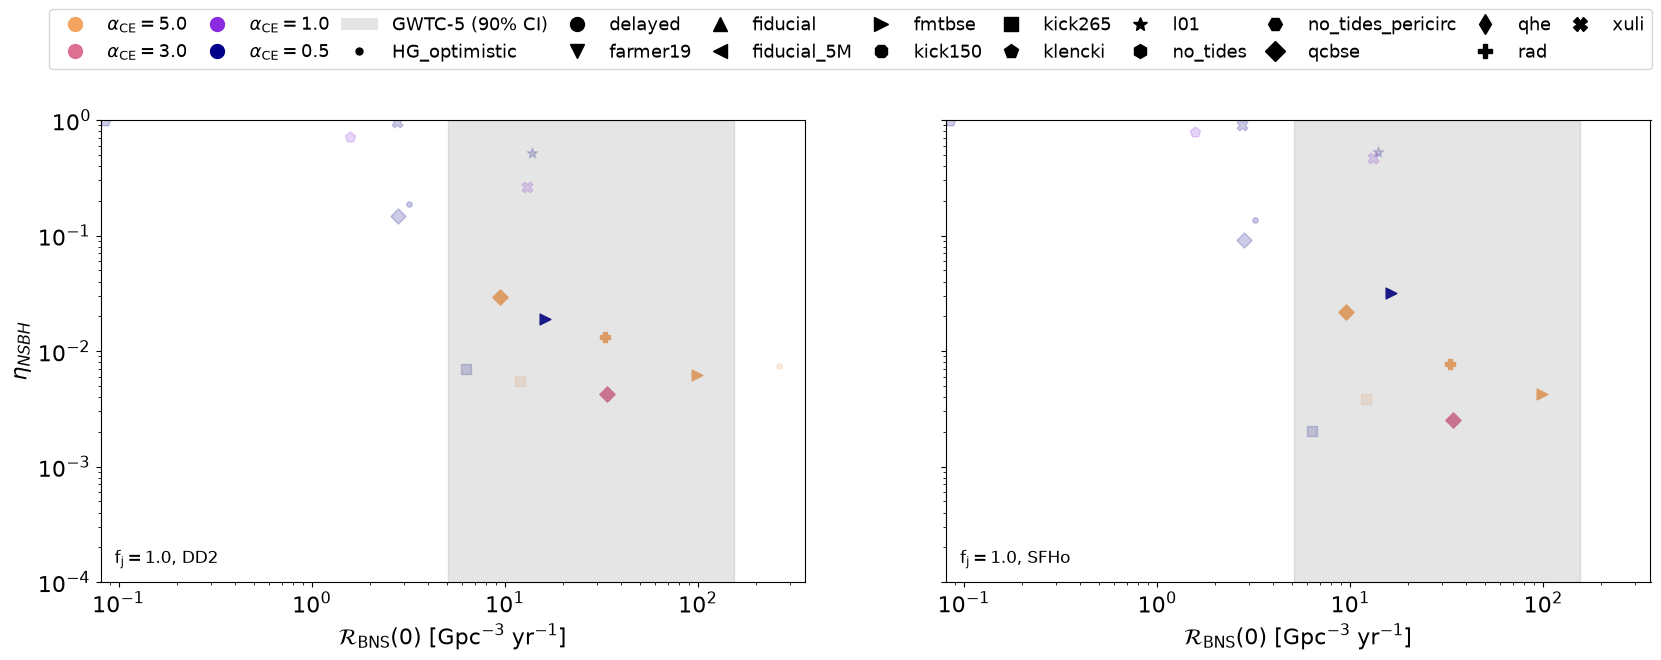

In [59]:
GWTC_ONLY_el   = True   # False = include all models regardless of GWTC compatibility
MODEL_GROUP_el = "problematic"  # "all" | "problematic" | "okay"

for fj_bsn in FJ_LIST:
    fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
    nsbh_index = {nsbh_series: i for i, nsbh_series in enumerate(NSBH_AFFIX)}
    for pop, alpha, nsbh_series in product(selected_populations, POSSIBLE_ALPHAS, NSBH_AFFIX):
        key = (pop, alpha, fj_bsn, nsbh_series)
        data = eta_dict[key]
        bns_local_rate = data["bns_local_rate"][1] # it gives z_local and mrd_local
        nsbh_local_rate = data["nsbh_local_rate"][1]
        eta_nsbh_50, eta_nsbh_05, eta_nsbh_95 = data["eta_nsbh"]

        alpha_key = str(alpha).replace("_", ".").replace("A", "")
        color=ALPHA_COLORS[alpha_key],
        marker=MODEL_MARKERS[pop],

        # so both need to be compatible with GWTC-5, otherwise opacity is 0.2
        GW_BNS_cond     = GWTC_5[0] <= bns_local_rate <= GWTC_5[1]
        GW_NSBH_cond    = GWTC_5_NSBH[0] <= nsbh_local_rate <= GWTC_5_NSBH[1]
        GW_cond         = GW_BNS_cond and GW_NSBH_cond
        if GWTC_ONLY_el and not GW_cond: opacity = 0.2 
        else: opacity = 1.0

        if MODEL_GROUP_el == "problematic" and not model_is_problematic(pop, alpha): continue
        if MODEL_GROUP_el == "okay" and model_is_problematic(pop, alpha): continue
        if MODEL_GROUP_el == "all": pass # not really necessary, but for clarity

        #only the median
        axes[nsbh_index[nsbh_series]].scatter(
            bns_local_rate,
            eta_nsbh_50,
            marker=MODEL_MARKERS[pop],
            color=ALPHA_COLORS[alpha_key],
            alpha=opacity,
            s=60,
        )

    #add bottom left text for fj and EOS
    axes[0].text(0.02, 0.03, rf'$\rm f_j = {fj_bsn}$, DD2', transform=axes[0].transAxes, fontsize=FONTSIZE-4, verticalalignment='bottom', horizontalalignment='left')
    axes[1].text(0.02, 0.03, rf'$\rm f_j = {fj_bsn}$, SFHo', transform=axes[1].transAxes, fontsize=FONTSIZE-4, verticalalignment='bottom', horizontalalignment='left')

    axes[0].fill_between(GWTC_5, [0, 0], [1, 1], color='gray', alpha=0.2)
    axes[1].fill_between(GWTC_5, [0, 0], [1, 1], color='gray', alpha=0.2)
    axes[0].set_yscale('log')
    axes[0].set_ylim(1e-4, 1)
    axes[0].set_xlim(minimum_bns_local_rate * 0.95, maximum_bns_local_rate * 1.05)
    axes[1].set_xlim(minimum_bns_local_rate * 0.95, maximum_bns_local_rate * 1.05)
    axes[0].set_xscale('log')
    axes[1].set_xscale('log')
    axes[0].set_xlabel(r"$\mathcal{R}_{\rm BNS}(0)$ [Gpc$^{-3}$ yr$^{-1}$]")
    axes[1].set_xlabel(r"$\mathcal{R}_{\rm BNS}(0)$ [Gpc$^{-3}$ yr$^{-1}$]")
    axes[0].set_ylabel(r"$\eta_{NSBH}$")

    gwtc_rect = Rectangle((GWTC_5[0], 0), GWTC_5[1] - GWTC_5[0], 1, facecolor='gray', alpha=0.2, label='GWTC-5 (90% CI)')
    fig.legend(
        handles=alpha_handles + [gwtc_rect] + model_handles,
        loc="upper center",
        ncol=11,
        bbox_to_anchor=(0.5, 1.08),
        fontsize=FONTSIZE - 3,
        columnspacing=0.6
    )
    save_figure(fig, f"eta_nsbh_vs_bns_local_rate", fj_bsn, gwtc_only=GWTC_ONLY_el, model_group=MODEL_GROUP_el)
    plt.show()

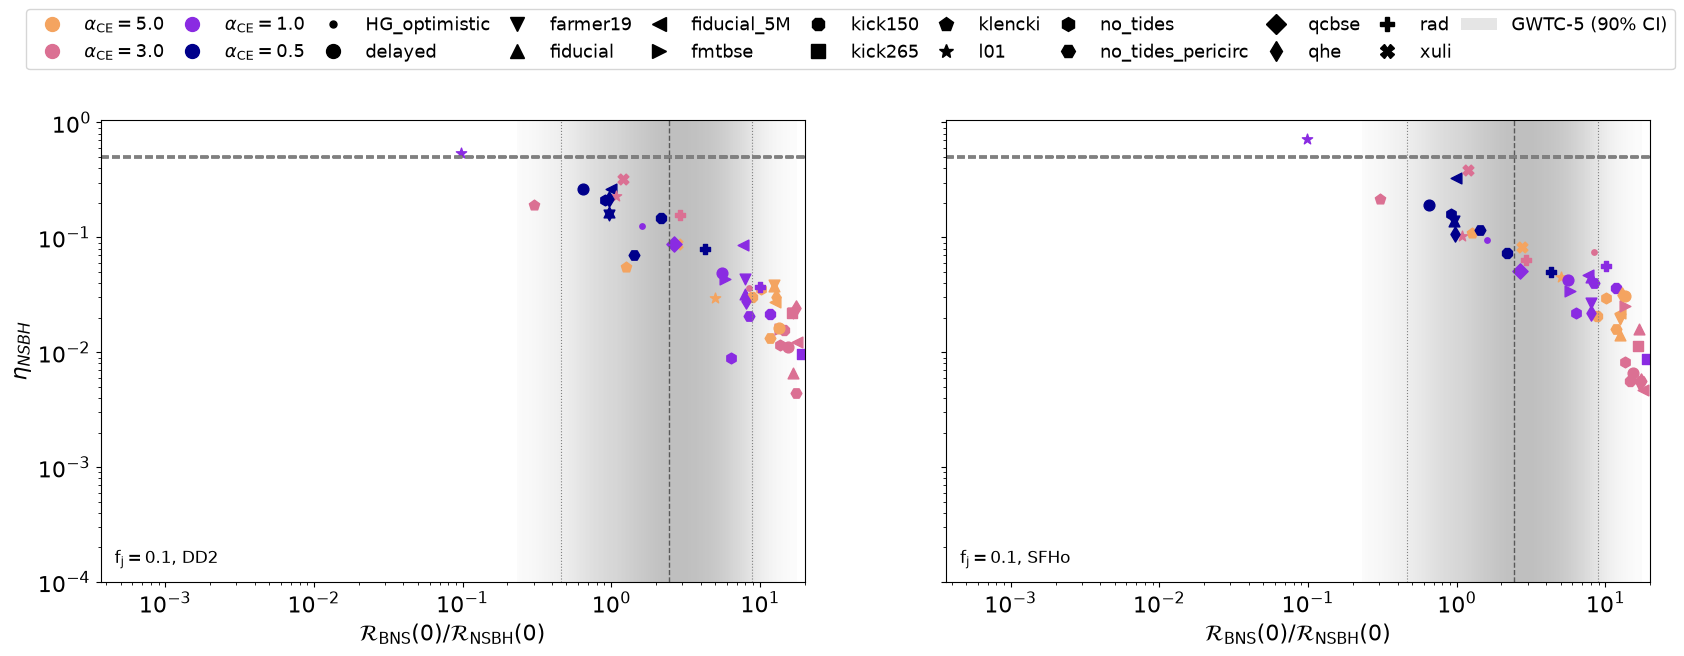

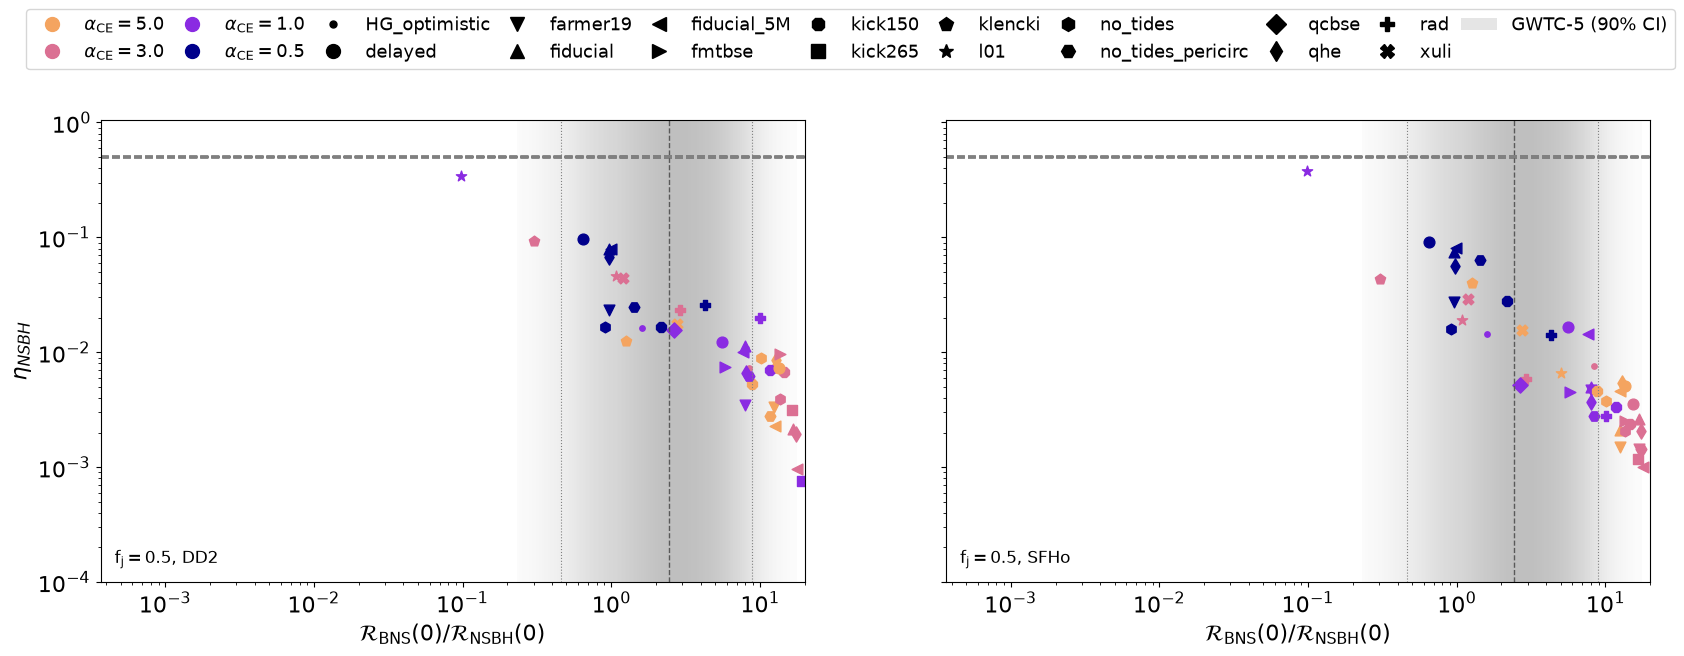

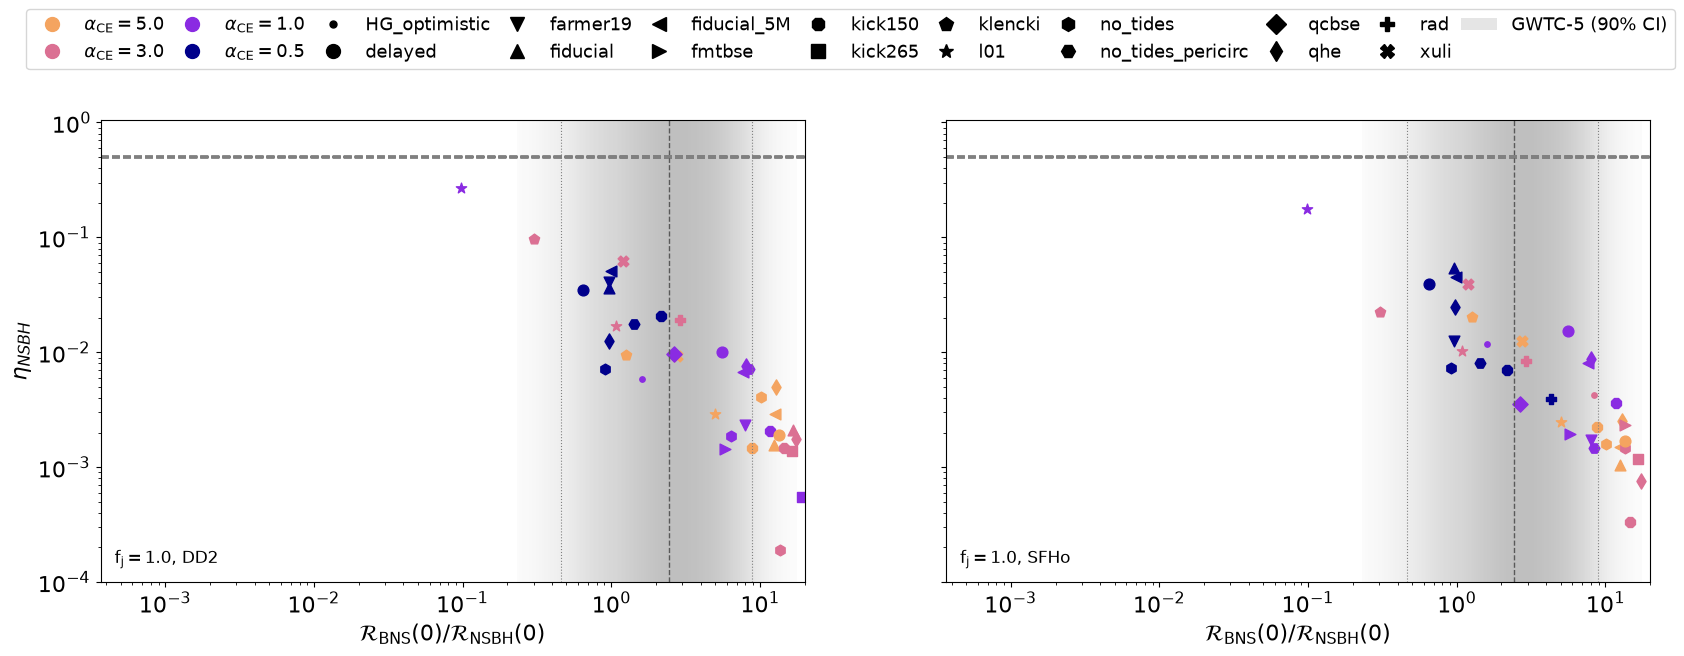

In [60]:
# Ratio BNS / NSBH local rates vs eta_nsbh error bars
#fig 2
minimum_rate_ratio = min(
    data["bns_local_rate"][1] / data["nsbh_local_rate"][1]
    for data in eta_dict.values()
)
maximum_rate_ratio = max(
    data["bns_local_rate"][1] / data["nsbh_local_rate"][1]
    for data in eta_dict.values()
)

def prep_ratio_posterior():
    ratio_posterior_path = "combined_ratio_posterior.csv"
    ratio_posterior_df = pd.read_csv(ratio_posterior_path)
    ratio_data  = ratio_posterior_df["R_BNS_over_R_NSBH"].values
    weight_data = ratio_posterior_df["weight"].values #gives weight of the individual sample, so we can use it to make a gradient for the scatter plot
    import numpy as np
    from scipy.stats import gaussian_kde
    from matplotlib.colors import LinearSegmentedColormap

    r = np.asarray(ratio_data, dtype=float)
    w = np.asarray(weight_data, dtype=float)

    if not np.all(
        np.isfinite(r) & (r > 0) & np.isfinite(w) & (w >= 0)
    ):
        raise ValueError("Require positive finite ratios and nonnegative finite weights.")

    # Remove samples with zero probability weight.
    keep = w > 0
    r, w = r[keep], w[keep]
    if len(r) < 2:
        raise ValueError("Need at least two samples with positive weights.")

    w = w / w.max()
    w = w / w.sum()

    # Weighted empirical quantiles.
    order = np.argsort(r)
    cdf = np.cumsum(w[order])
    cdf /= cdf[-1]
    q05, q50, q95 = r[order][
        np.searchsorted(cdf, [0.05, 0.50, 0.95])
    ]

    # Fit ALL samples in log space; display only the central 90%.
    log_edges = np.linspace(np.log10(q05*0.5), np.log10(q95*2), 601)
    ratio_edges = 10**log_edges
    log_centers = 0.5 * (log_edges[:-1] + log_edges[1:])
    density = gaussian_kde(np.log10(r), weights=w)(log_centers)

    # Gray opacity increases with relative density.
    ratio_cmap = LinearSegmentedColormap.from_list(
        "ratio_gray",
        [(0.35, 0.35, 0.35, 0.0), (0.35, 0.35, 0.35, 0.38)]
    )
    return ratio_edges, density, q05, q50, q95, ratio_cmap

ratio_edges, density, q05, q50, q95, ratio_cmap = prep_ratio_posterior()

GWTC_ONLY_er   = False   # False = include all models regardless of GWTC compatibility
MODEL_GROUP_er = "okay"  # "all" | "problematic" | "okay"

for fj_bsn in FJ_LIST:
    fig, axes = plt.subplots(1, len(NSBH_AFFIX), figsize=(10 * len(NSBH_AFFIX), 6), sharey=True)
    nsbh_index = {nsbh_series: i for i, nsbh_series in enumerate(NSBH_AFFIX)}
    for pop, alpha, nsbh_series in product(selected_populations, POSSIBLE_ALPHAS, NSBH_AFFIX):
        key = (pop, alpha, fj_bsn, nsbh_series)
        data = eta_dict[key]
        bns_local_rate = data["bns_local_rate"][1]
        nsbh_local_rate = data["nsbh_local_rate"][1]
        eta_nsbh_50, eta_nsbh_05, eta_nsbh_95 = data["eta_nsbh"]

        rate_ratio = bns_local_rate / nsbh_local_rate
        alpha_key = str(alpha).replace("_", ".").replace("A", "")
        
        GW_BNS_cond     = GWTC_5[0] <= bns_local_rate <= GWTC_5[1]
        GW_NSBH_cond    = GWTC_5_NSBH[0] <= nsbh_local_rate <= GWTC_5_NSBH[1]
        GW_cond         = GW_BNS_cond and GW_NSBH_cond
        if GWTC_ONLY_er and not GW_cond: opacity = 0.2 
        else: opacity = 1.0

        if MODEL_GROUP_er == "problematic" and not model_is_problematic(pop, alpha): continue
        if MODEL_GROUP_er == "okay" and model_is_problematic(pop, alpha): continue
        if MODEL_GROUP_er == "all": pass # not really necessary, but for clarity

        color=ALPHA_COLORS[alpha_key],
        marker=MODEL_MARKERS[pop],

        #only the median
        k = nsbh_index[nsbh_series]
        axes[k].scatter(
            rate_ratio,
            eta_nsbh_50,
            marker=MODEL_MARKERS[pop],
            color=ALPHA_COLORS[alpha_key],
            alpha=opacity,
            s=60
        )
        #horizontal line at eta_nsbh = threshold
        axes[k].axhline(y=ETA_THRESHOLD, color='gray', linestyle='--', alpha=0.8)

    # make a grey rect for the legend
    handle_gwtc_5 = Rectangle((0, 0), 1, 1, facecolor='gray', alpha=0.2, label='GWTC-5 (90% CI)')

    fig.legend(
        handles=alpha_handles + model_handles + [handle_gwtc_5],
        loc="upper center",
        ncol=11,
        bbox_to_anchor=(0.5, 1.08),
        fontsize=FONTSIZE - 3,
        columnspacing=0.5
    )
    axes[0].text(0.02, 0.03, rf'$\rm f_j = {fj_bsn}$, DD2', transform=axes[0].transAxes, fontsize=FONTSIZE-4, verticalalignment='bottom', horizontalalignment='left')
    axes[1].text(0.02, 0.03, rf'$\rm f_j = {fj_bsn}$, SFHo', transform=axes[1].transAxes, fontsize=FONTSIZE-4, verticalalignment='bottom', horizontalalignment='left')
    axes[0].set_yscale('log')
    axes[0].set_ylim(1e-4, 1.05)
    axes[0].set_xlim(minimum_rate_ratio * 0.95, maximum_rate_ratio * 1.05)
    axes[1].set_xlim(minimum_rate_ratio * 0.95, maximum_rate_ratio * 1.05)
    axes[0].set_xscale('log')
    axes[1].set_xscale('log')
    axes[0].set_xlabel(r"$\mathcal{R}_{\rm BNS}(0) / \mathcal{R}_{\rm NSBH}(0)$")
    axes[1].set_xlabel(r"$\mathcal{R}_{\rm BNS}(0) / \mathcal{R}_{\rm NSBH}(0)$")
    axes[0].set_ylabel(r"$\eta_{NSBH}$")

    for ax in np.atleast_1d(axes).ravel():
        ax.pcolormesh(
            ratio_edges, [0, 1], density[None, :],
            transform=ax.get_xaxis_transform(),
            cmap=ratio_cmap, vmin=0, vmax=density.max(),
            shading="flat", edgecolors="none", antialiased=False,
            rasterized=True, zorder=0,
        )

        for bound in (q05, q95):
            ax.axvline(bound, color="0.5", ls=":", lw=0.8, zorder=1)

        ax.axvline(q50, color="0.35", ls="--", lw=1, zorder=1)
    save_figure(fig, f"eta_nsbh_vs_bns_nsbh_local_rate_ratio", fj_bsn, gwtc_only=GWTC_ONLY_er, model_group=MODEL_GROUP_er)

In [61]:
angle_vals = {}

for pop in unique_populations:
    for alpha in POSSIBLE_ALPHAS:
        for fj_bsn in FJ_LIST:
            for nsbh_series in NSBH_AFFIX:
                mrd_bns_path        = MRD_FOLDER / f"{pop}_{alpha.replace('.', '_')}_BNS.csv"
                mrd_nsbh_path       = MRD_FOLDER / f"{pop}_{alpha.replace('.', '_')}_{nsbh_series}.csv"

                backend_dir         = OUTPUT_FOLDER / f"{pop}_{alpha.replace('.', '_')}_{nsbh_series}_fj{fj_bsn}_{GEOM_LABEL_CURRENT}"
                backend_emcee       = emcee.backends.HDFBackend(backend_dir / "mcmc_run.h5")
                samples = backend_emcee.get_chain(discard=DISCARD, flat=True)

                # bns is 5, nsbh is 6 
                theta_bns_samples   = samples[:, 5]
                theta_nsbh_samples  = samples[:, 6]

                median_bns = np.median(theta_bns_samples)
                median_nsbh = np.median(theta_nsbh_samples)

                angle_vals[(pop, alpha, fj_bsn, nsbh_series)] = {
                    "theta_bns": median_bns,
                    "theta_nsbh": median_nsbh,
                }

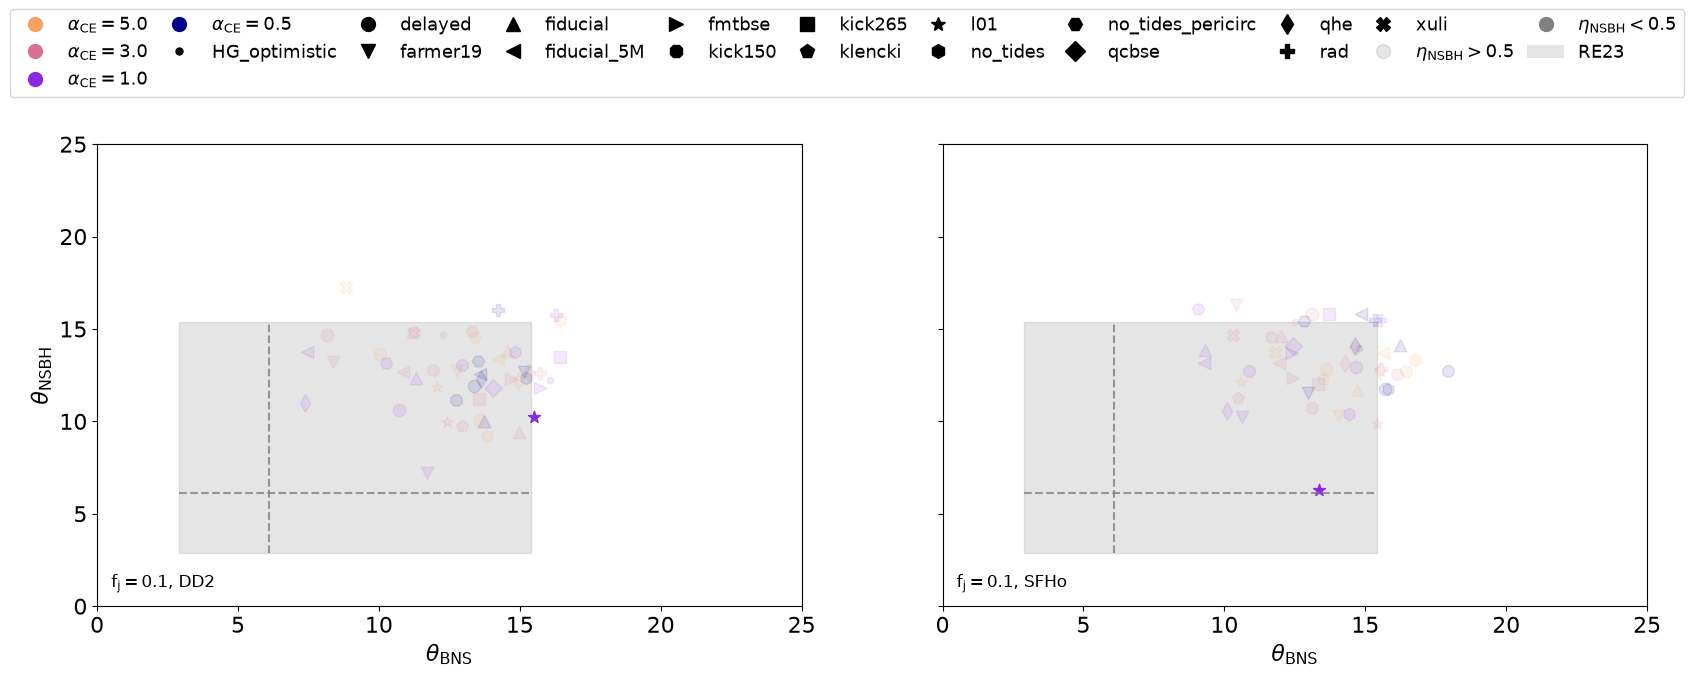

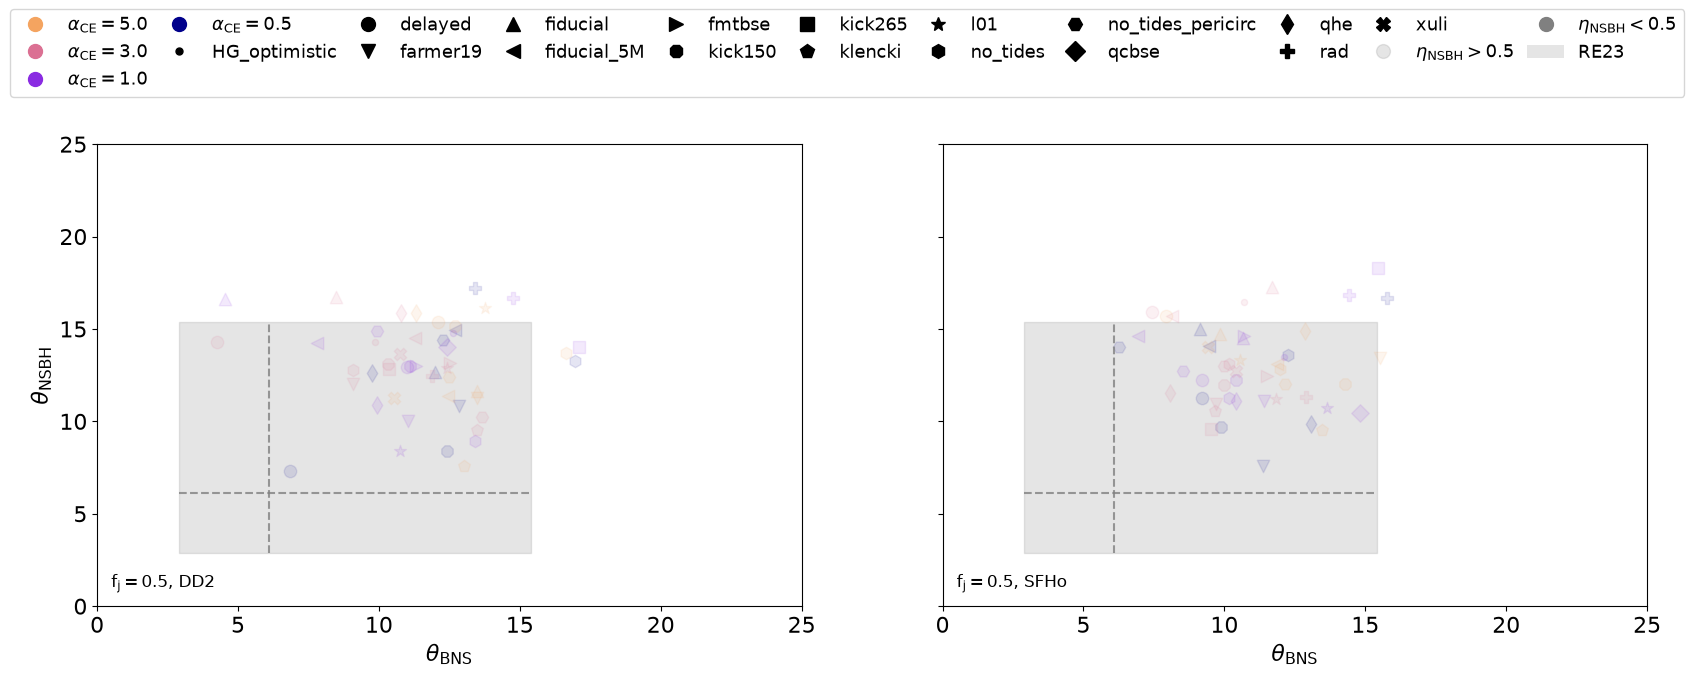

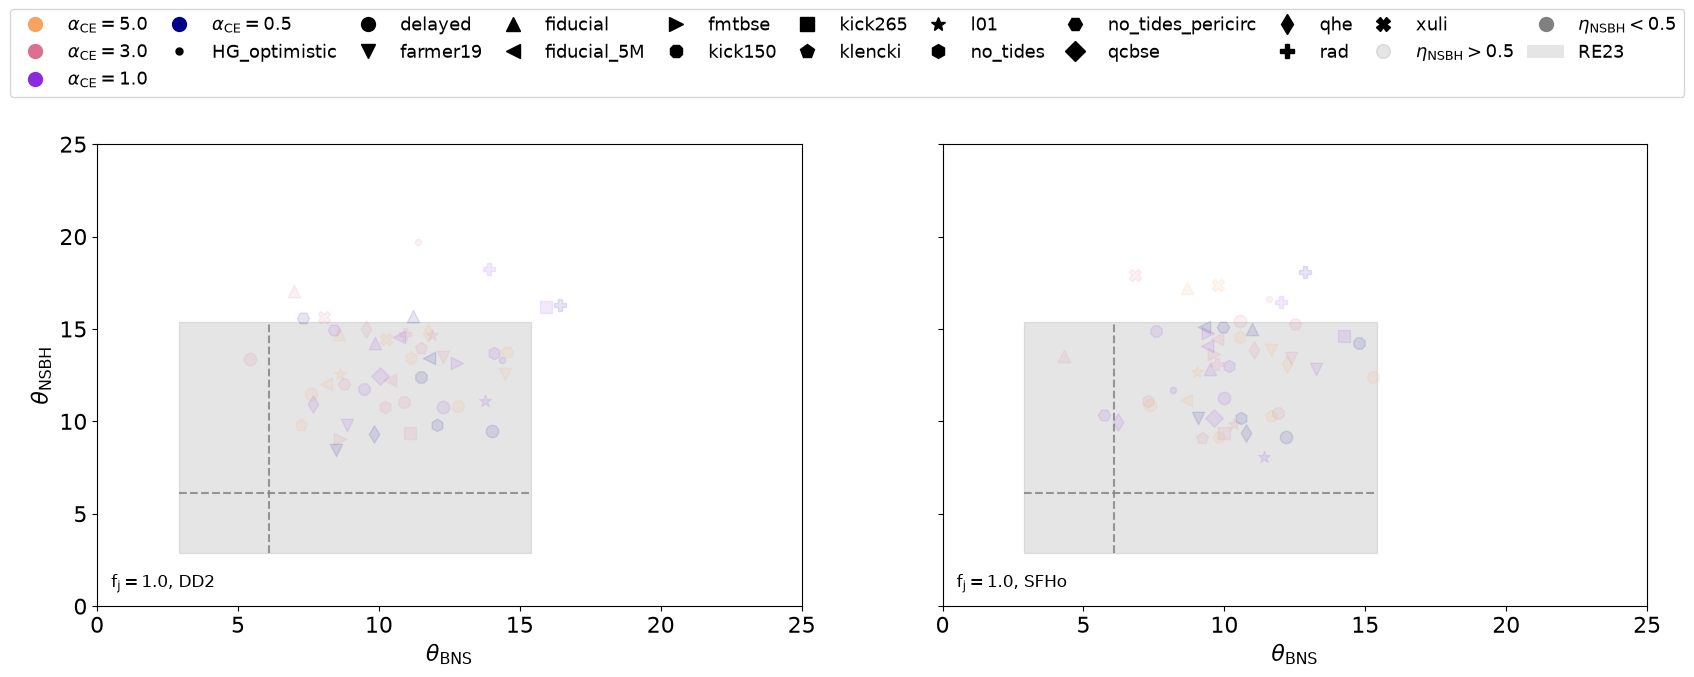

In [62]:
from matplotlib.patches import Rectangle

RE23            = [6.1 - 3.2, 6.1 + 9.3]
RE23_MEDIAN     = 6.1

GWTC_ONLY_tt   = False   # False = include all models regardless of GWTC compatibility
MODEL_GROUP_tt = "okay"  # "all" | "problematic" | "okay"

transparency_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="gray",
        markeredgecolor="gray",
        markersize=10,
        alpha=0.2,
        label=r"$\eta_{\rm NSBH} > 0.5$",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="gray",
        markeredgecolor="gray",
        markersize=10,
        alpha=1.0,
        label=r"$\eta_{\rm NSBH} < 0.5$",
    )
]

for fj_bsn in FJ_LIST:
    fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
    for pop, alpha, nsbh_series in product(selected_populations, POSSIBLE_ALPHAS, NSBH_AFFIX):
        alpha_key = str(alpha).replace("_", ".").replace("A", "")
        point_color = ALPHA_COLORS[alpha_key]
        point_marker = MODEL_MARKERS[pop]

        key = (pop, alpha, fj_bsn, nsbh_series)

        theta_bns = angle_vals[key]["theta_bns"]
        theta_nsbh = angle_vals[key]["theta_nsbh"]

        eta_nsbh_50 = eta_dict[key]["eta_nsbh"][0]
        point_alpha = (1.0 if eta_nsbh_50 > ETA_THRESHOLD else 0.1)

        bns_local_rate  = eta_dict[key]["bns_local_rate"][1]
        nsbh_local_rate = eta_dict[key]["nsbh_local_rate"][1]
        GW_BNS_cond     = GWTC_5[0] <= bns_local_rate <= GWTC_5[1]
        GW_NSBH_cond    = GWTC_5_NSBH[0] <= nsbh_local_rate <= GWTC_5_NSBH[1]
        GW_cond         = GW_BNS_cond and GW_NSBH_cond
        if GWTC_ONLY_tt and not GW_cond: opacity = 0.2 
        else: opacity = 1.0

        if MODEL_GROUP_tt == "problematic" and not model_is_problematic(pop, alpha): continue
        if MODEL_GROUP_tt == "okay" and model_is_problematic(pop, alpha): continue
        if MODEL_GROUP_tt == "all": pass # not really necessary, but for clarity

        k = 0 if nsbh_series == "NSBH_DD2_uniform_chi_0_1" else 1
        axes[k].scatter(
            theta_bns,
            theta_nsbh,
            marker=point_marker,
            color=point_color,
            alpha=point_alpha,
            s=80,
        )

    for ax, series_label in zip(axes, ["DD2", "SFHo"]):
        ax.fill_between(
            RE23,
            [RE23[0], RE23[0]],
            [RE23[1], RE23[1]],
            color="gray",
            alpha=0.2,
            zorder=0,
        )

        ax.vlines(
            RE23_MEDIAN,
            RE23[0],
            RE23[1],
            color="gray",
            linestyle="--",
            alpha=0.8,
        )
        ax.hlines(
            RE23_MEDIAN,
            RE23[0],
            RE23[1],
            color="gray",
            linestyle="--",
            alpha=0.8,
        )

        ax.set_xlim(0, 25)
        ax.set_ylim(0, 25)
        ax.set_xlabel(r"$\theta_{\rm BNS}$")
        ax.text(
            0.02,
            0.03,
            rf"$\rm f_j = {fj_bsn}$, {series_label}",
            transform=ax.transAxes,
            fontsize=FONTSIZE - 4,
            verticalalignment="bottom",
            horizontalalignment="left",
        )

    axes[0].set_ylabel(r"$\theta_{\rm NSBH}$")

    re23_handle = Rectangle(
        (0, 0),
        1,
        1,
        facecolor="gray",
        alpha=0.2,
        label="RE23",
    )

    fig.legend(
        handles=(
            alpha_handles
            + model_handles
            + transparency_handles
            + [re23_handle]
        ),
        loc="upper center",
        ncol=11,
        bbox_to_anchor=(0.5, 1.12),
        fontsize=FONTSIZE - 3,
        columnspacing=0.7,
    )

    save_figure(fig, f"theta_nsbh_vs_theta_bns", fj_bsn, gwtc_only=GWTC_ONLY_tt, model_group=MODEL_GROUP_tt)

# Make all plots

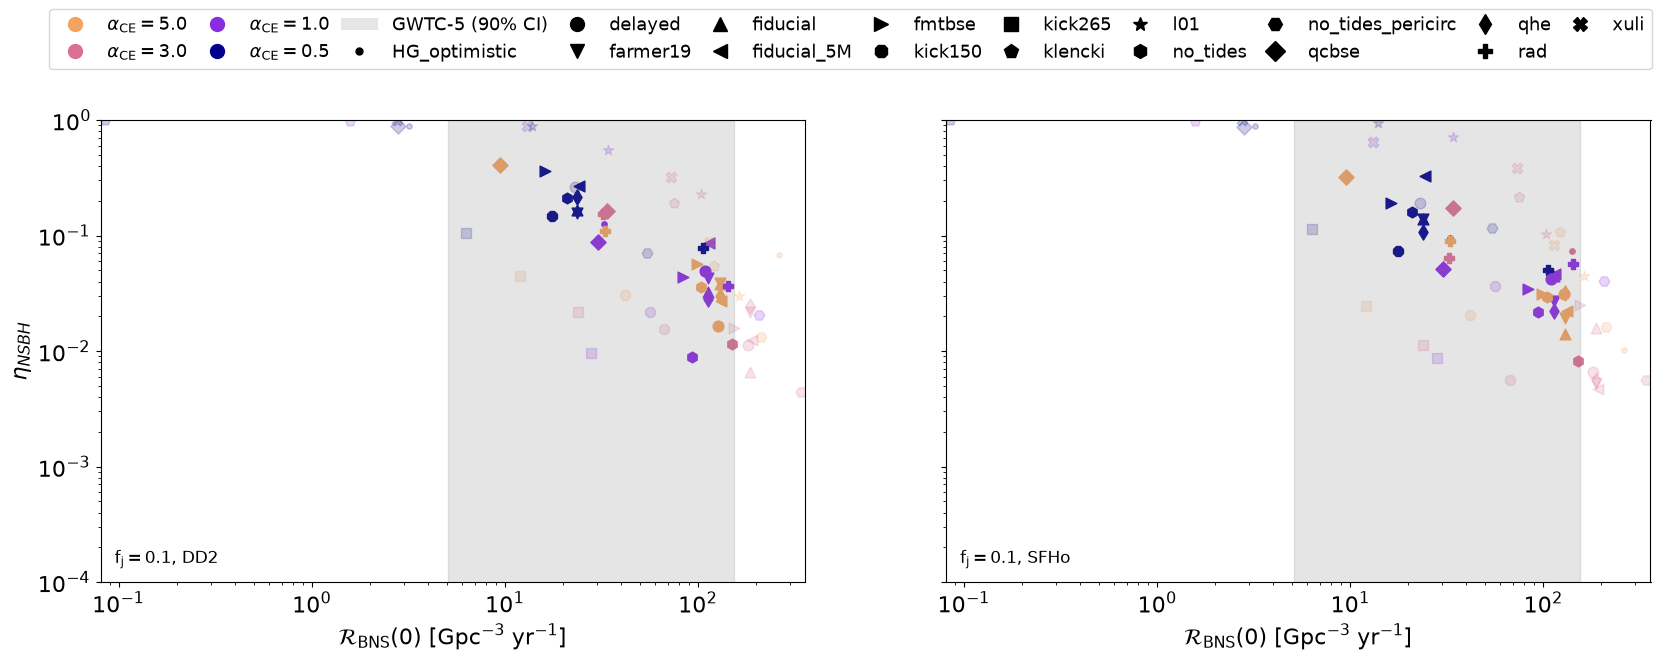

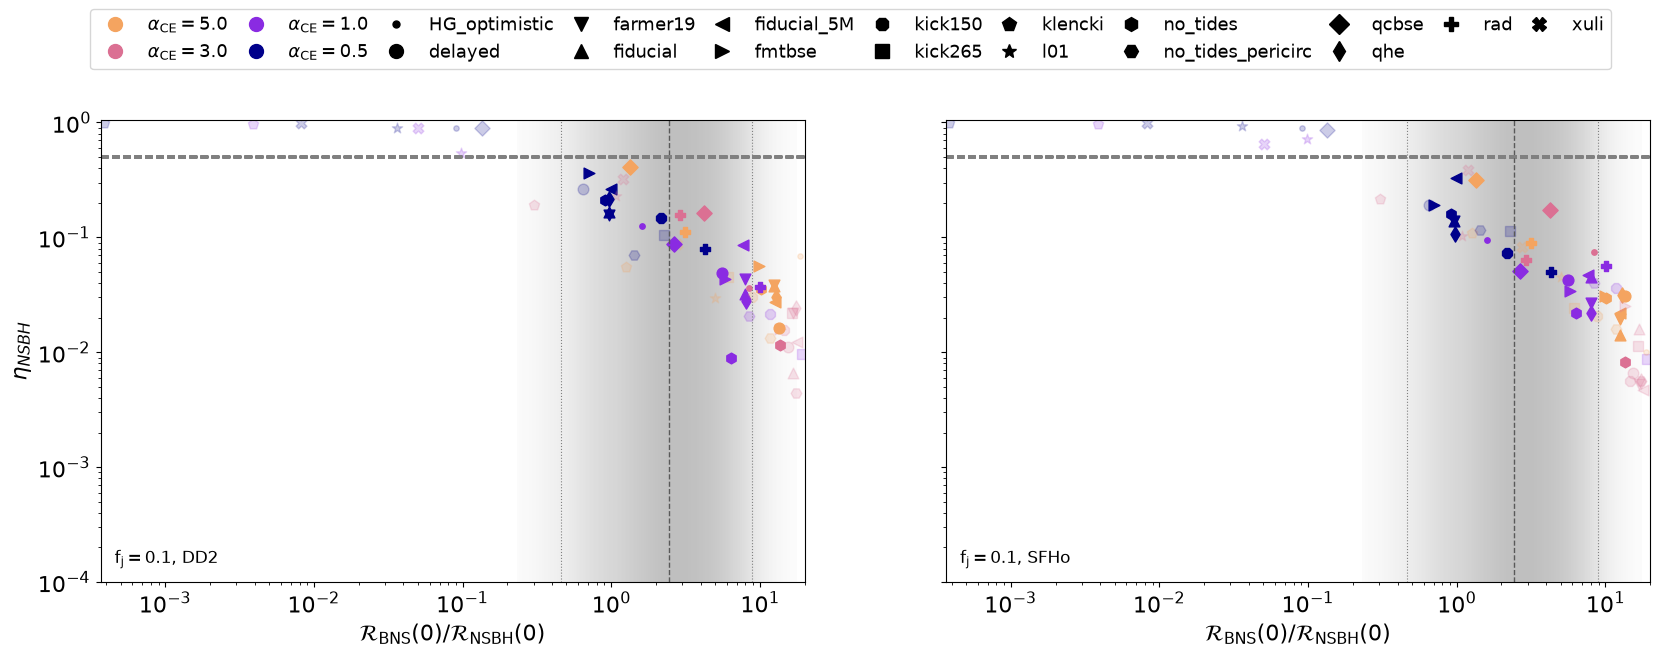

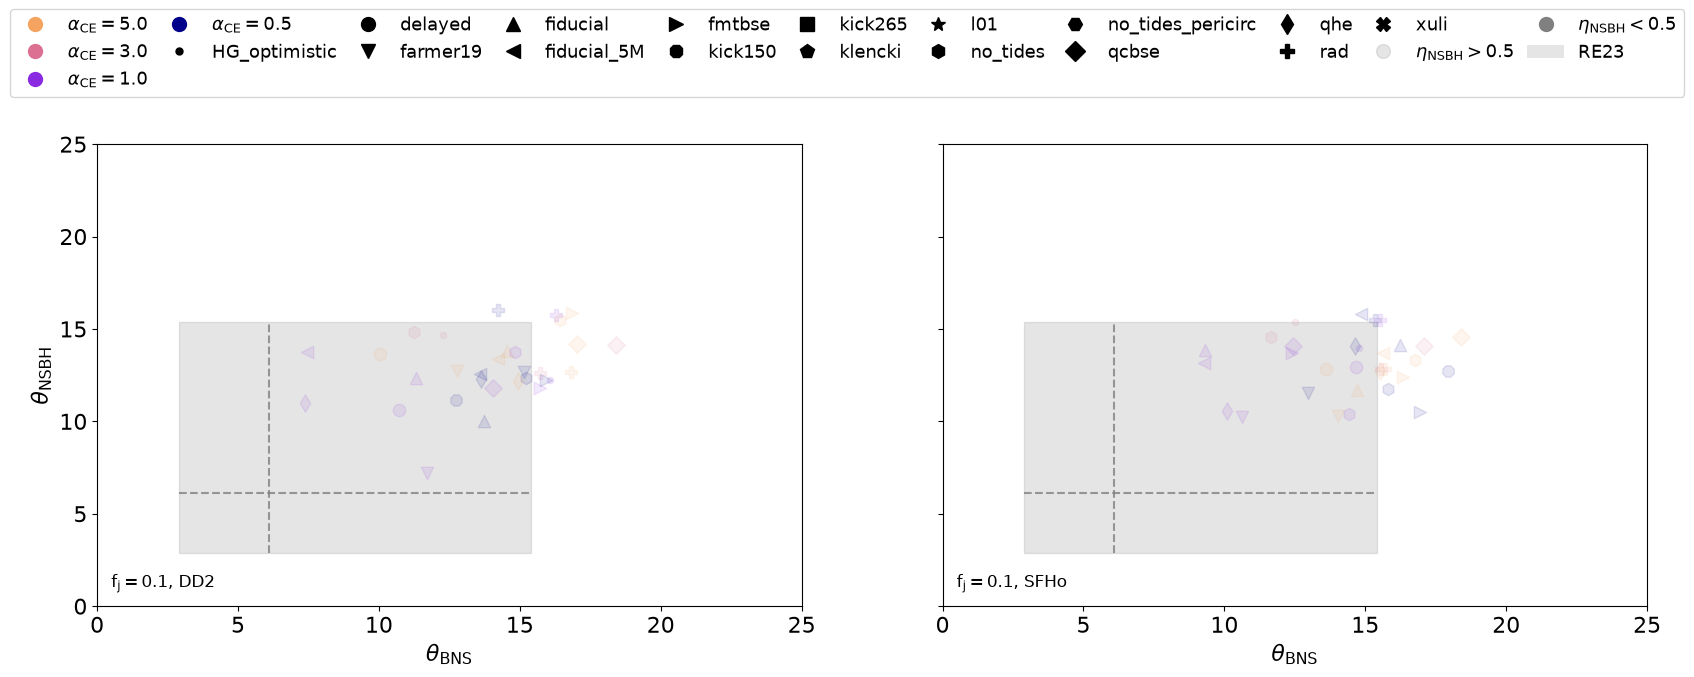

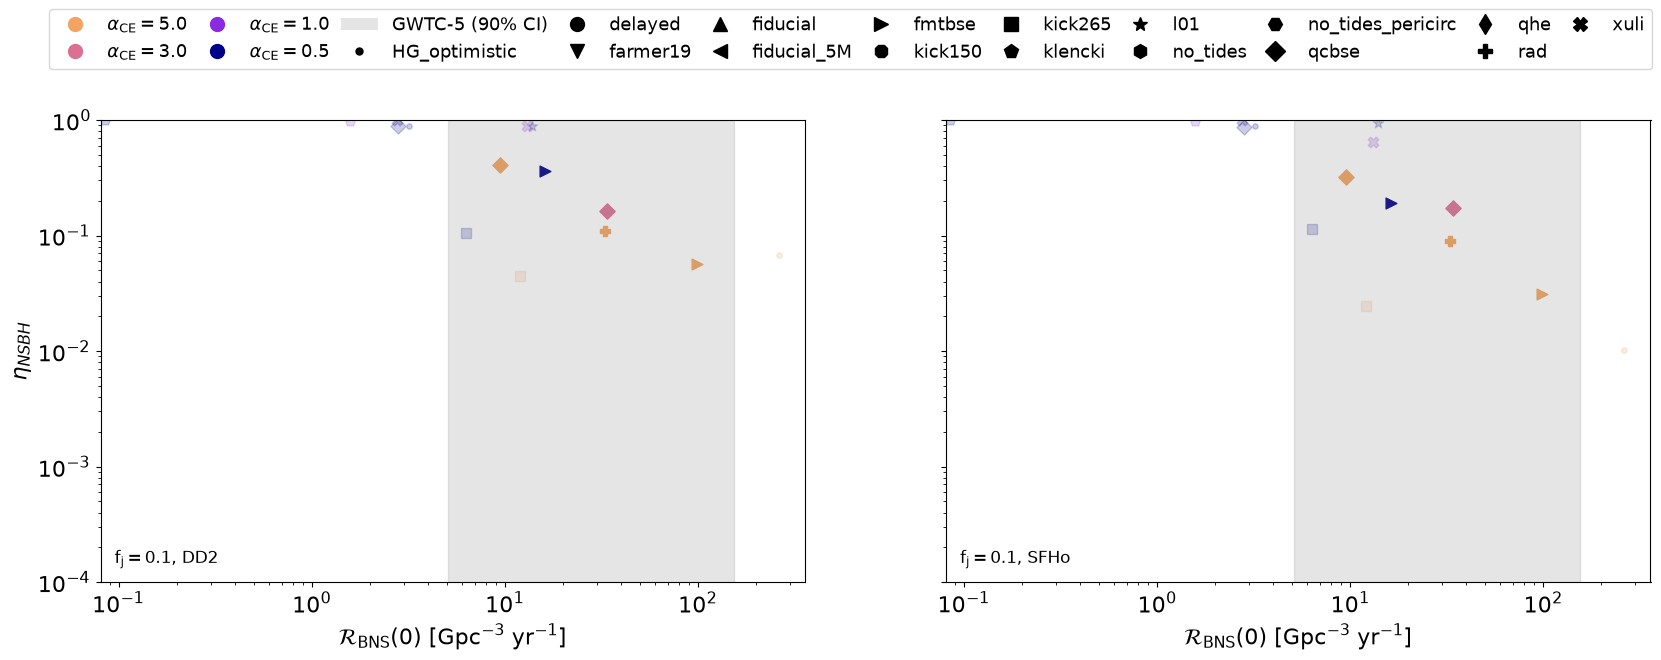

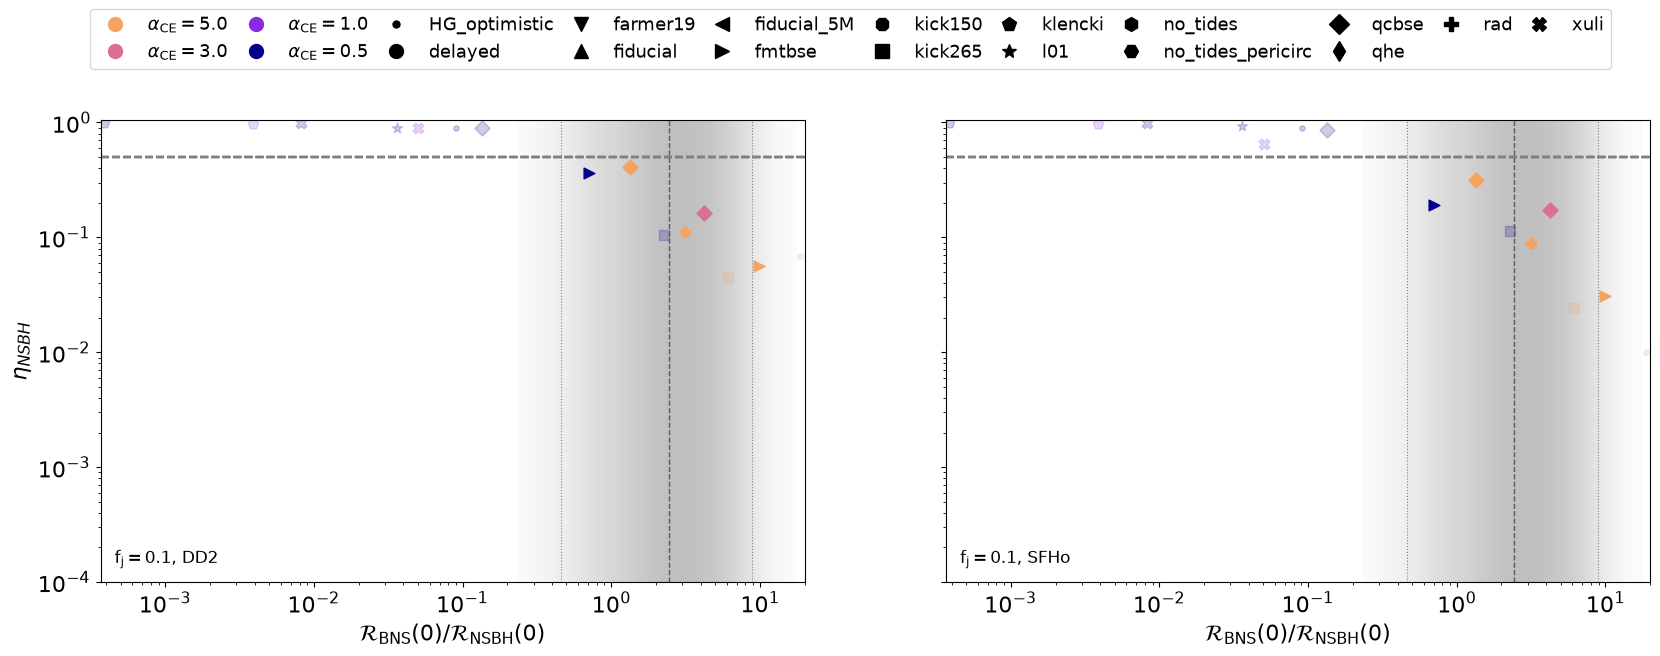

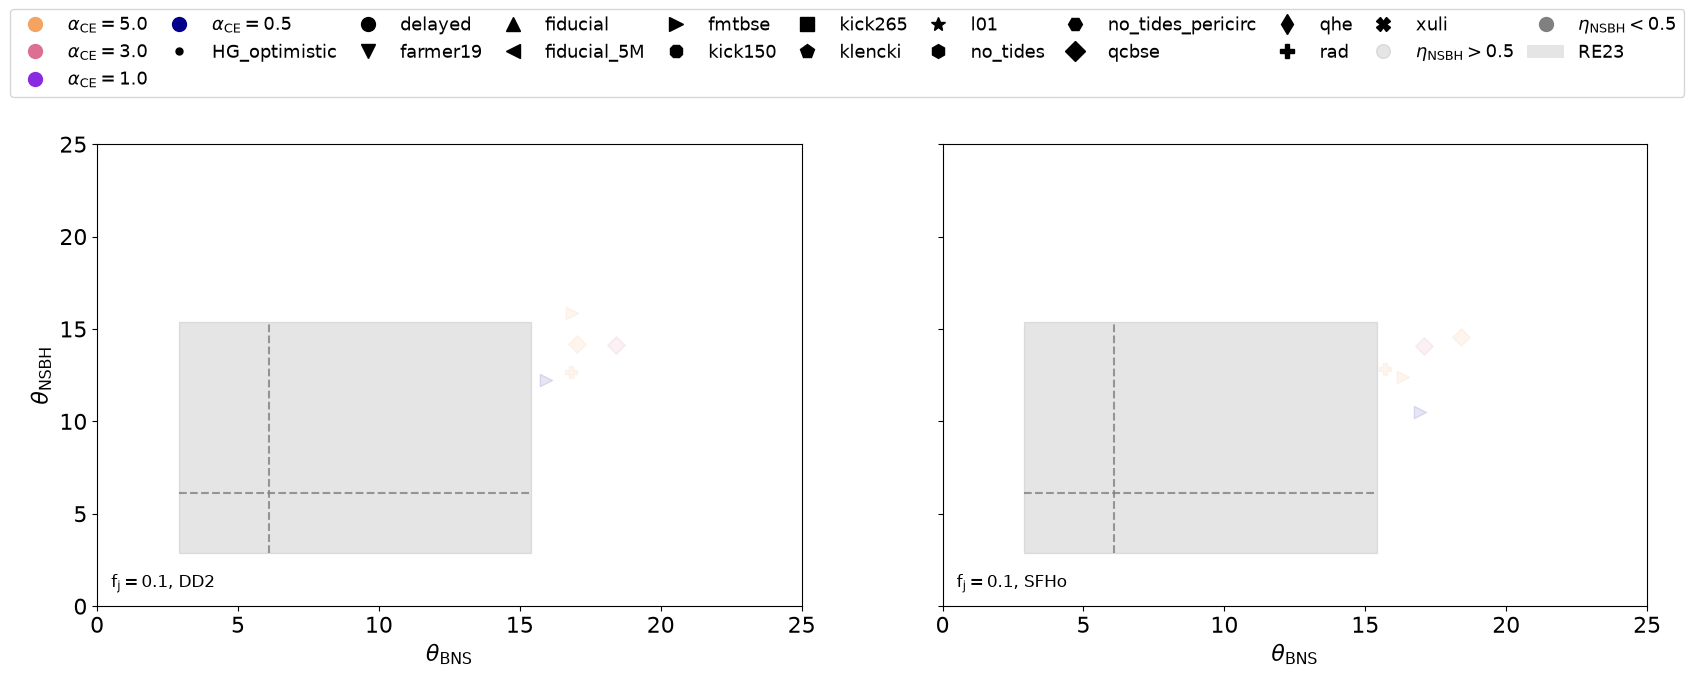

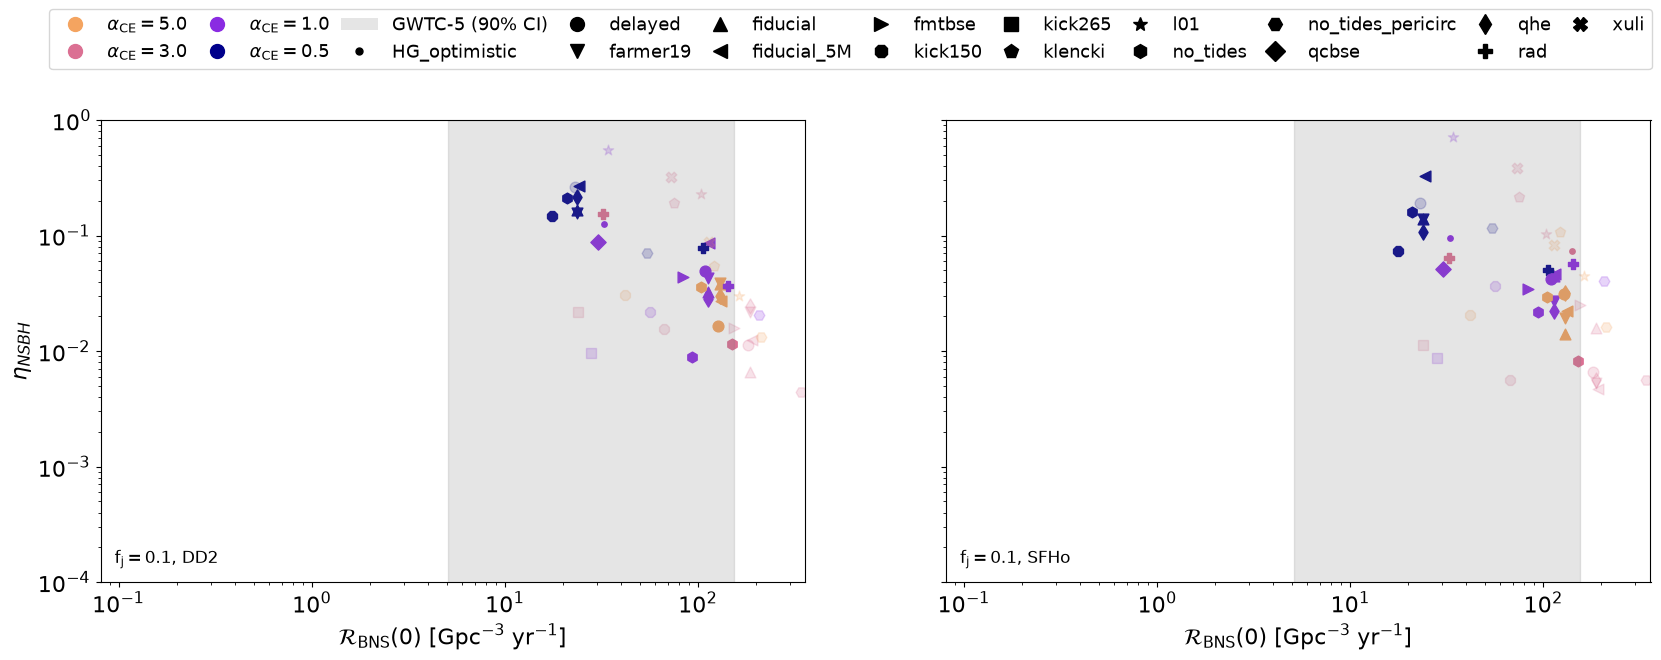

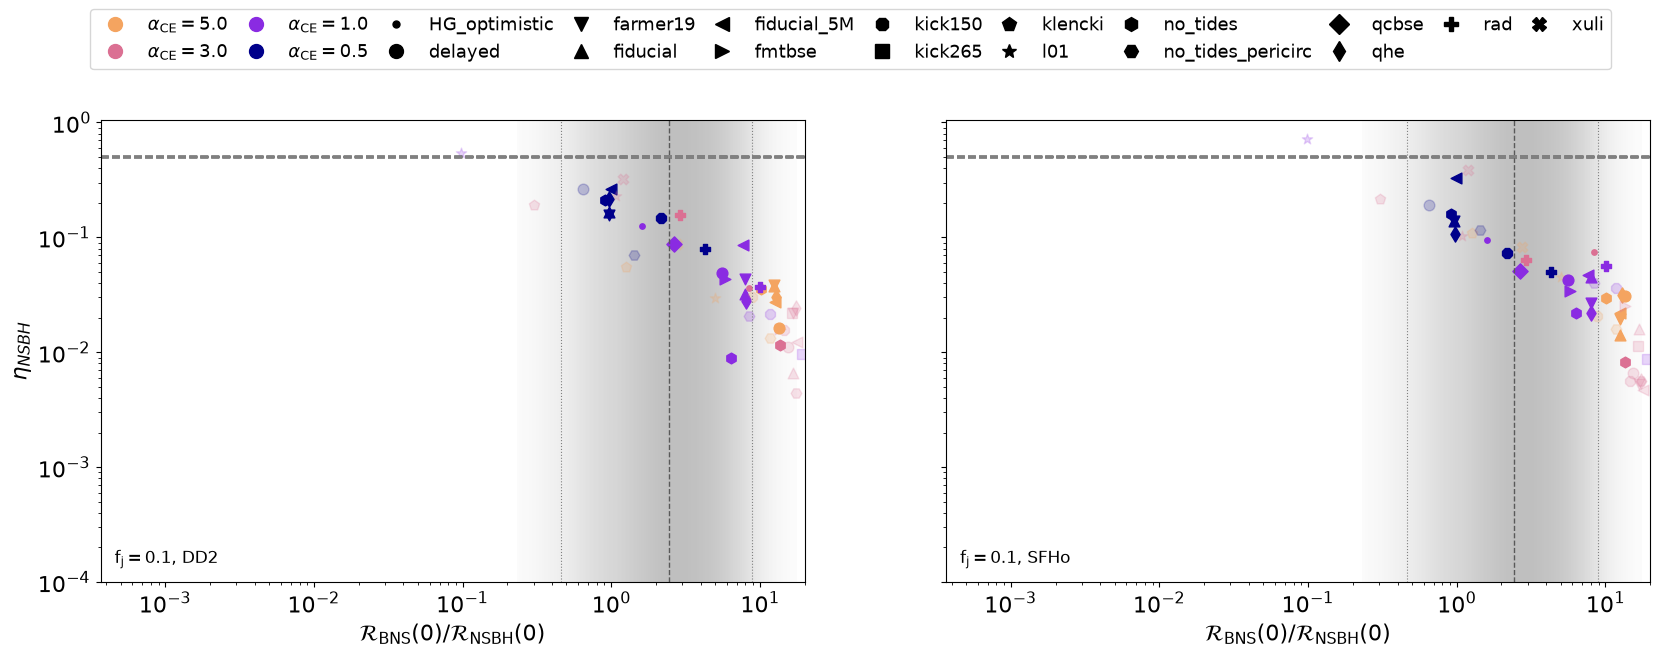

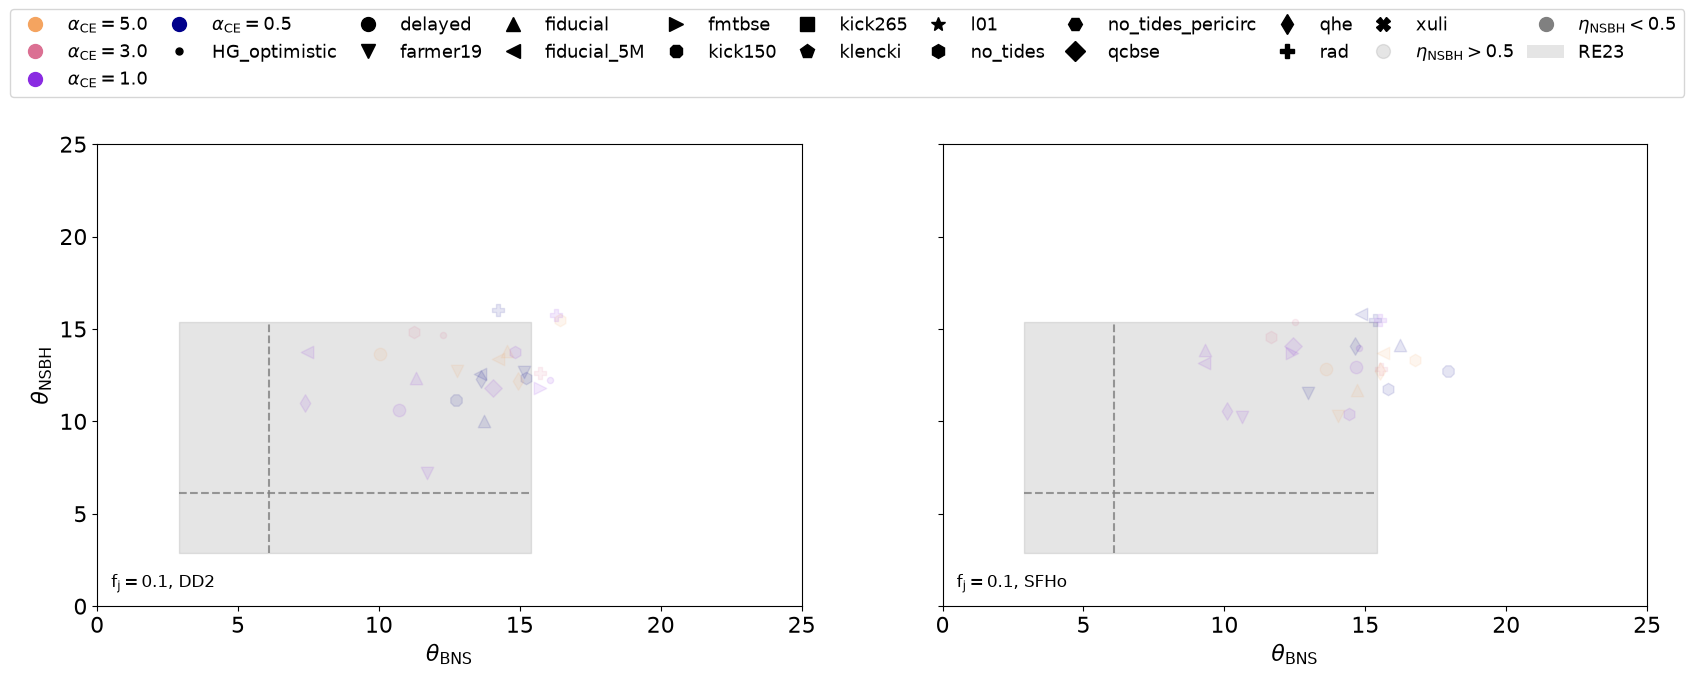

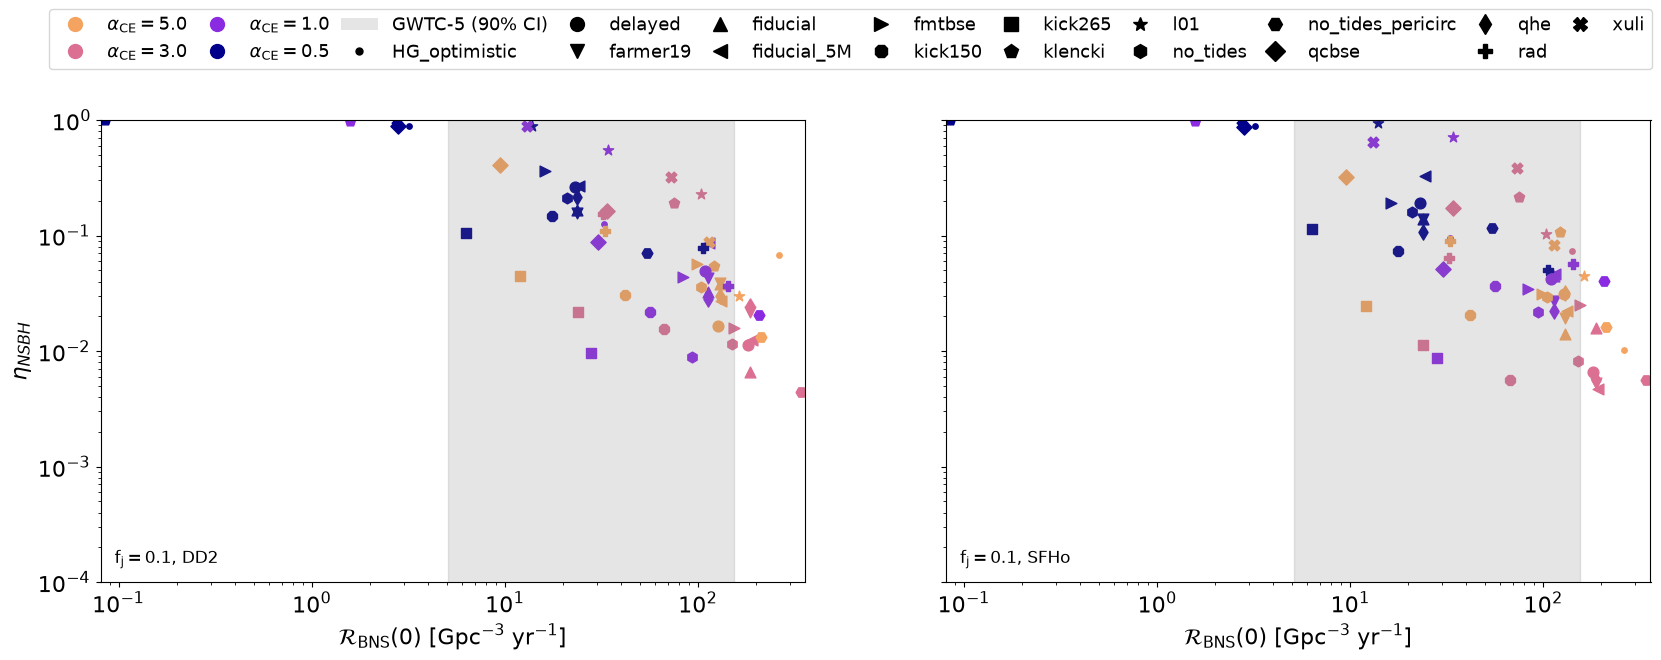

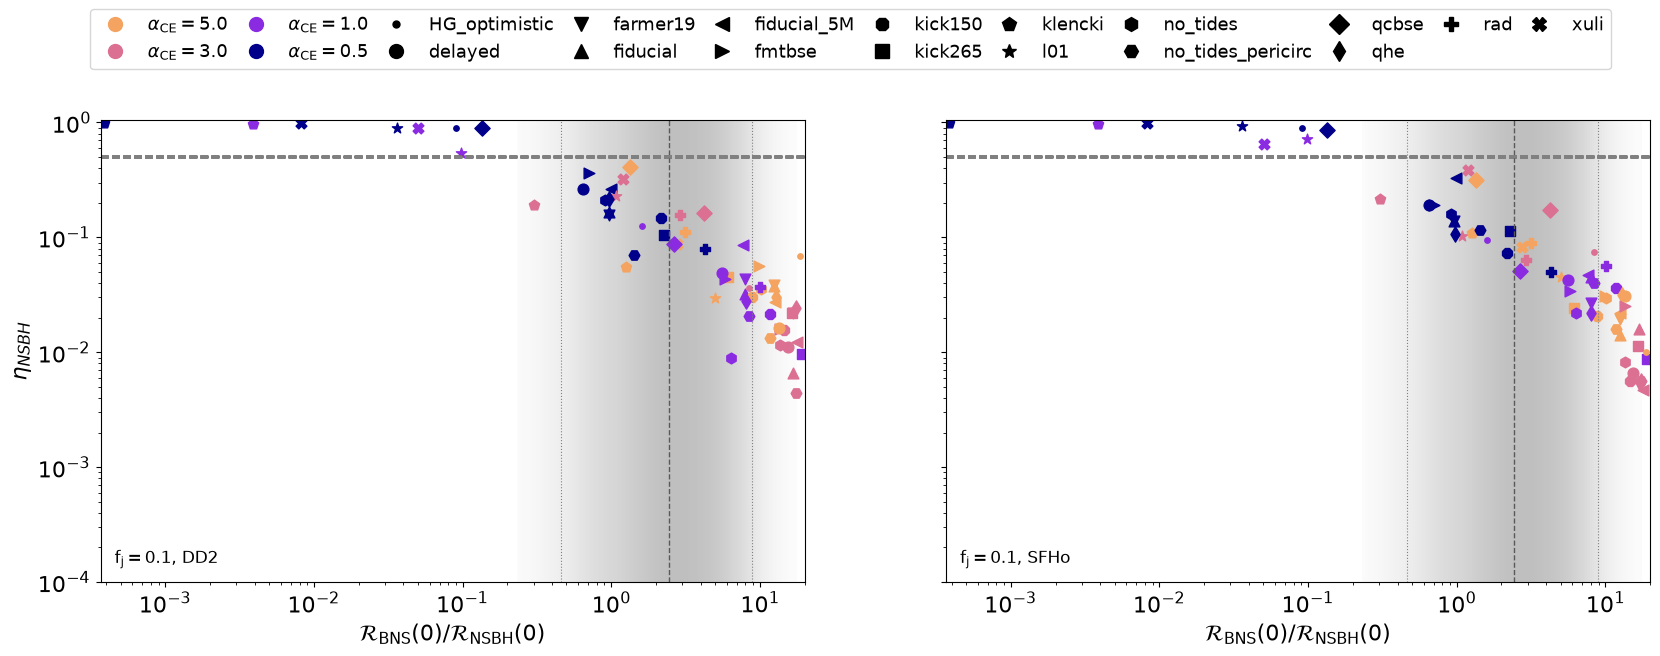

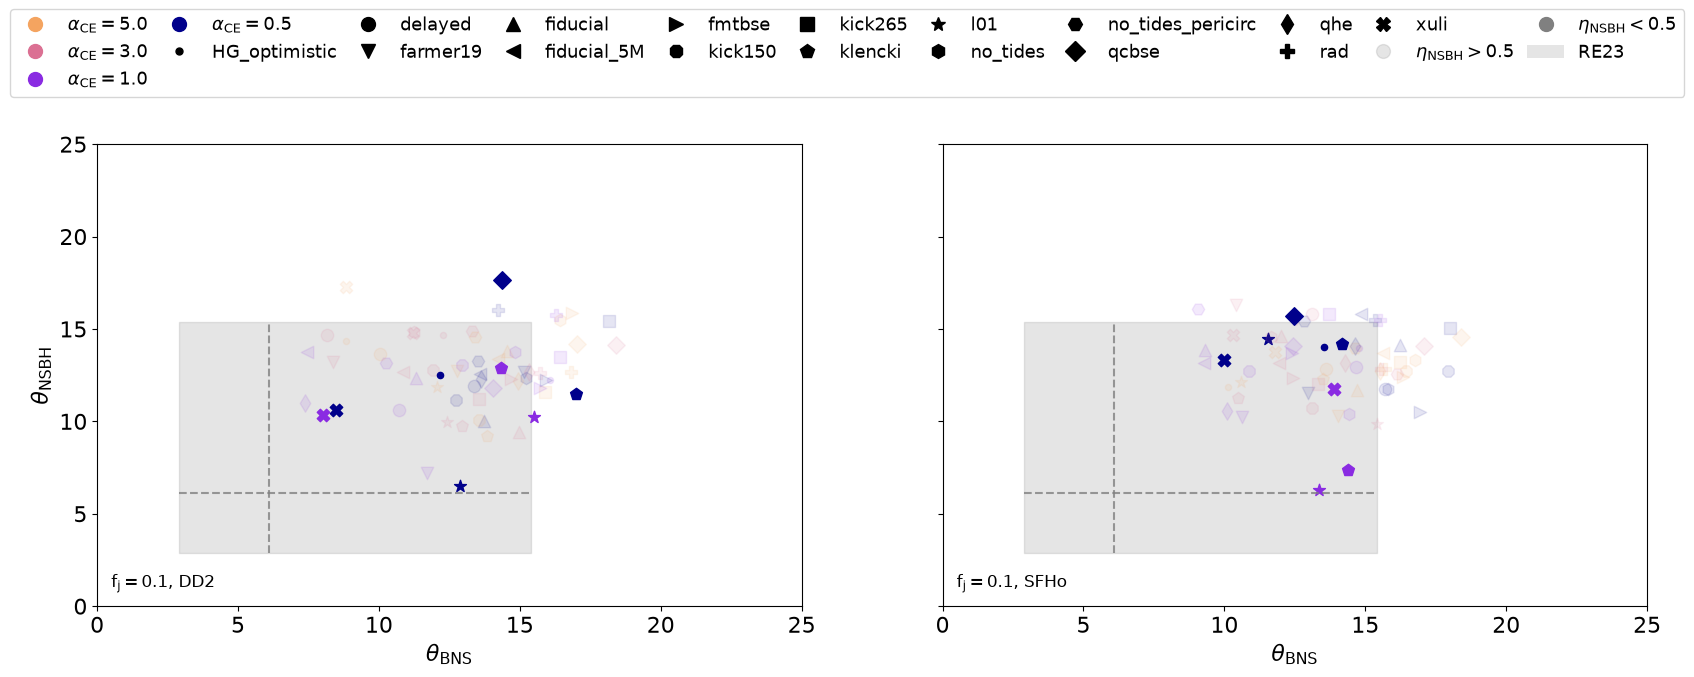

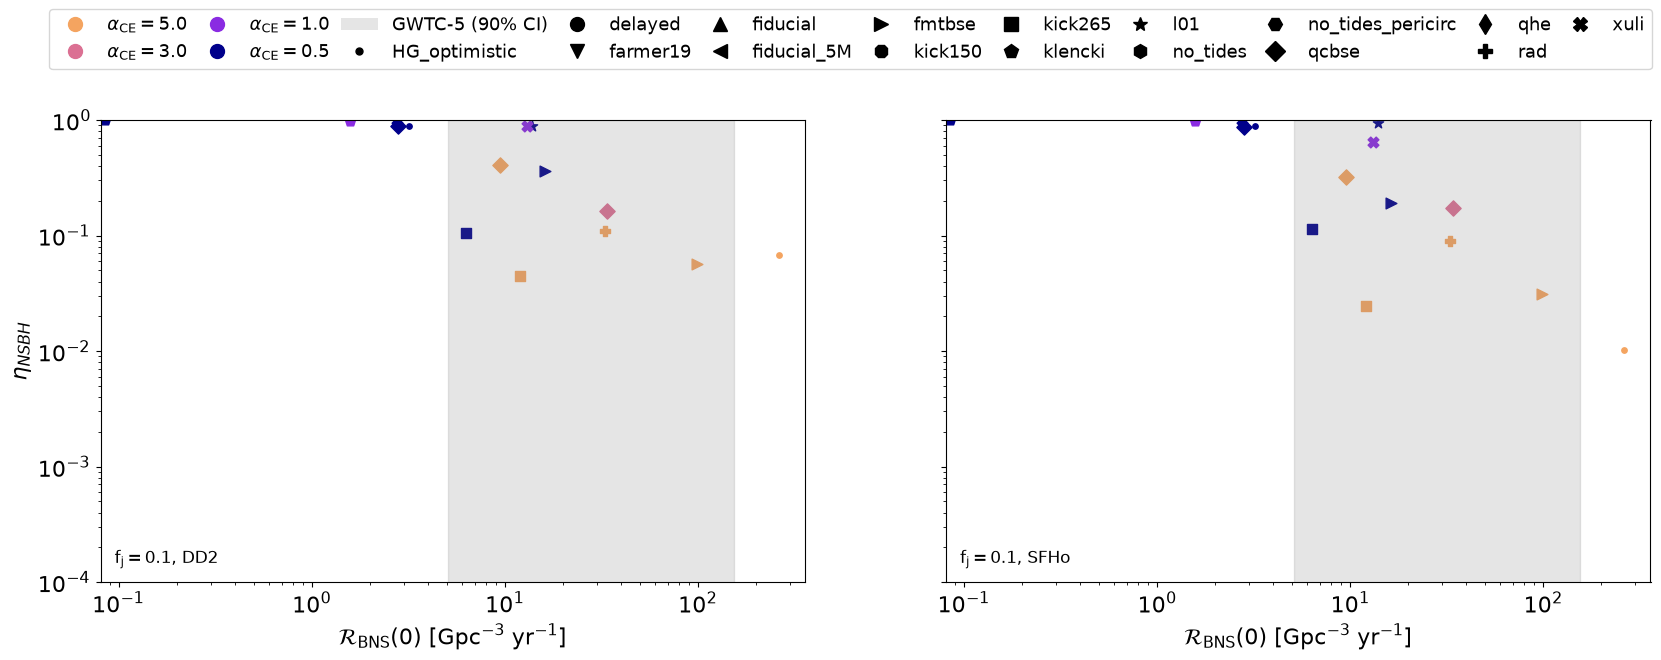

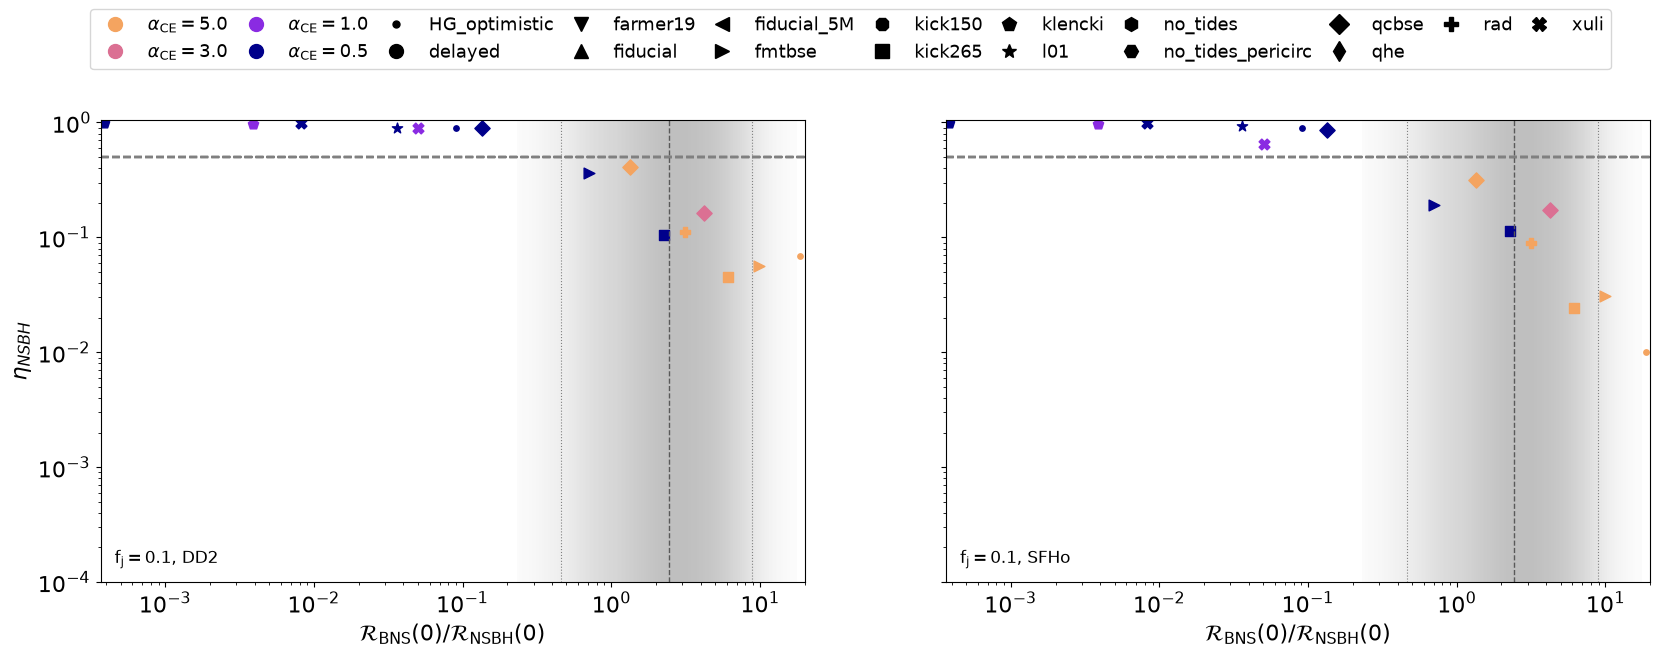

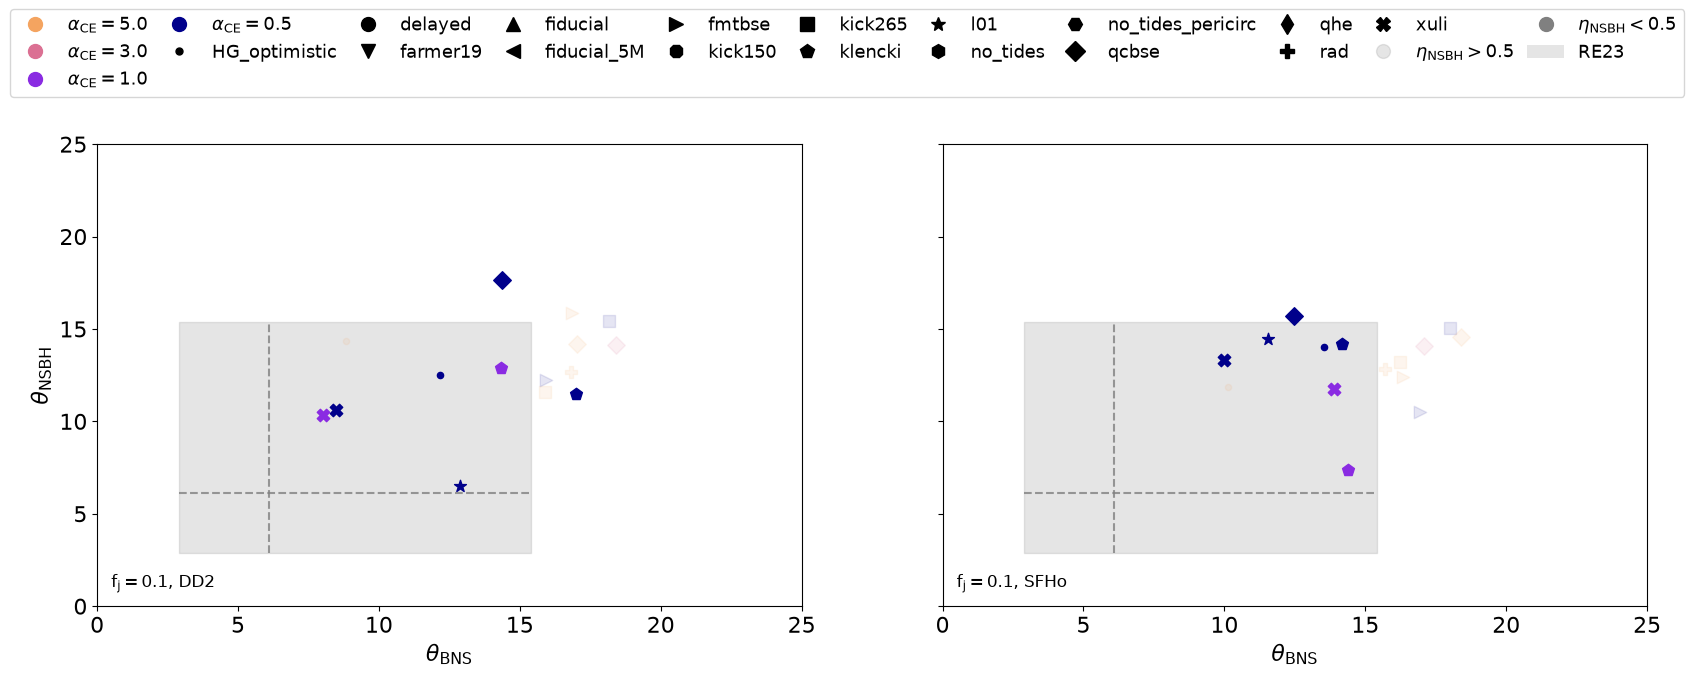

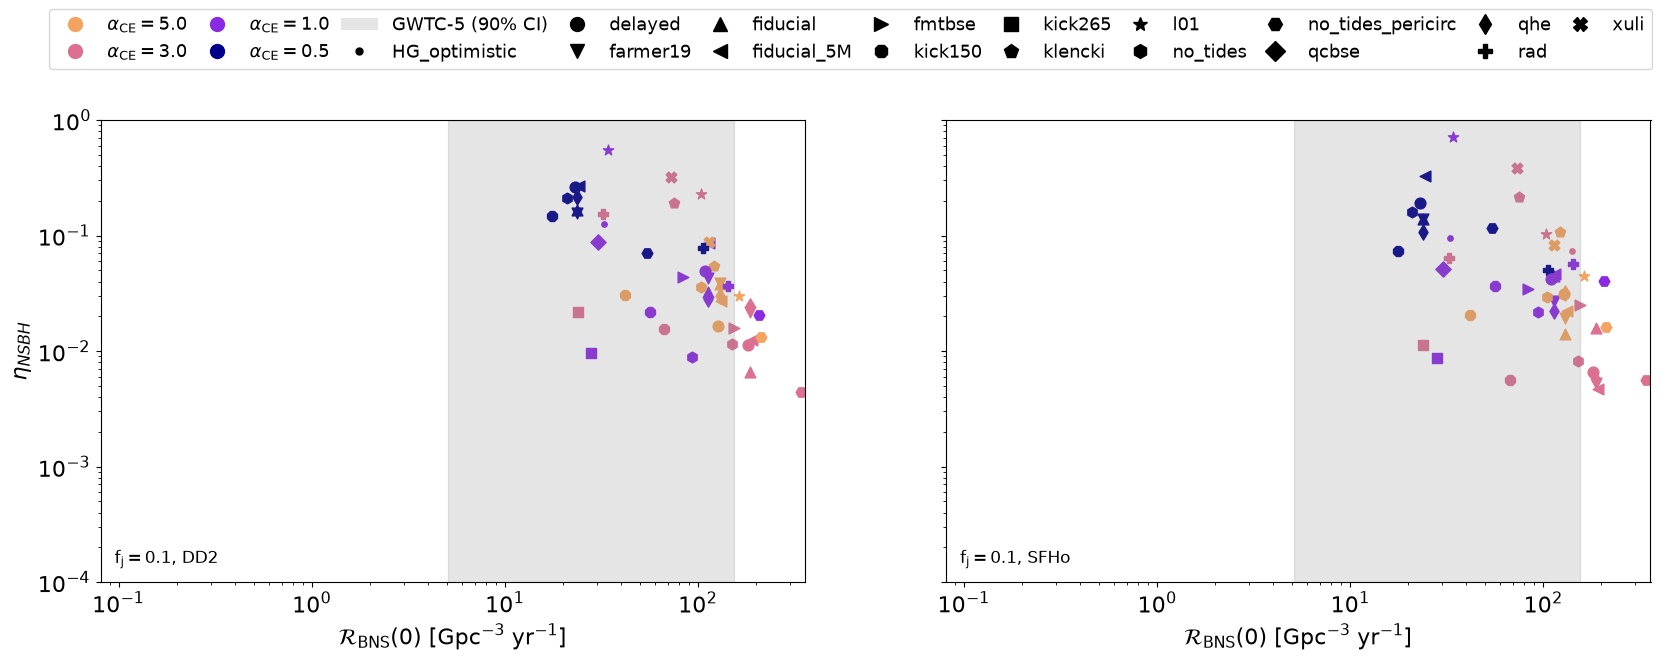

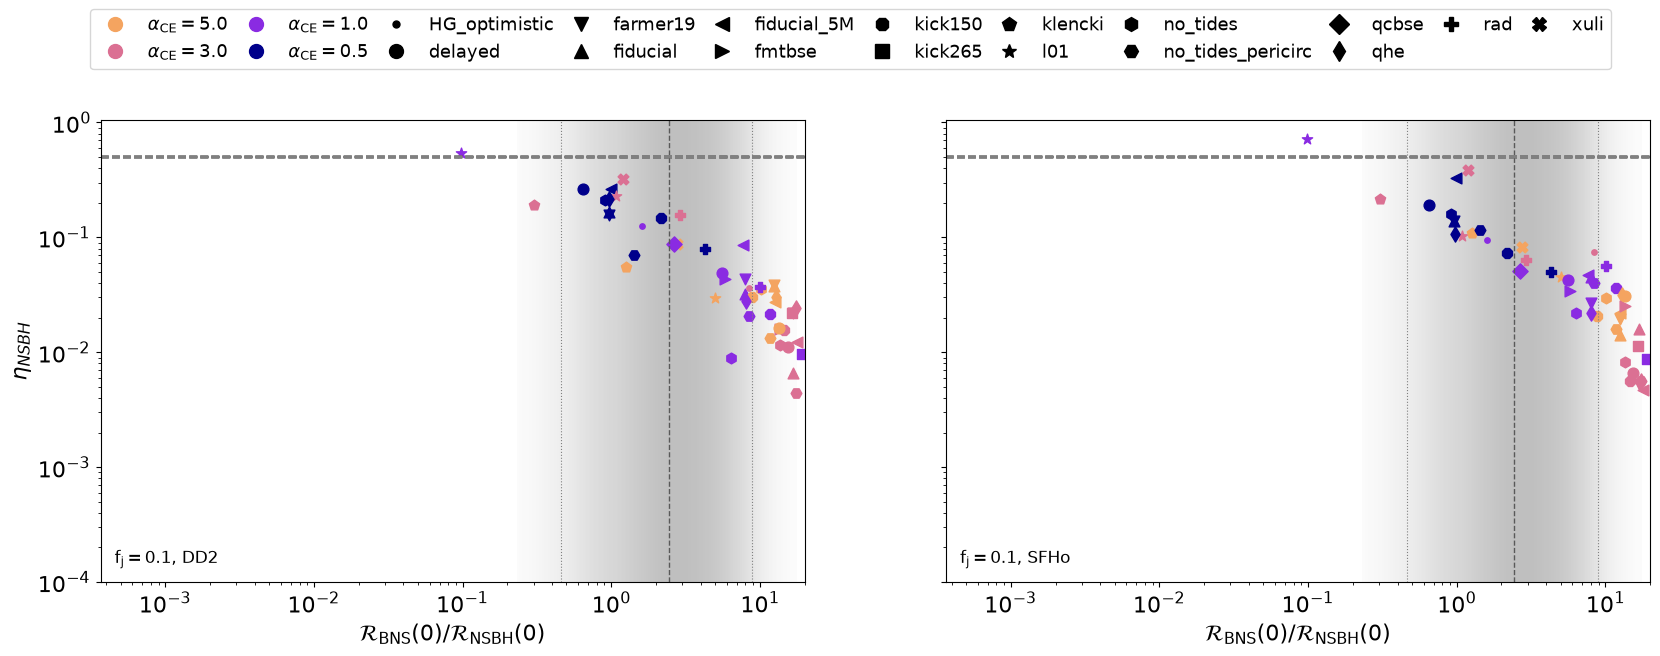

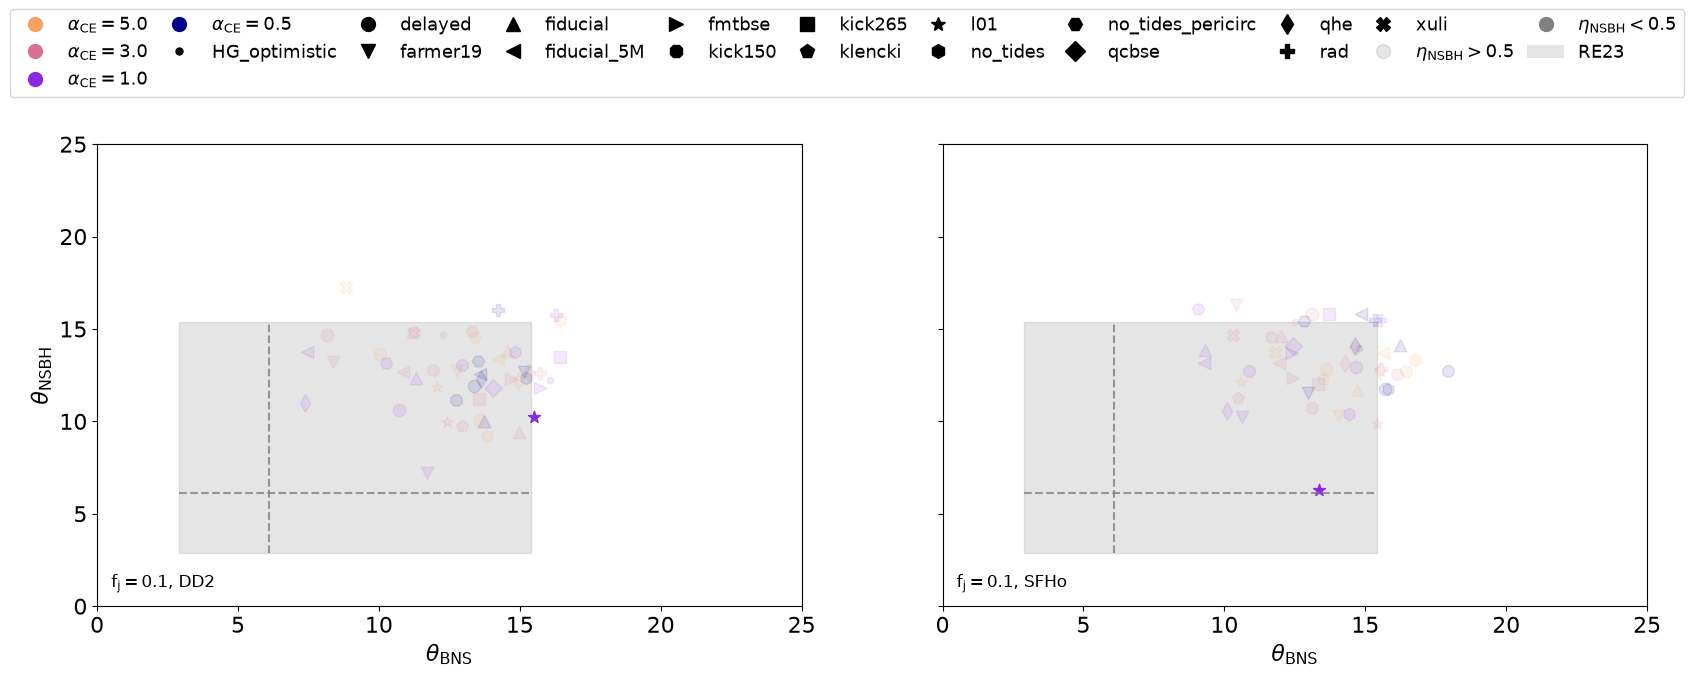

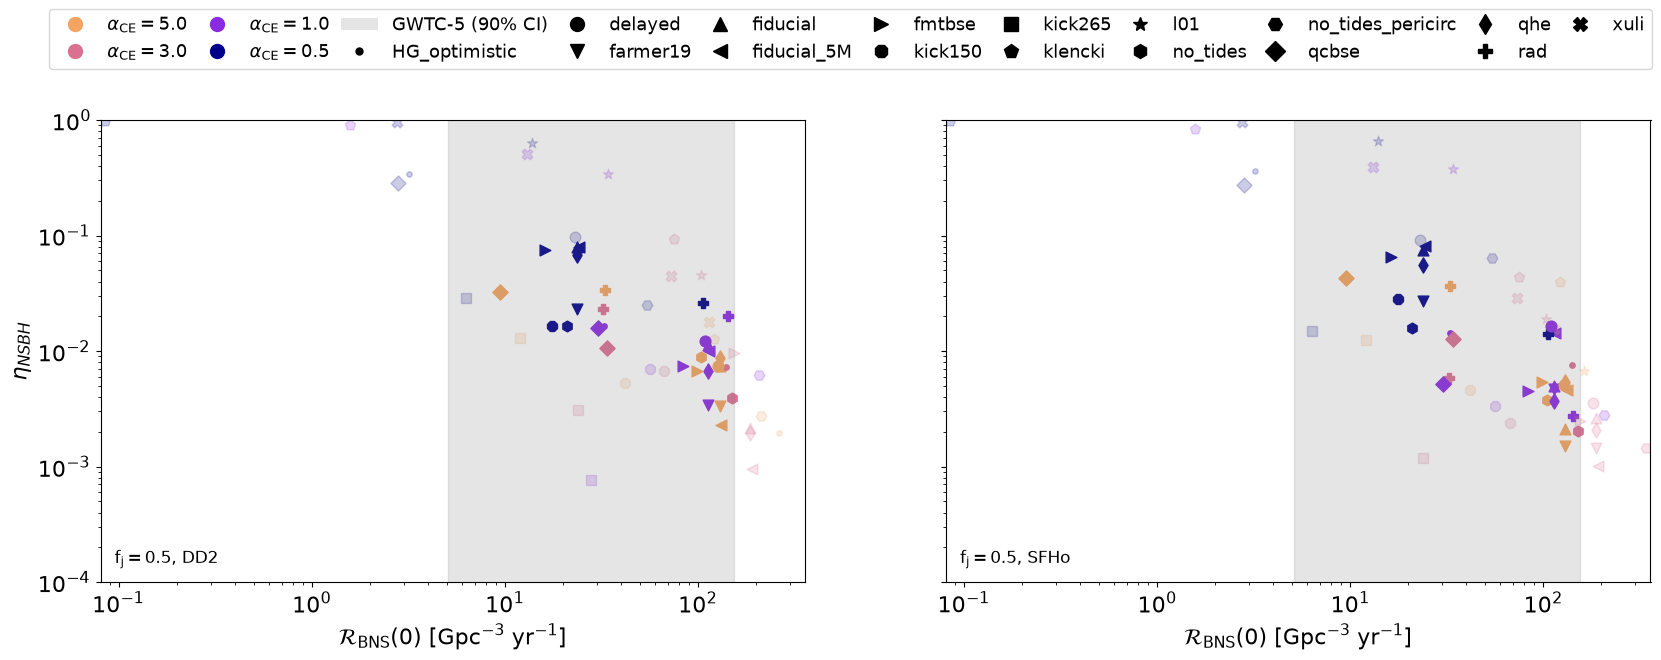

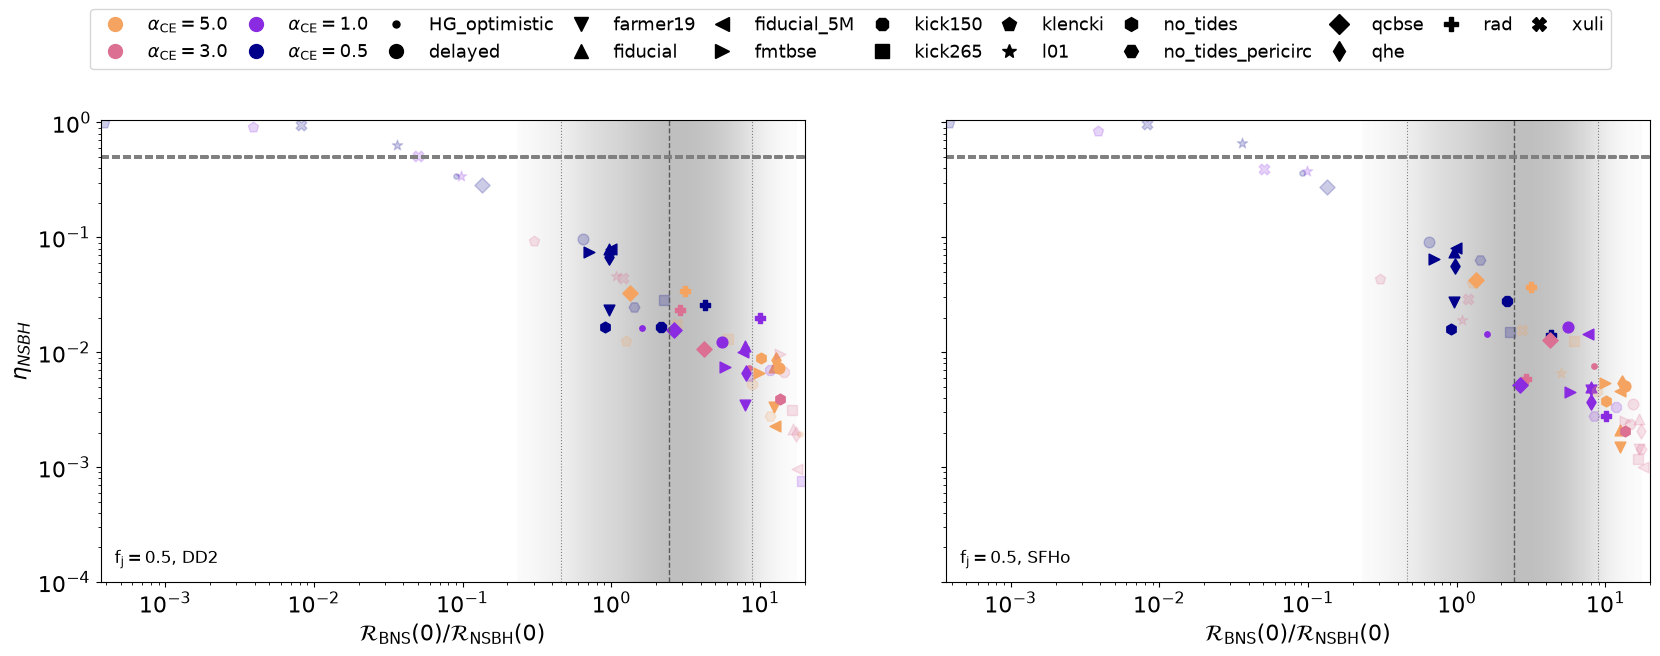

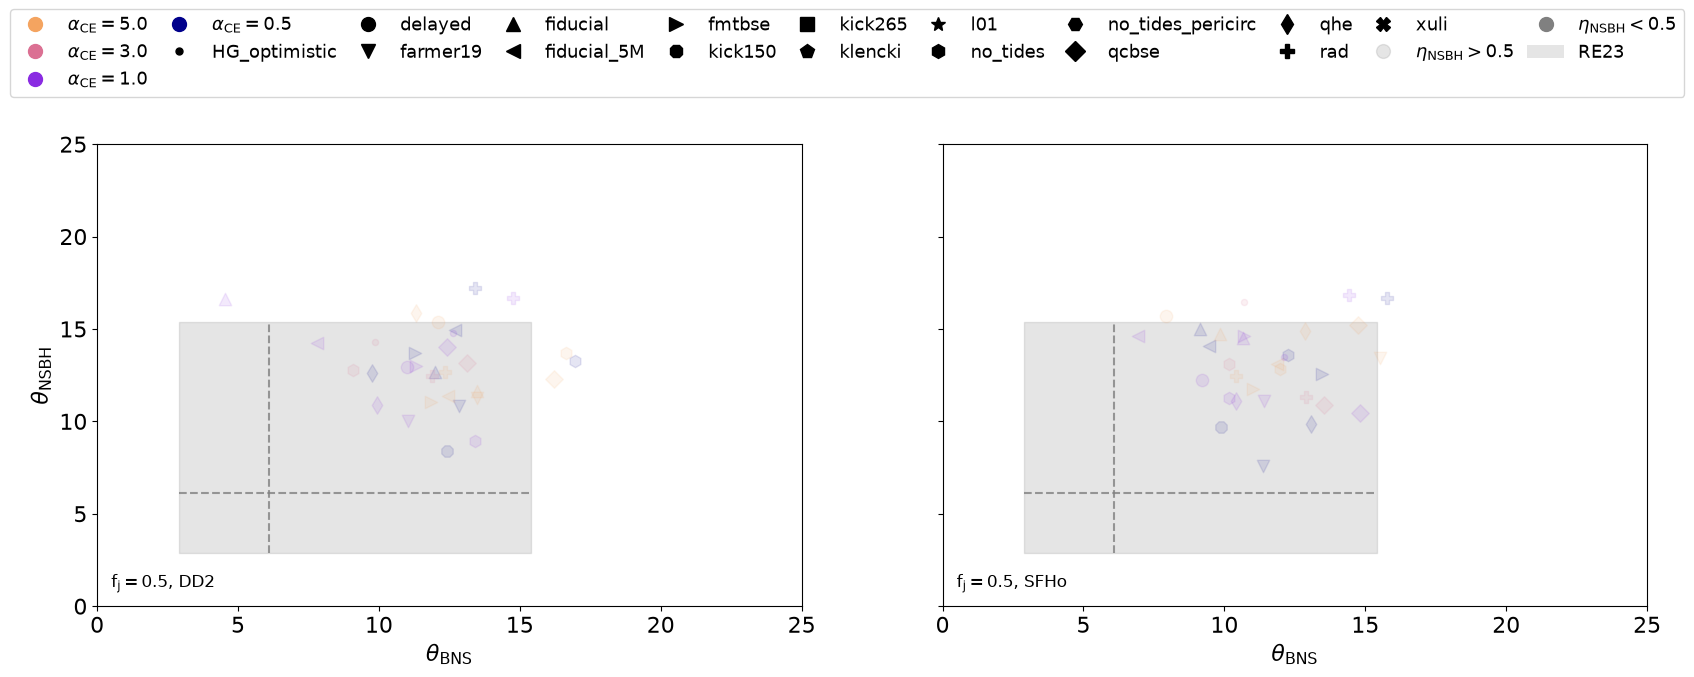

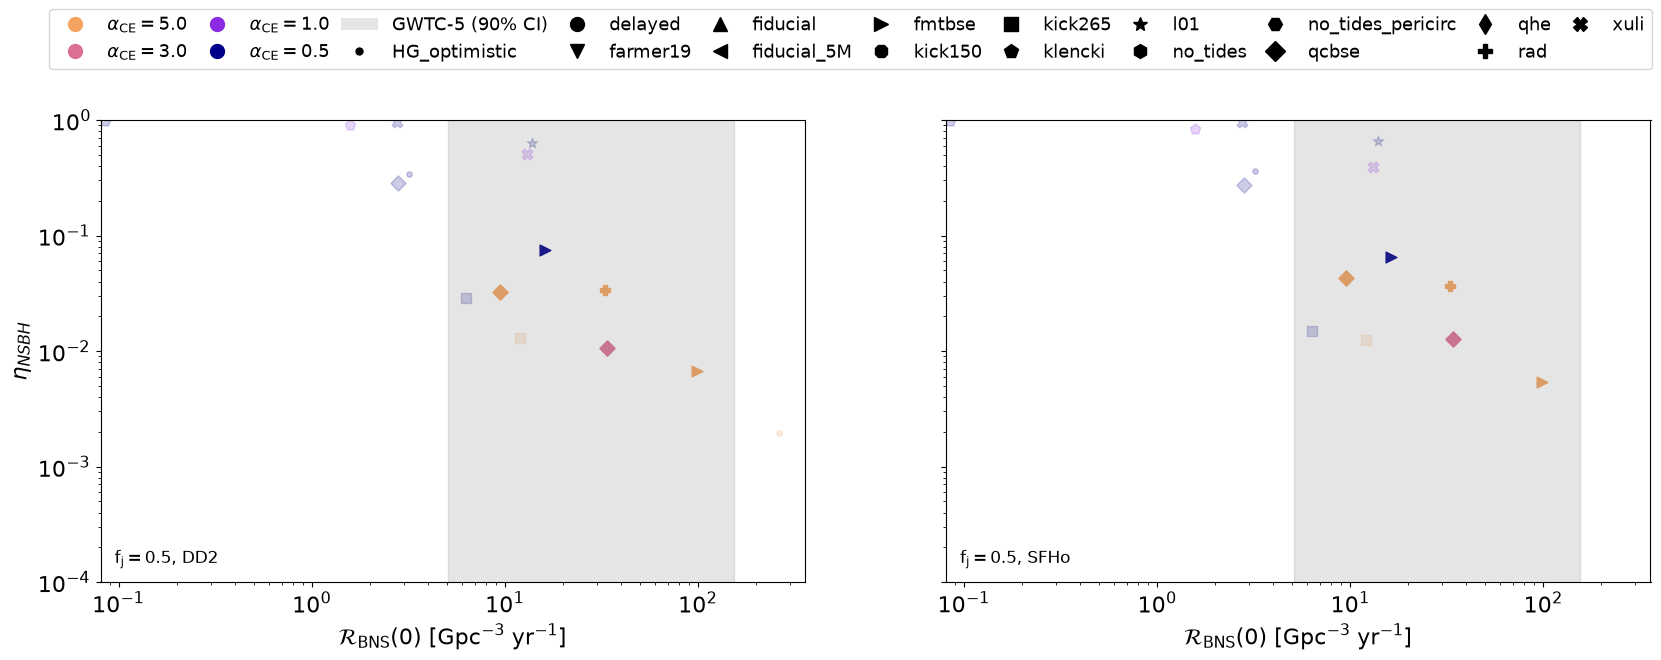

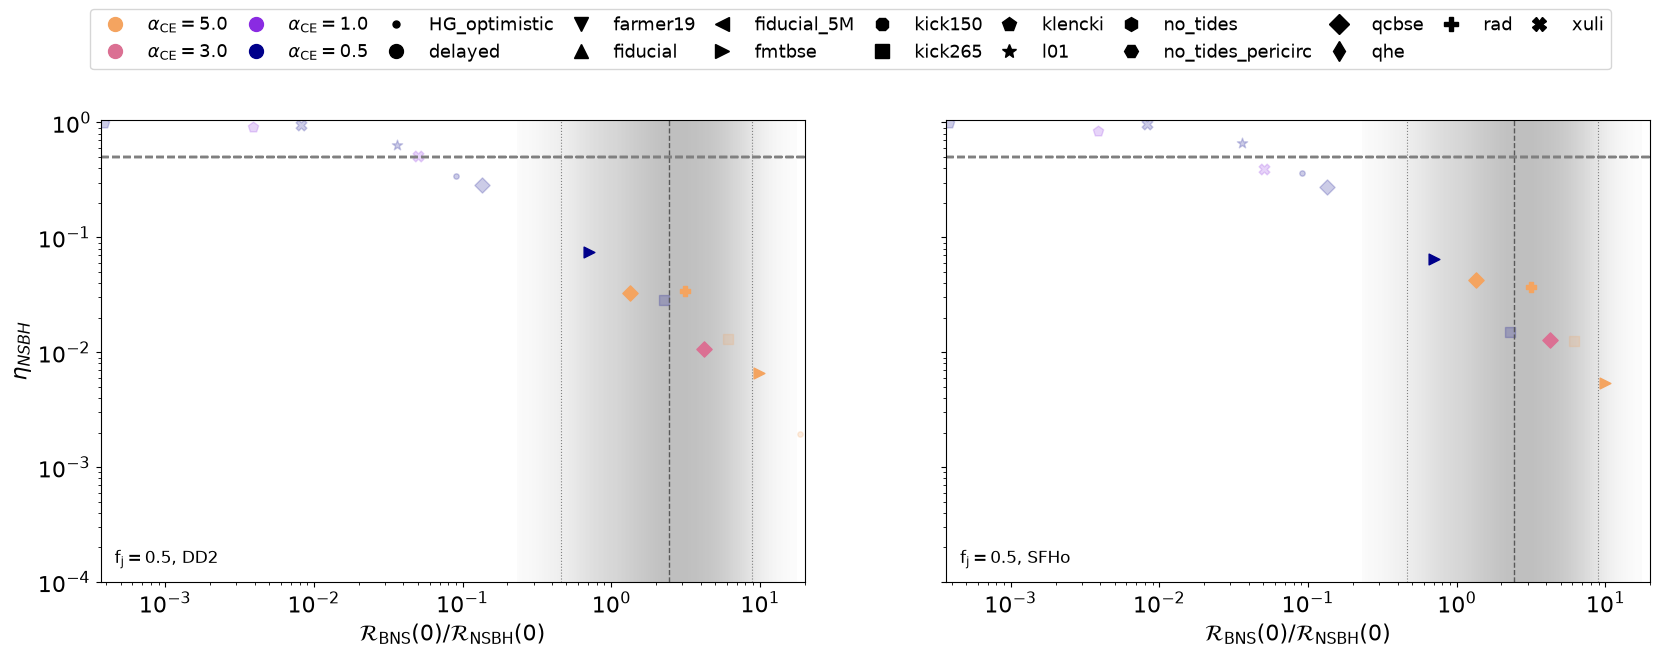

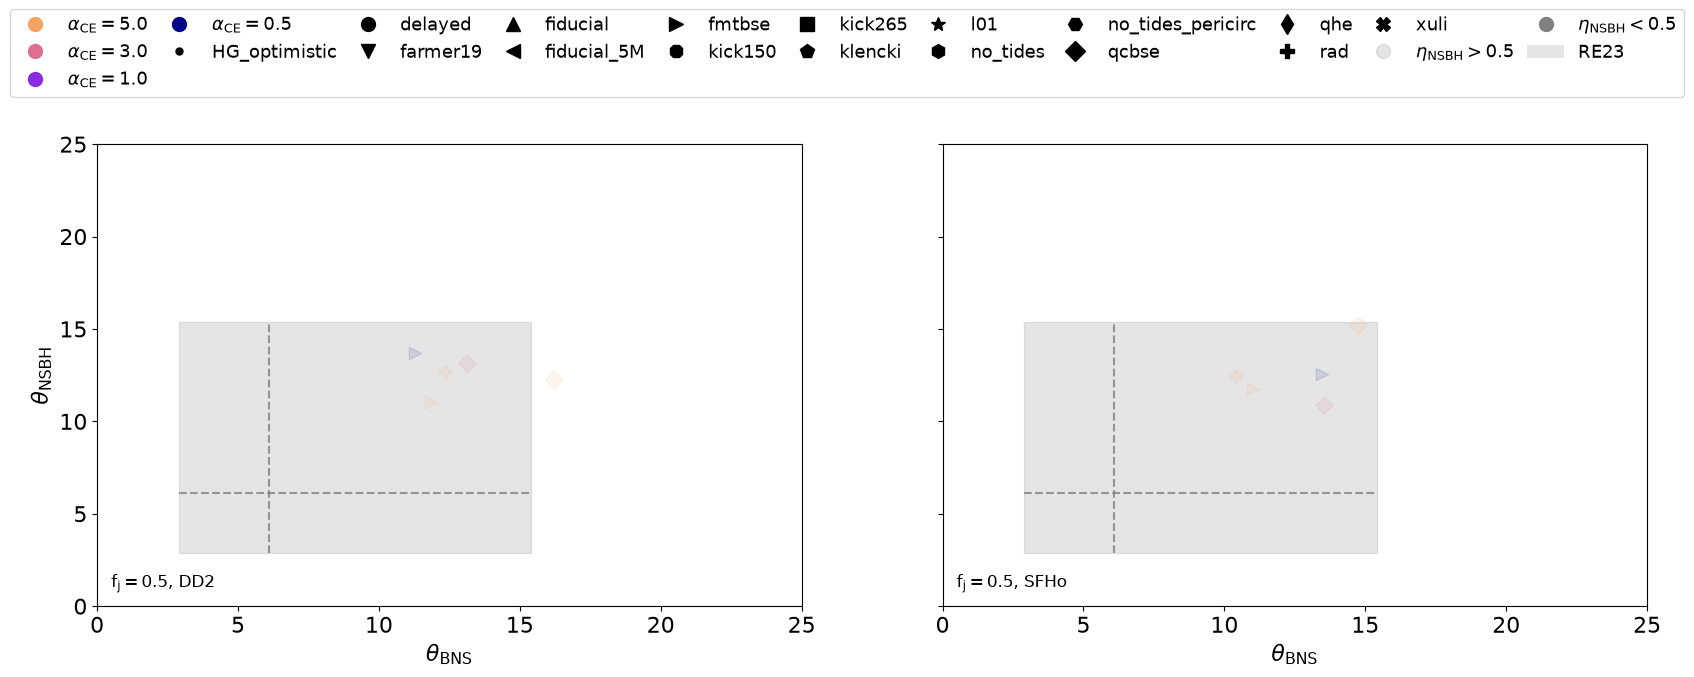

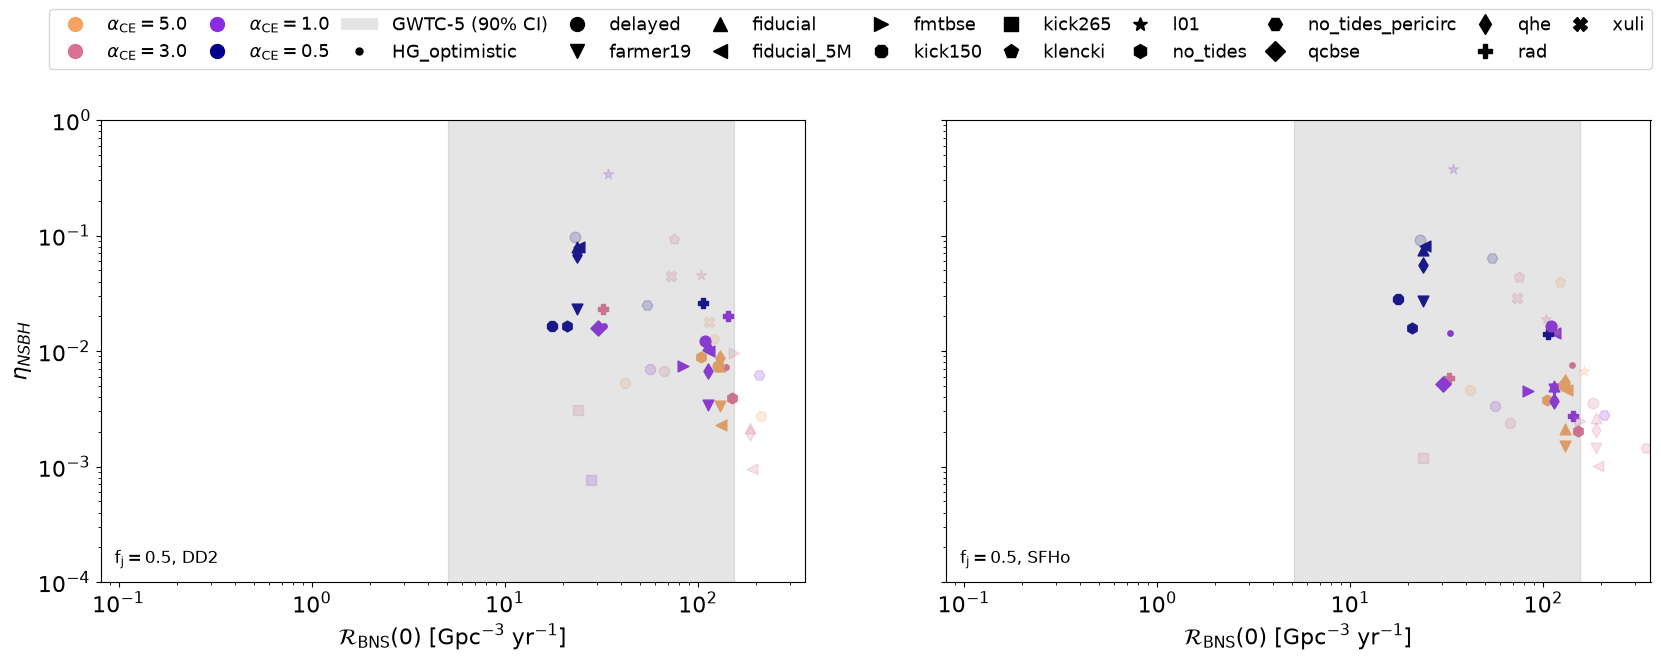

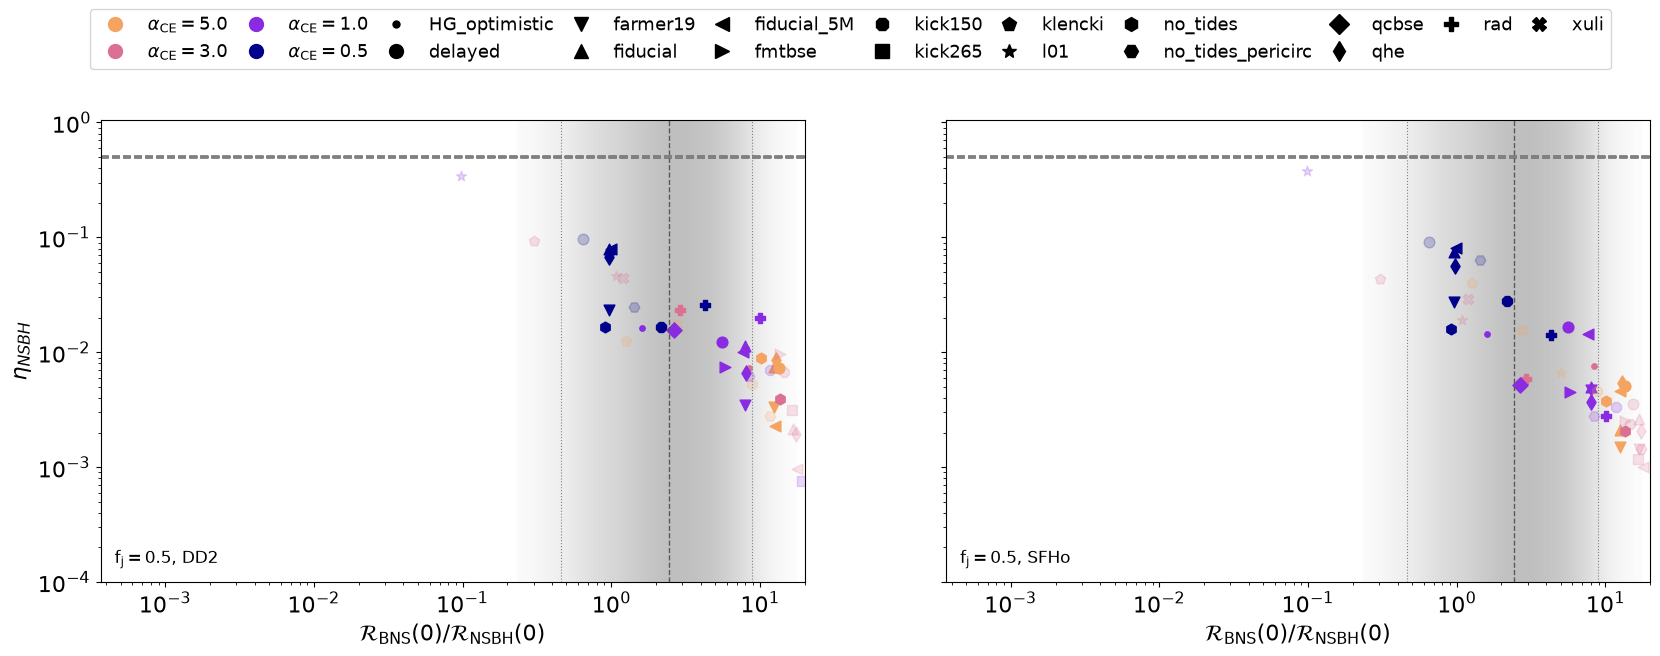

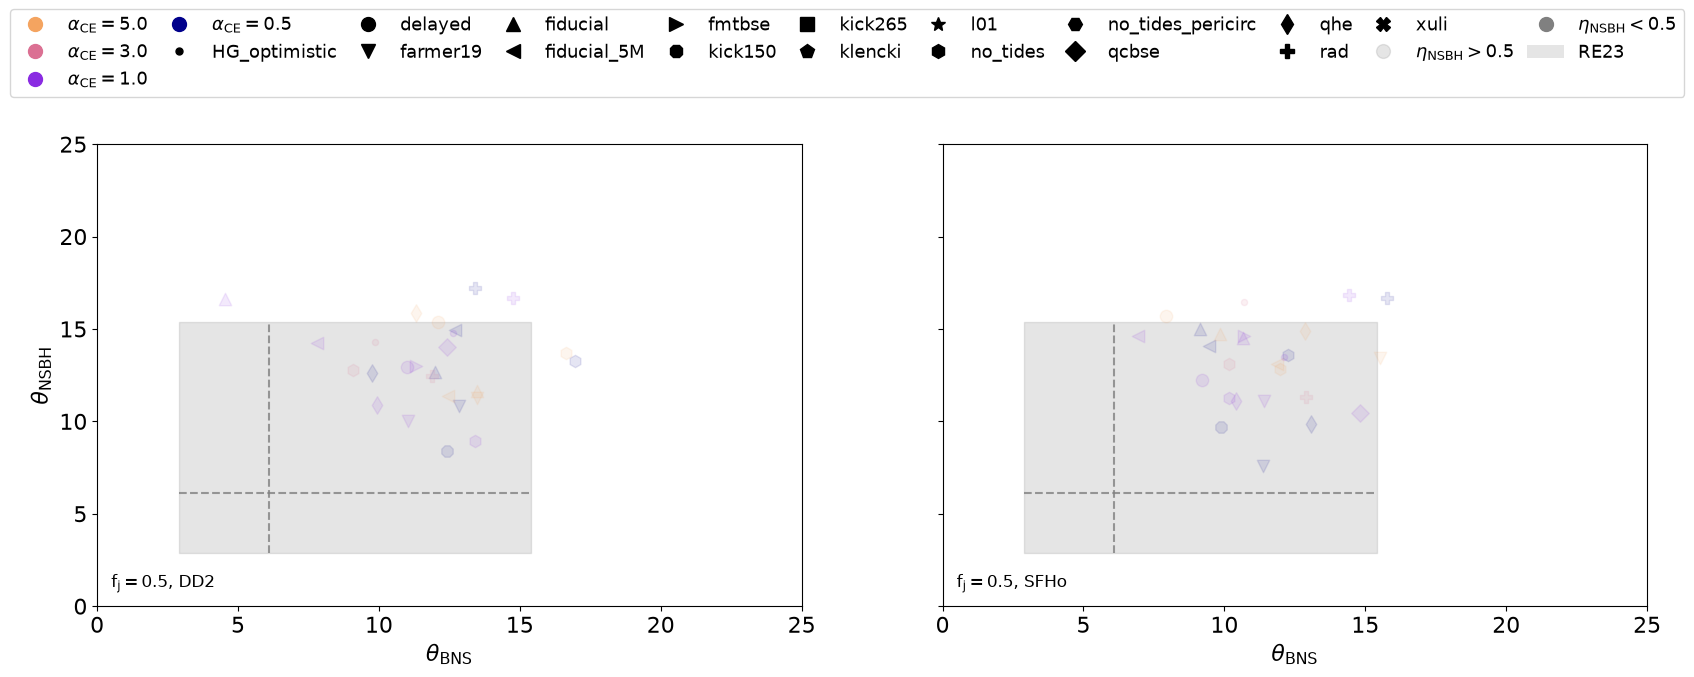

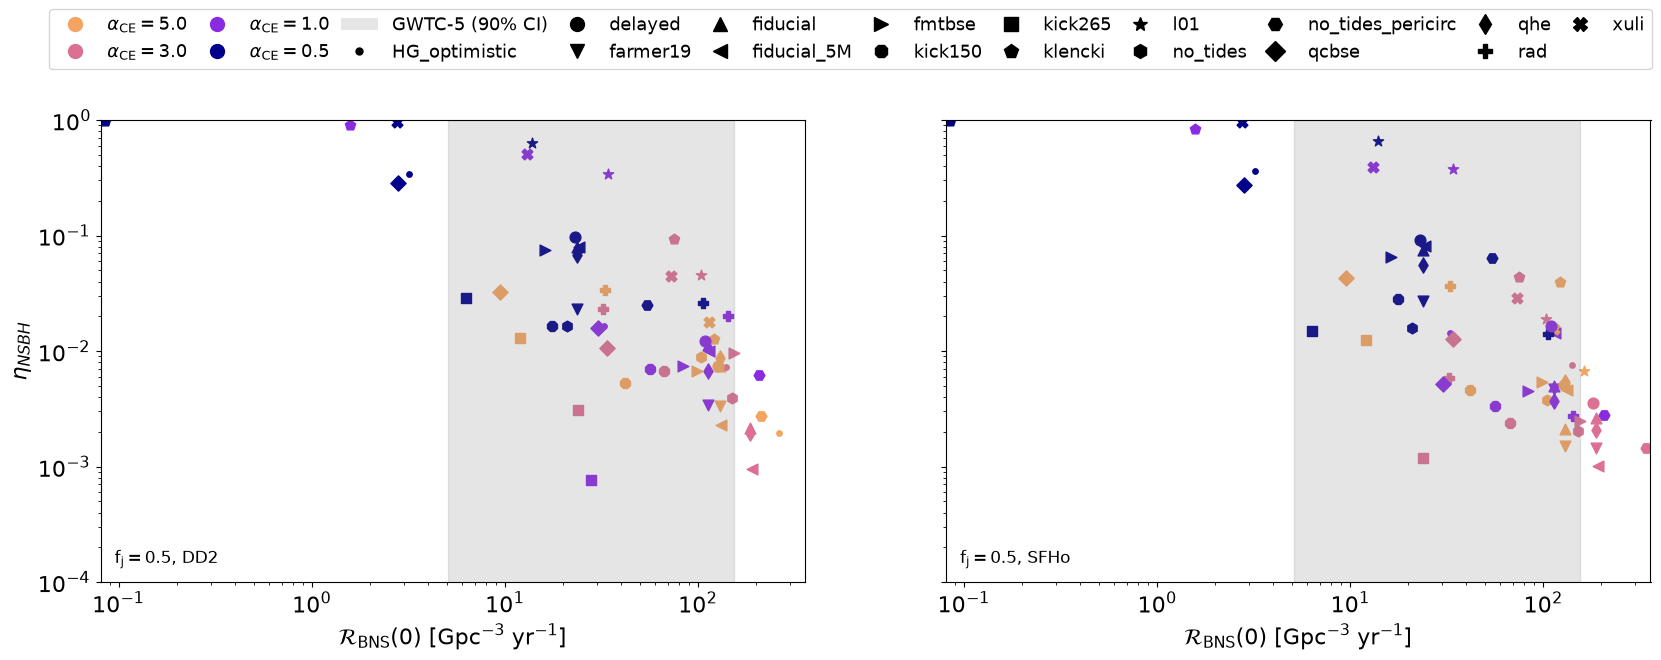

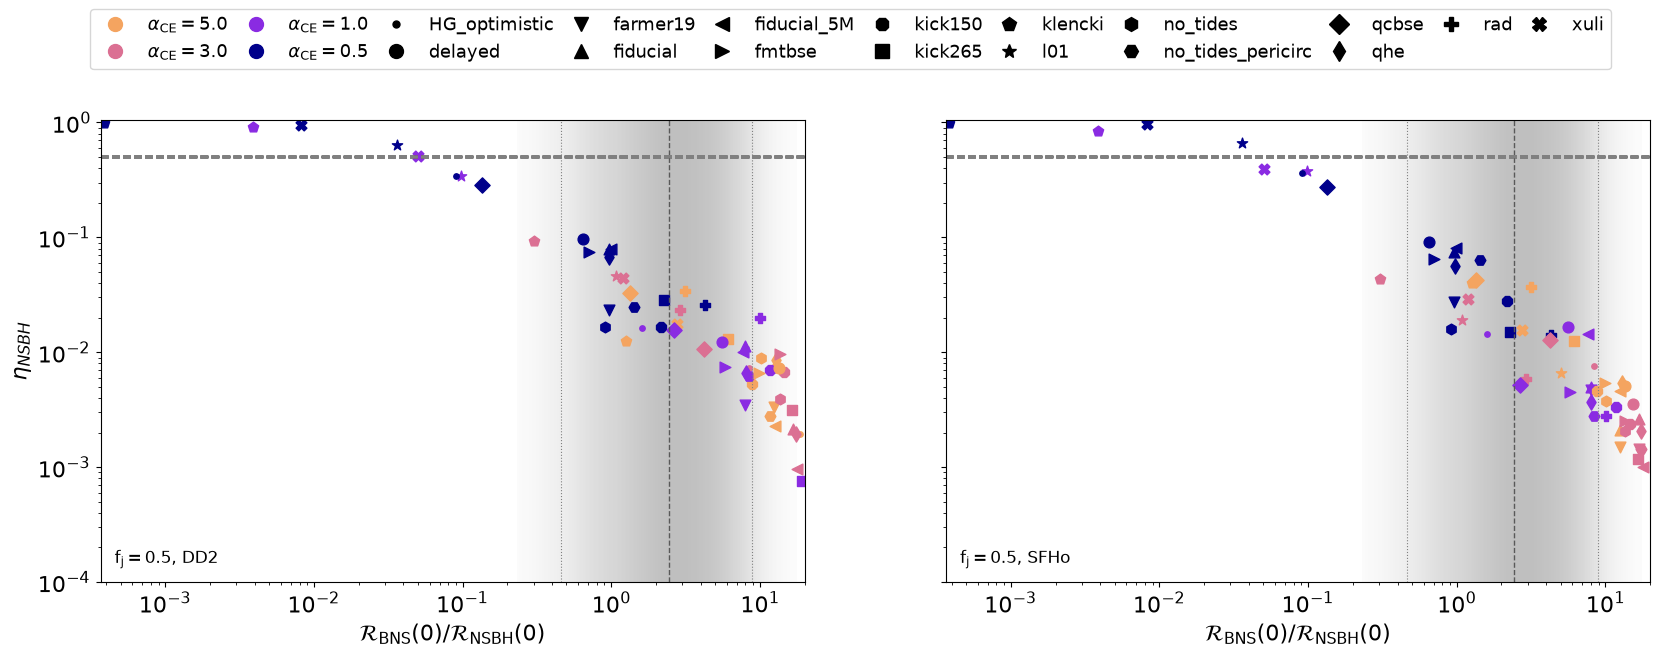

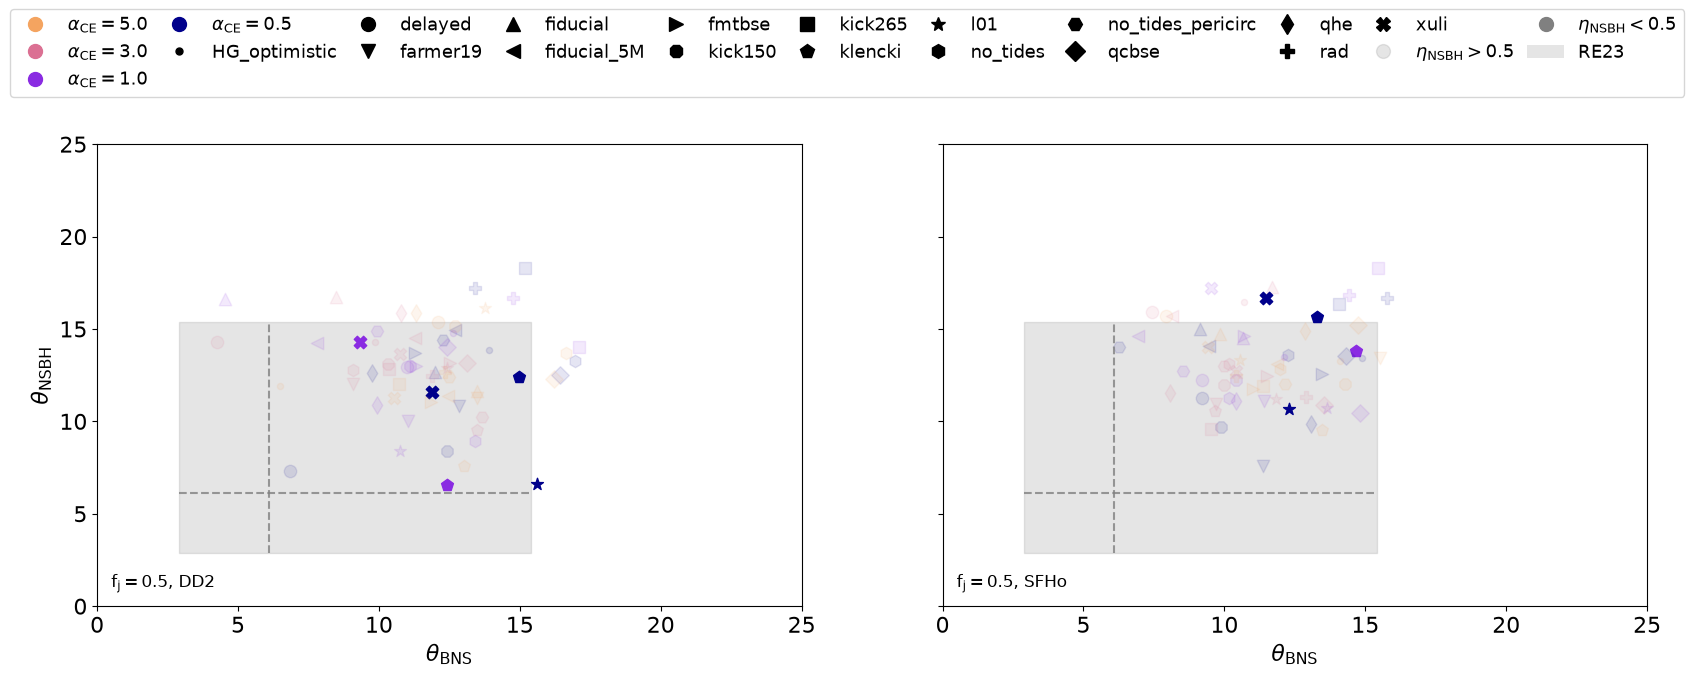

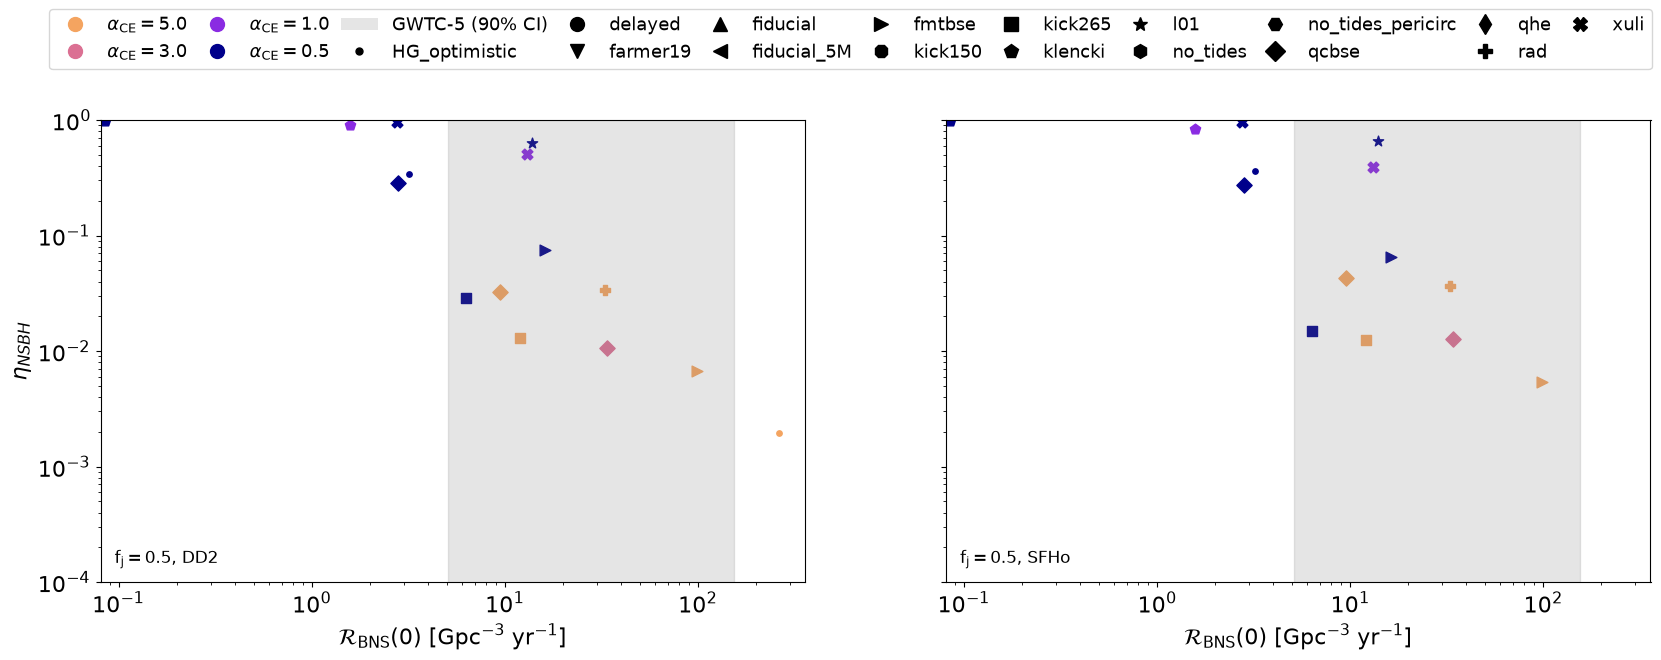

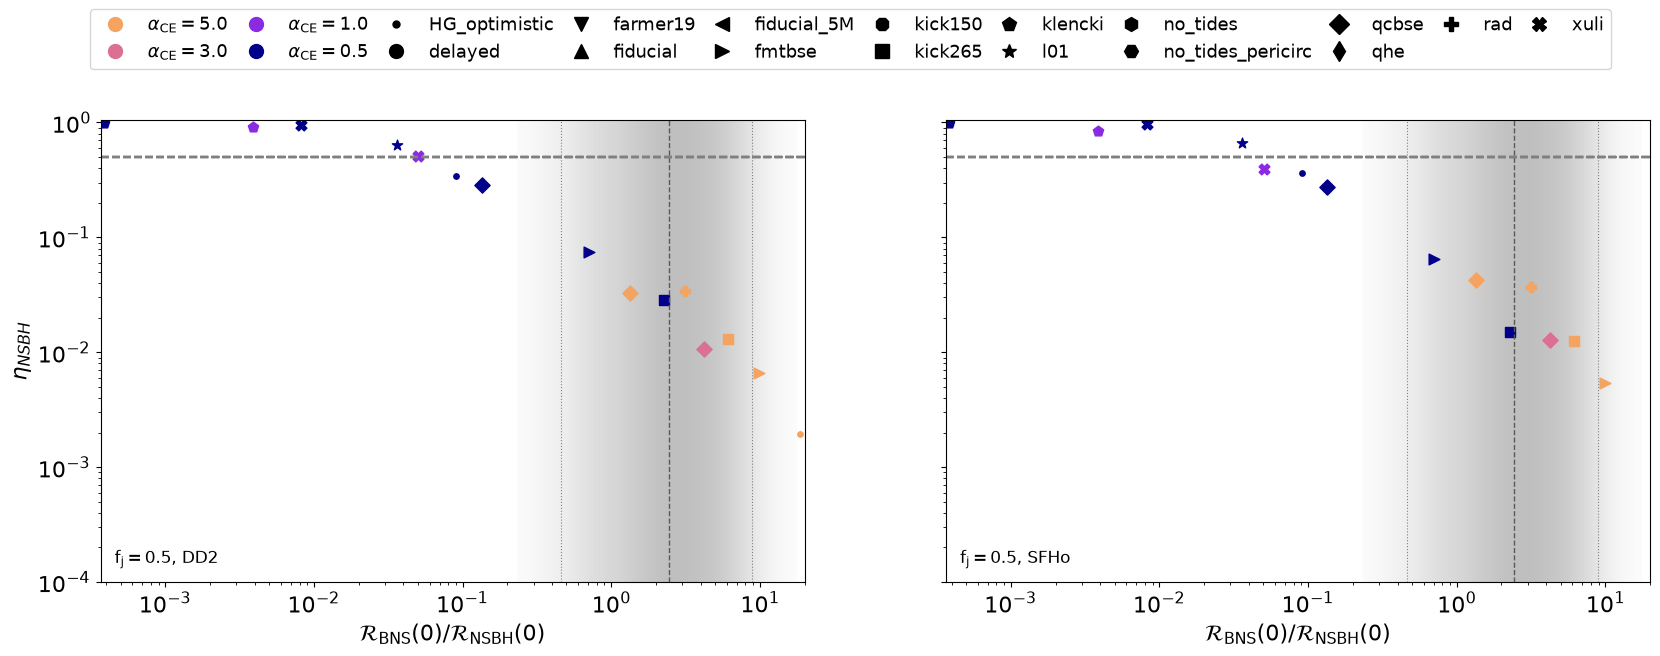

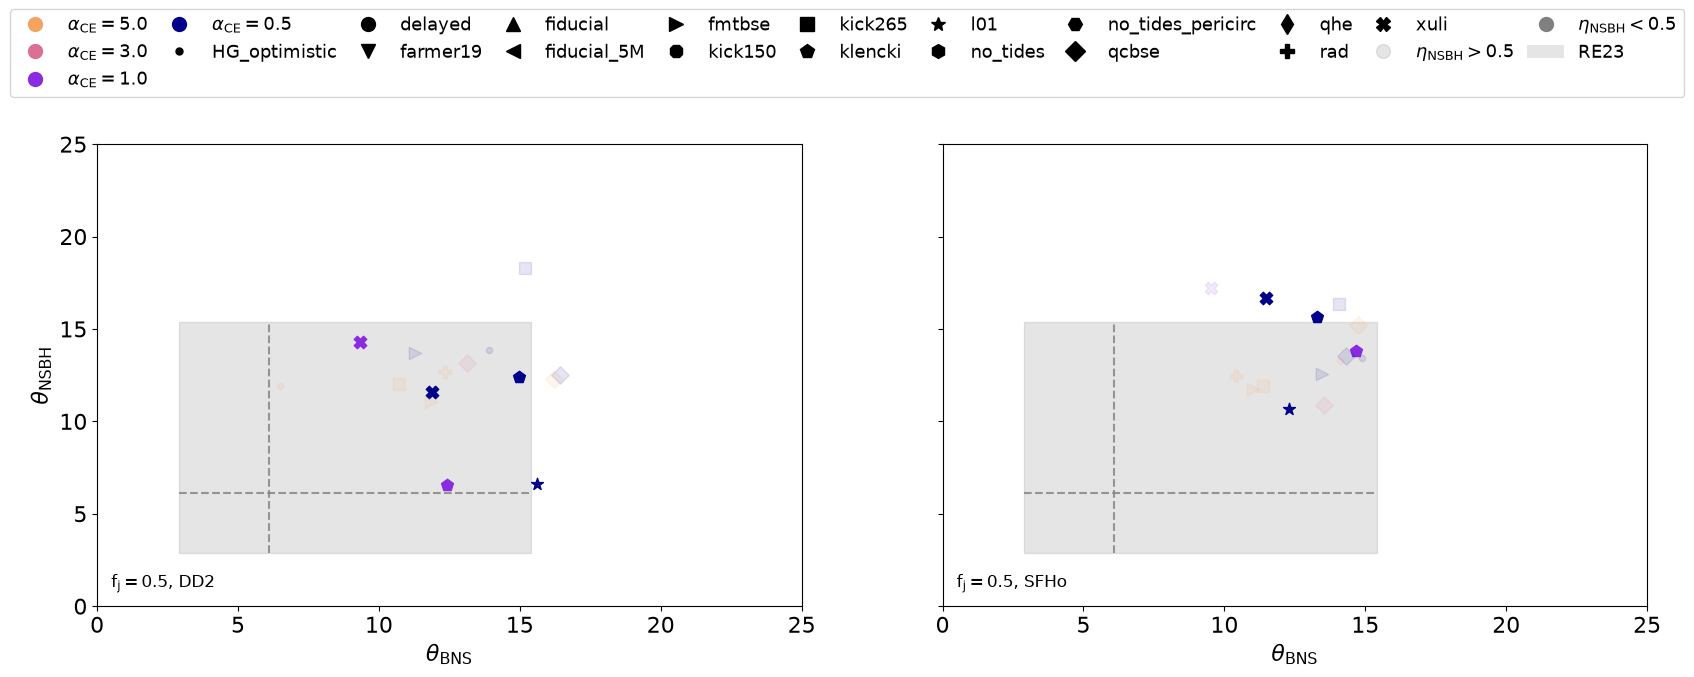

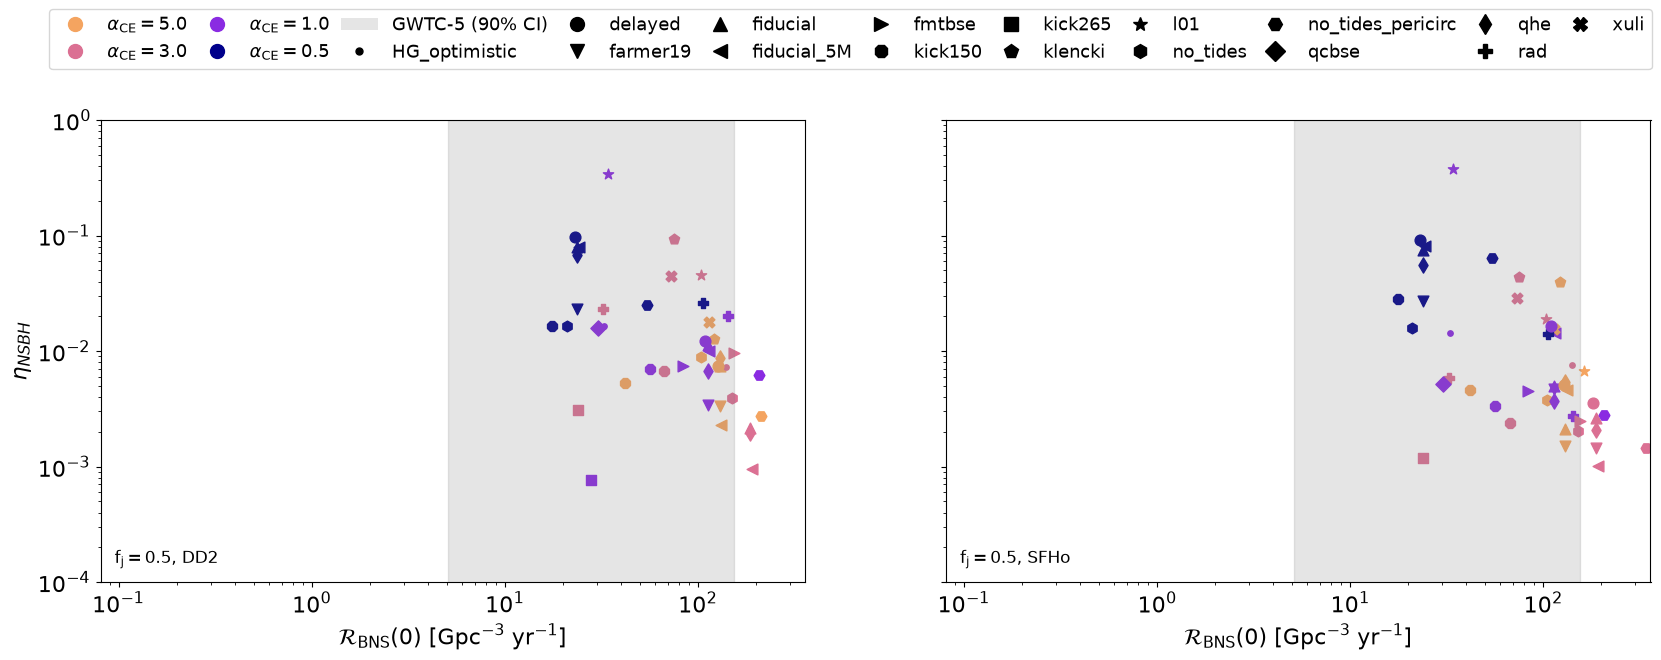

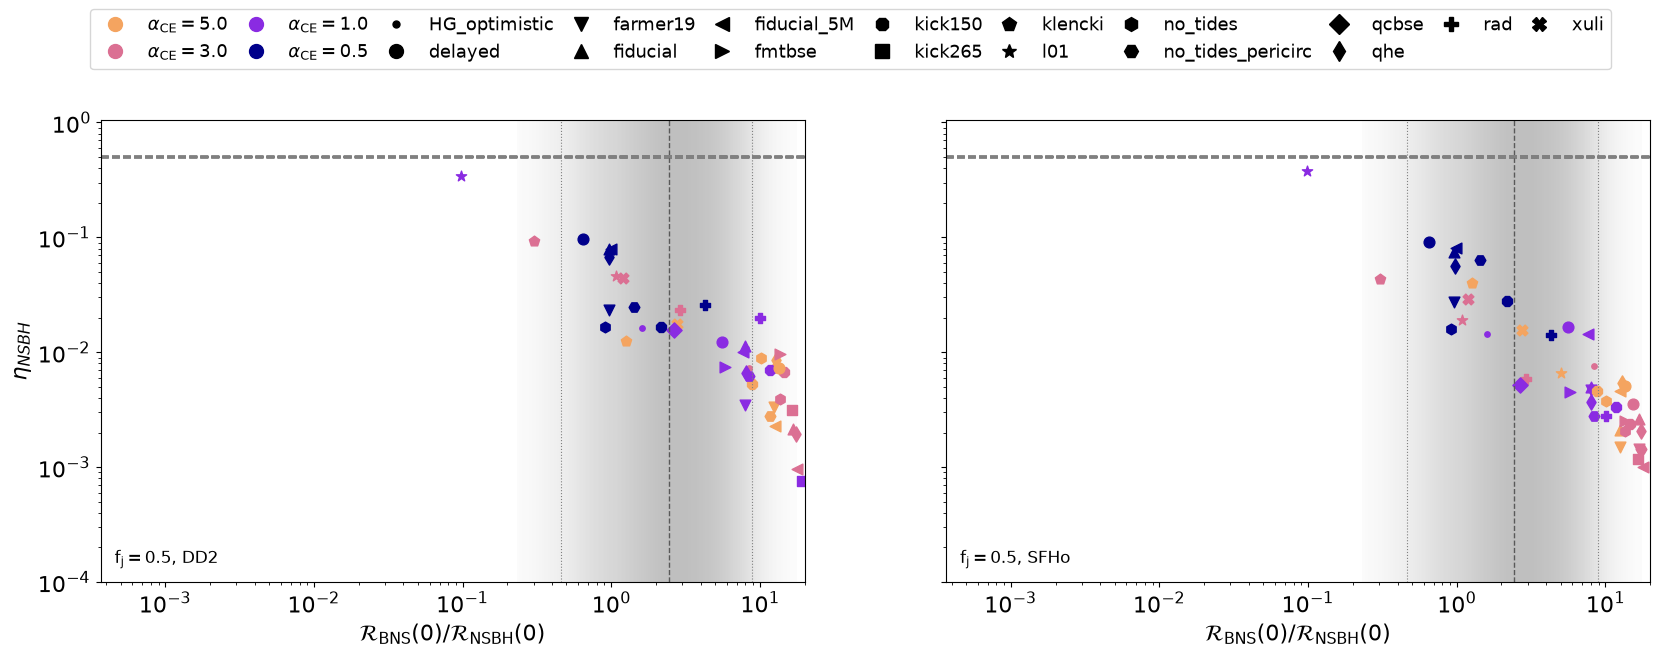

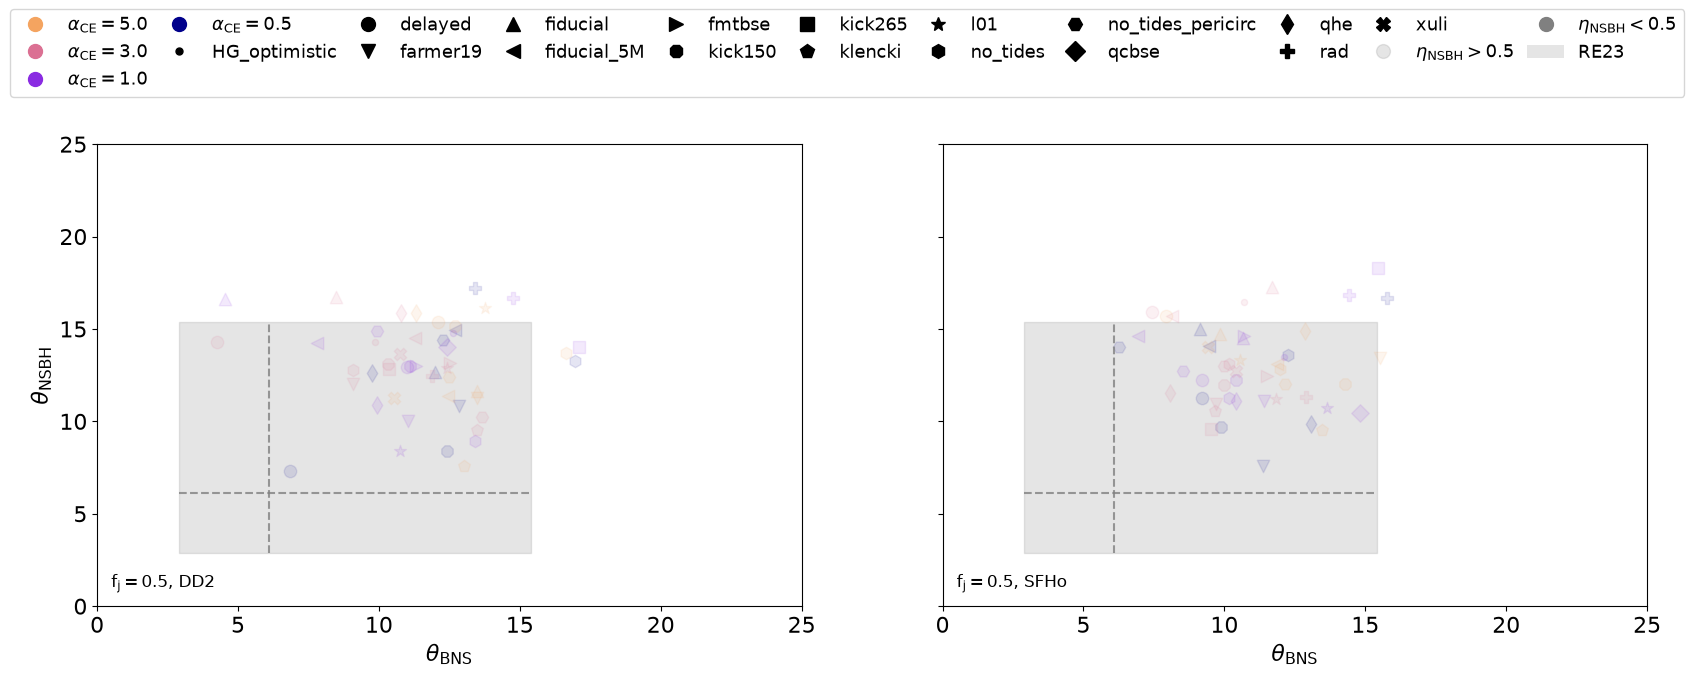

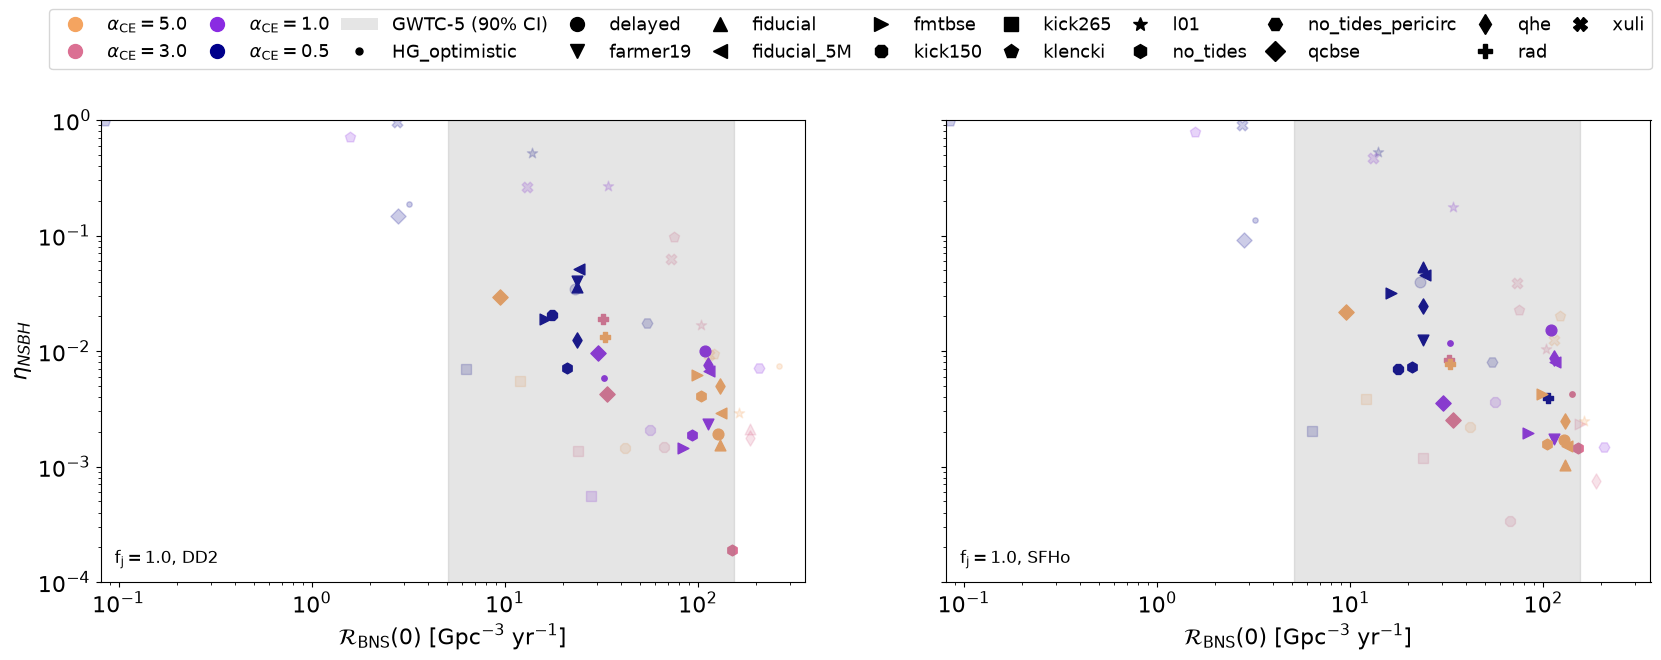

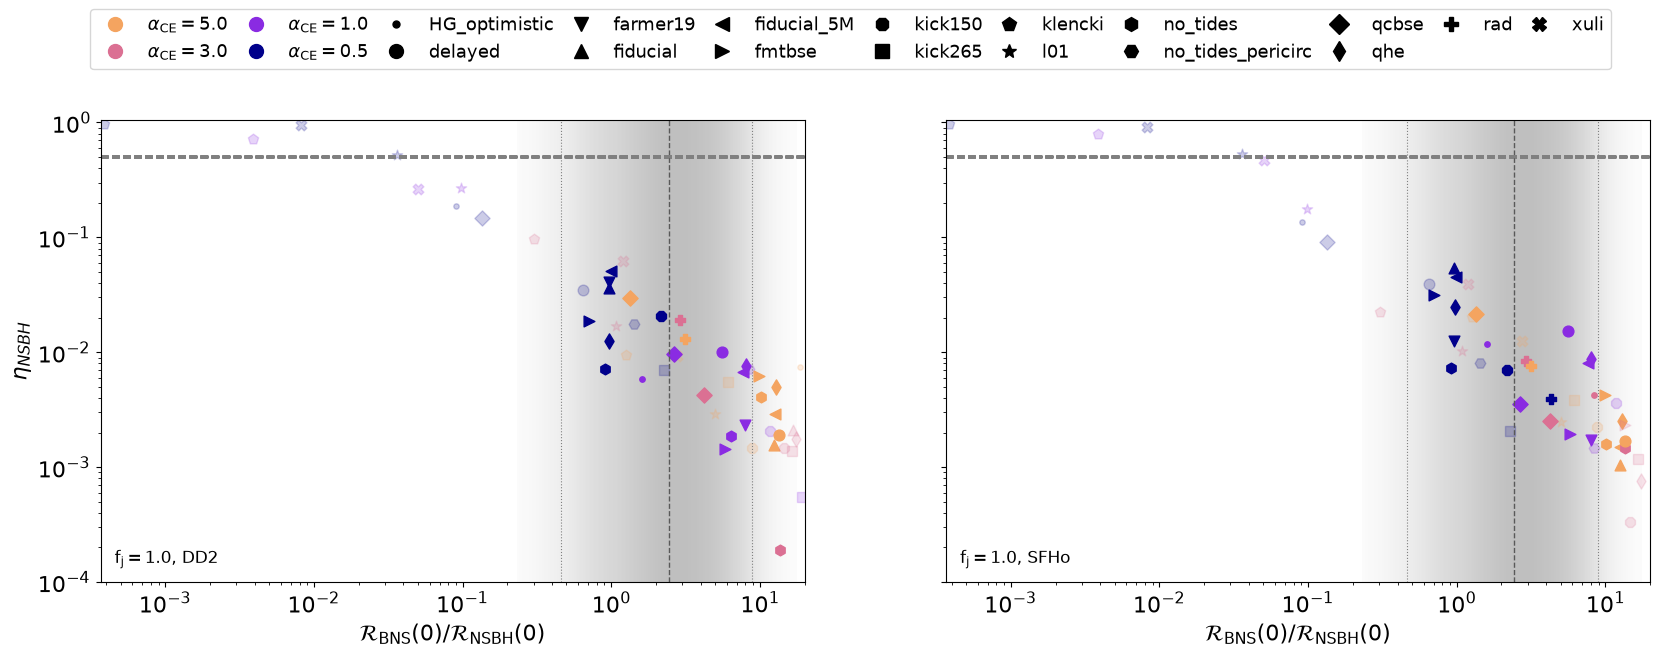

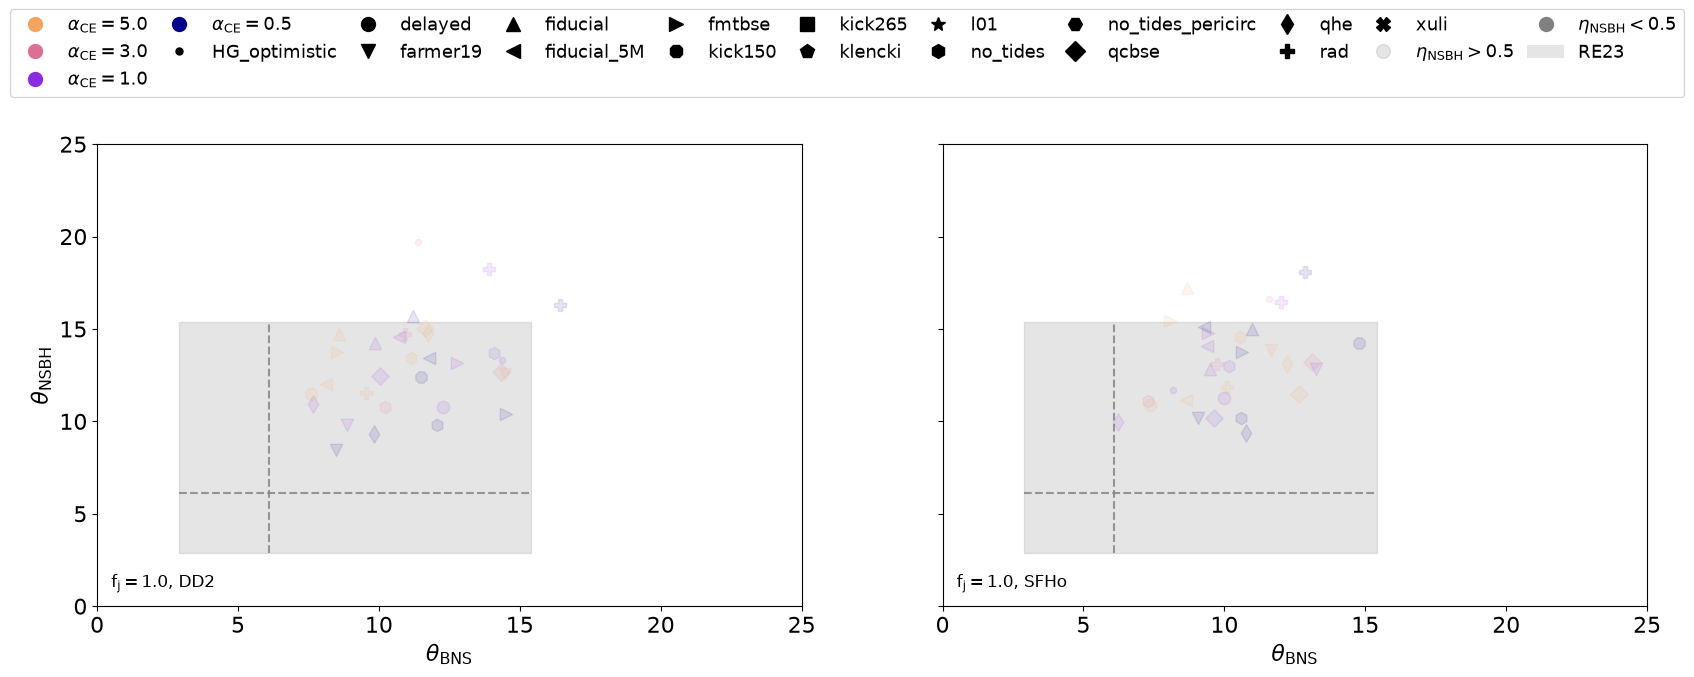

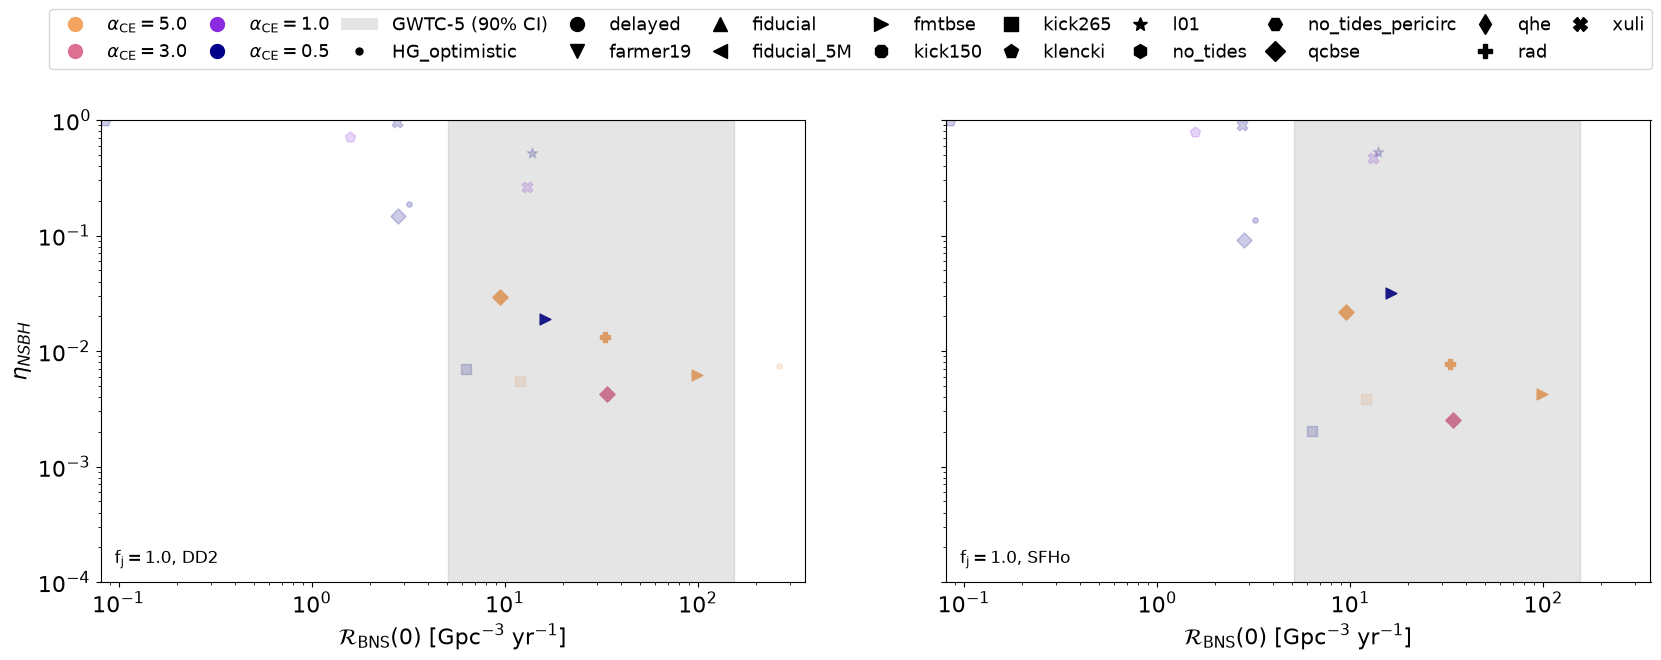

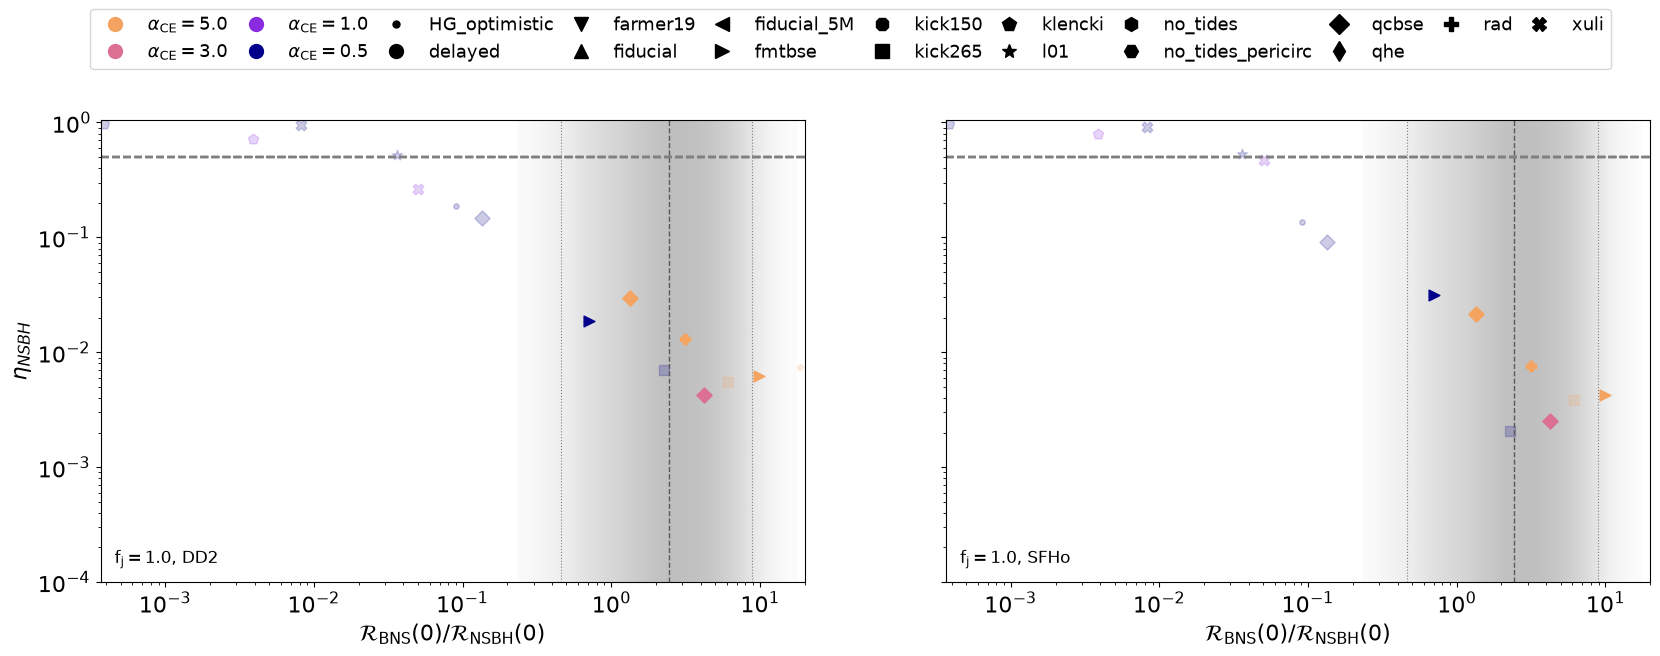

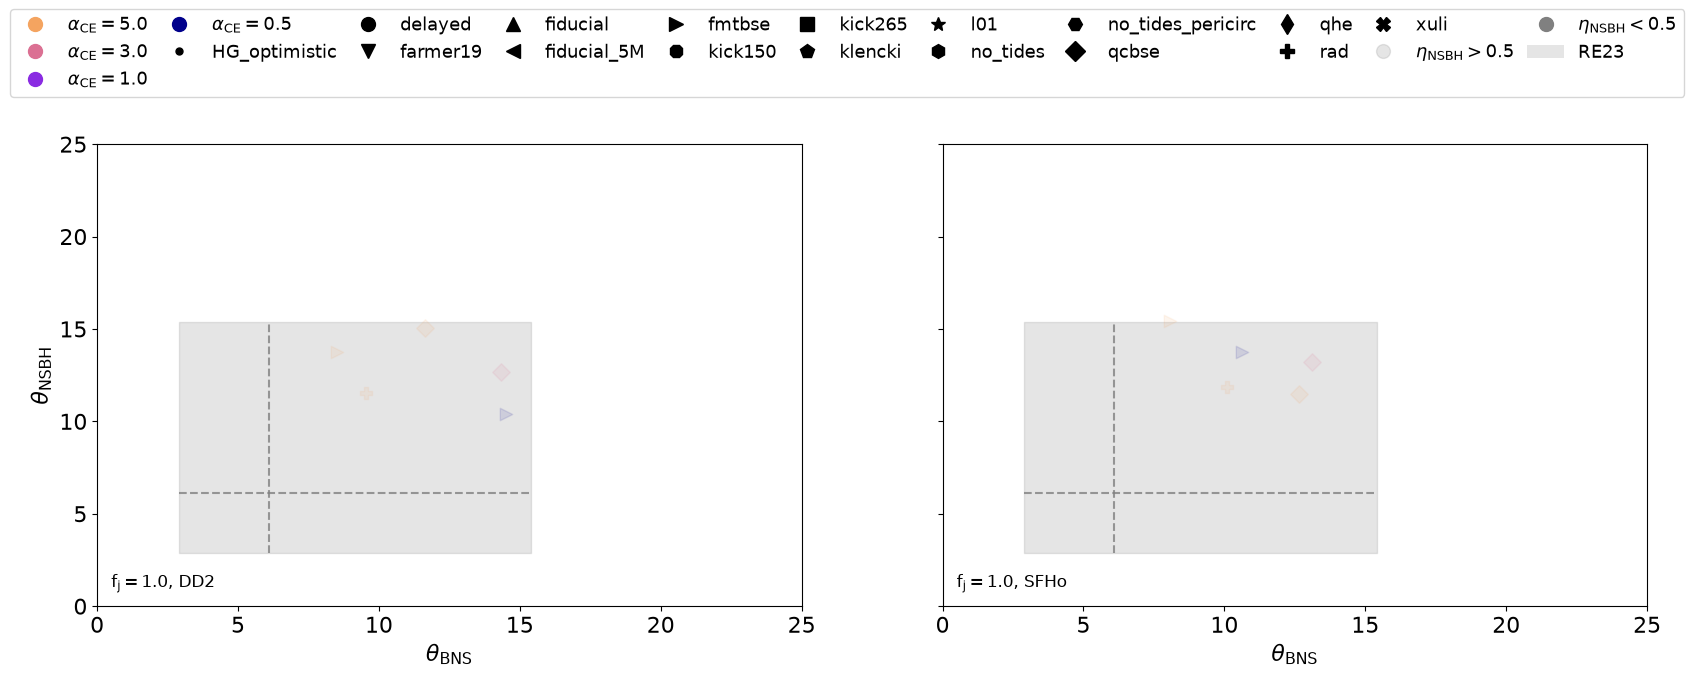

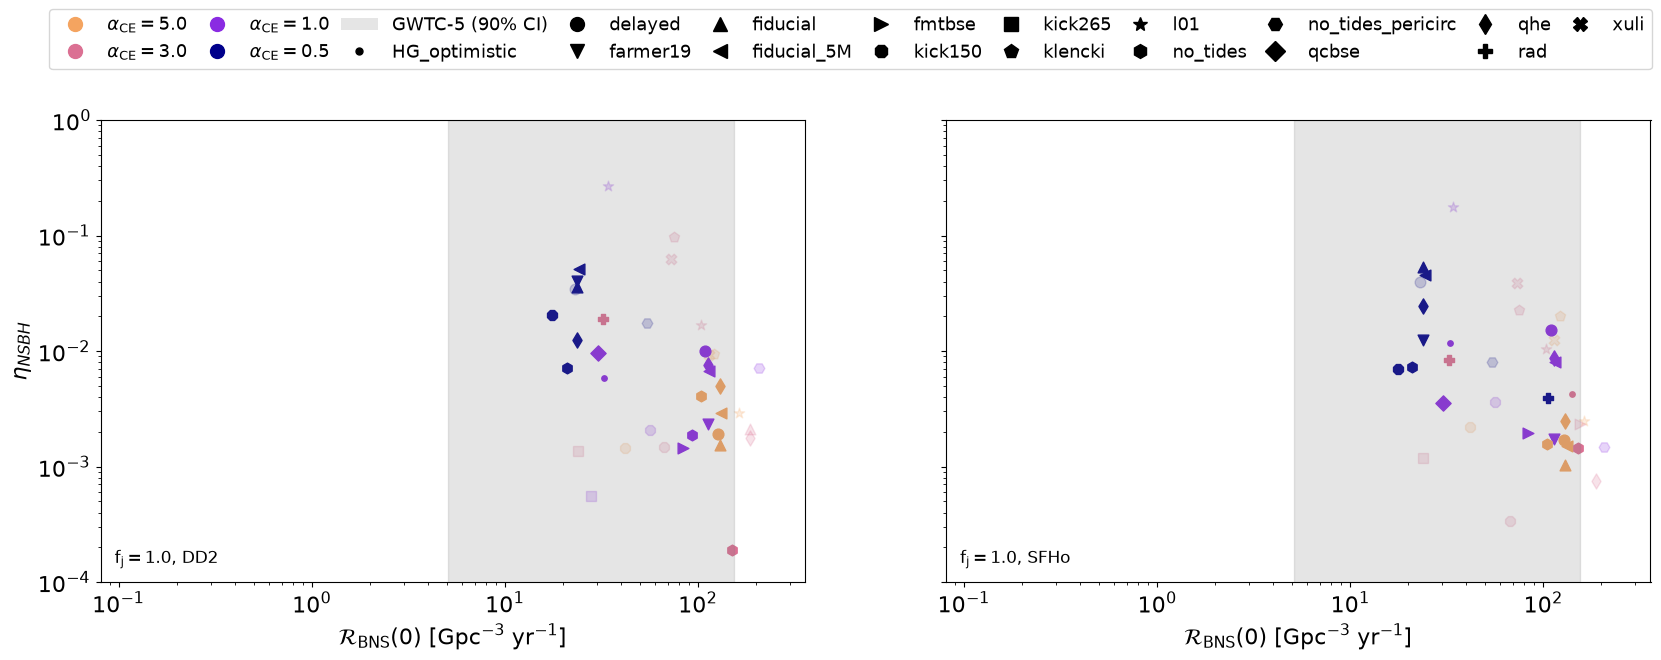

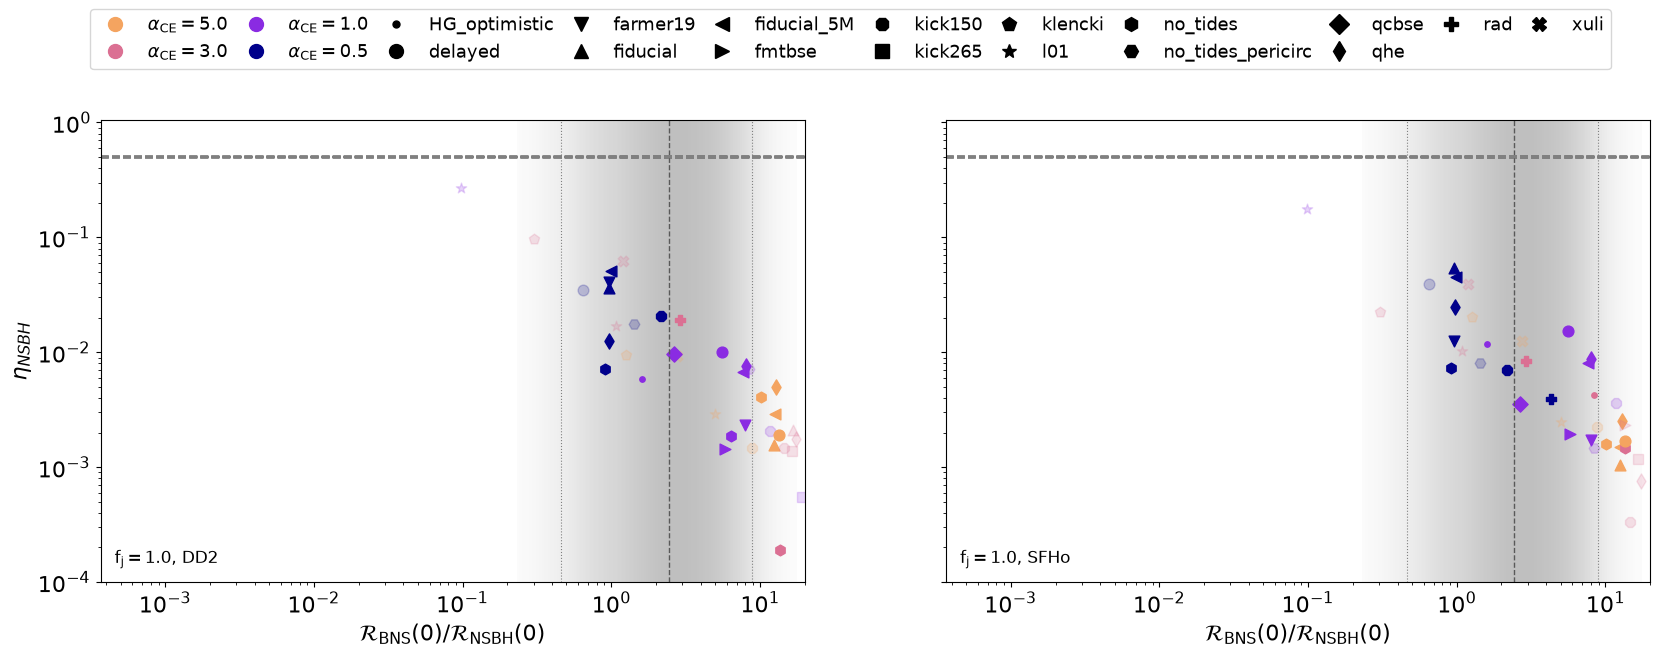

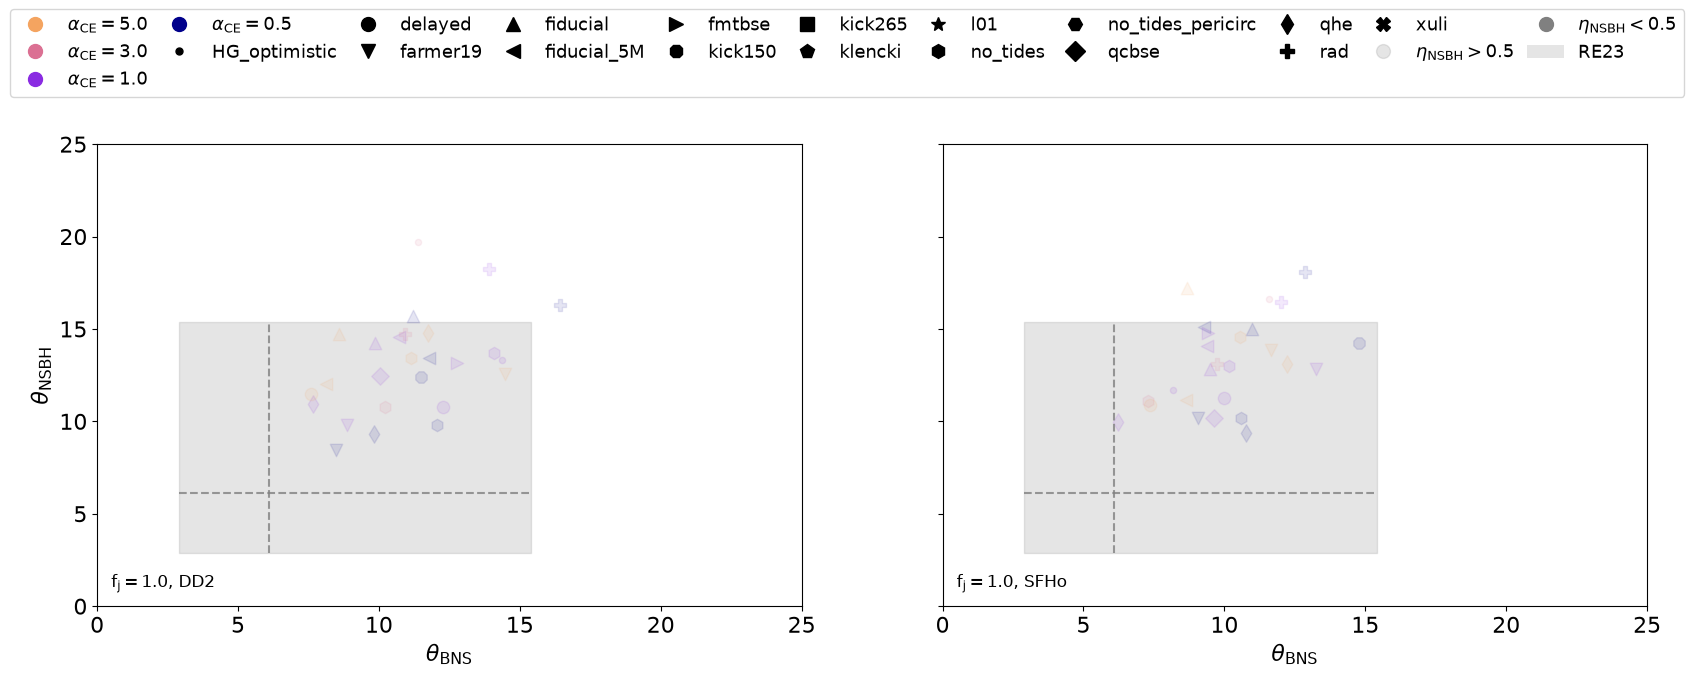

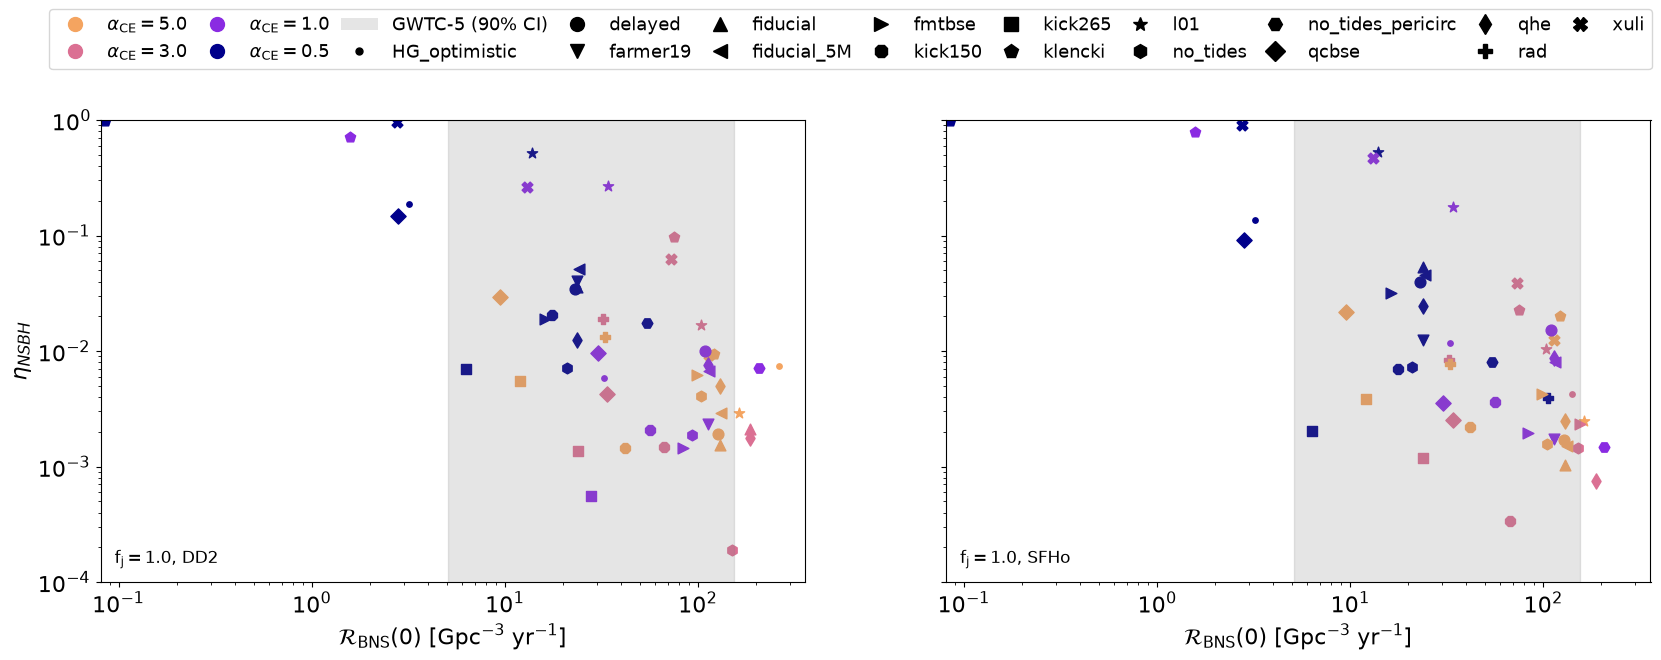

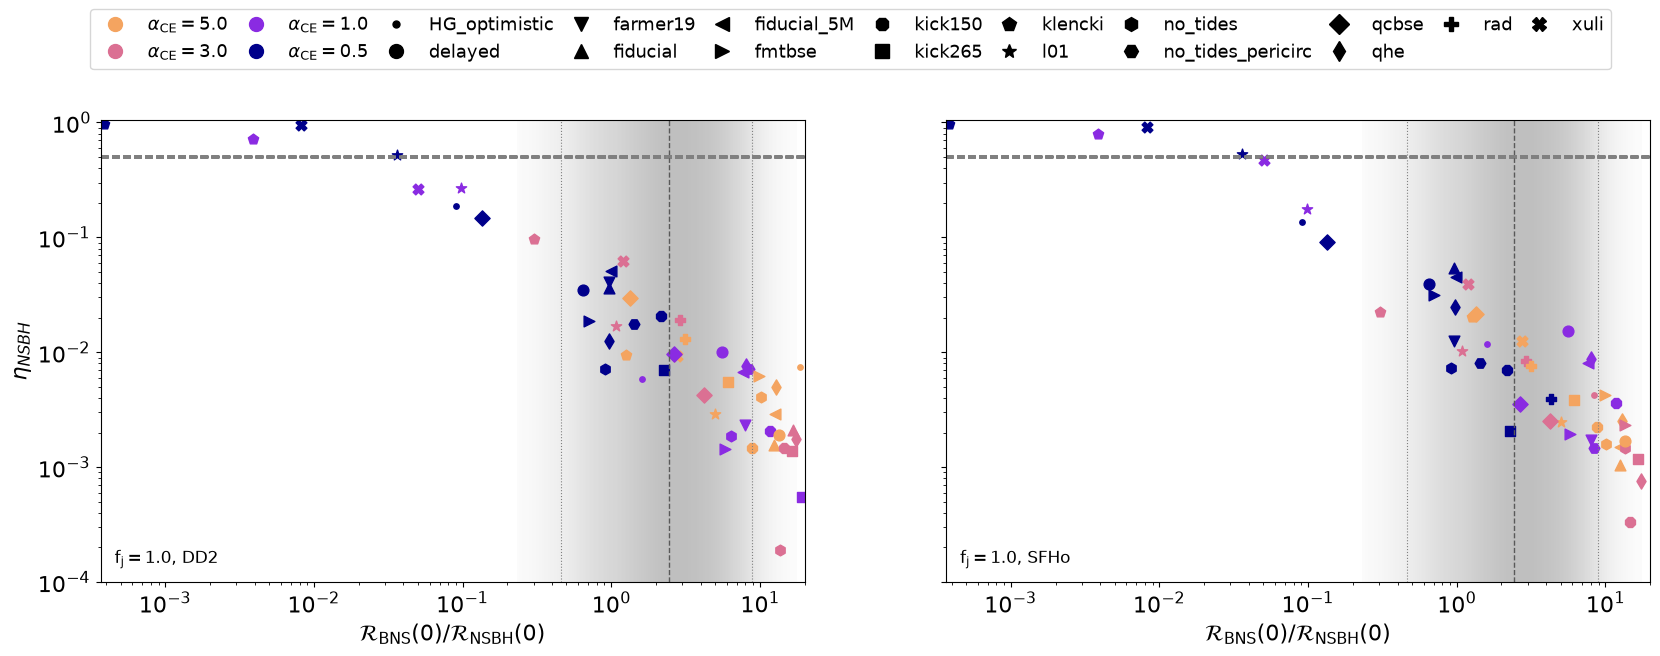

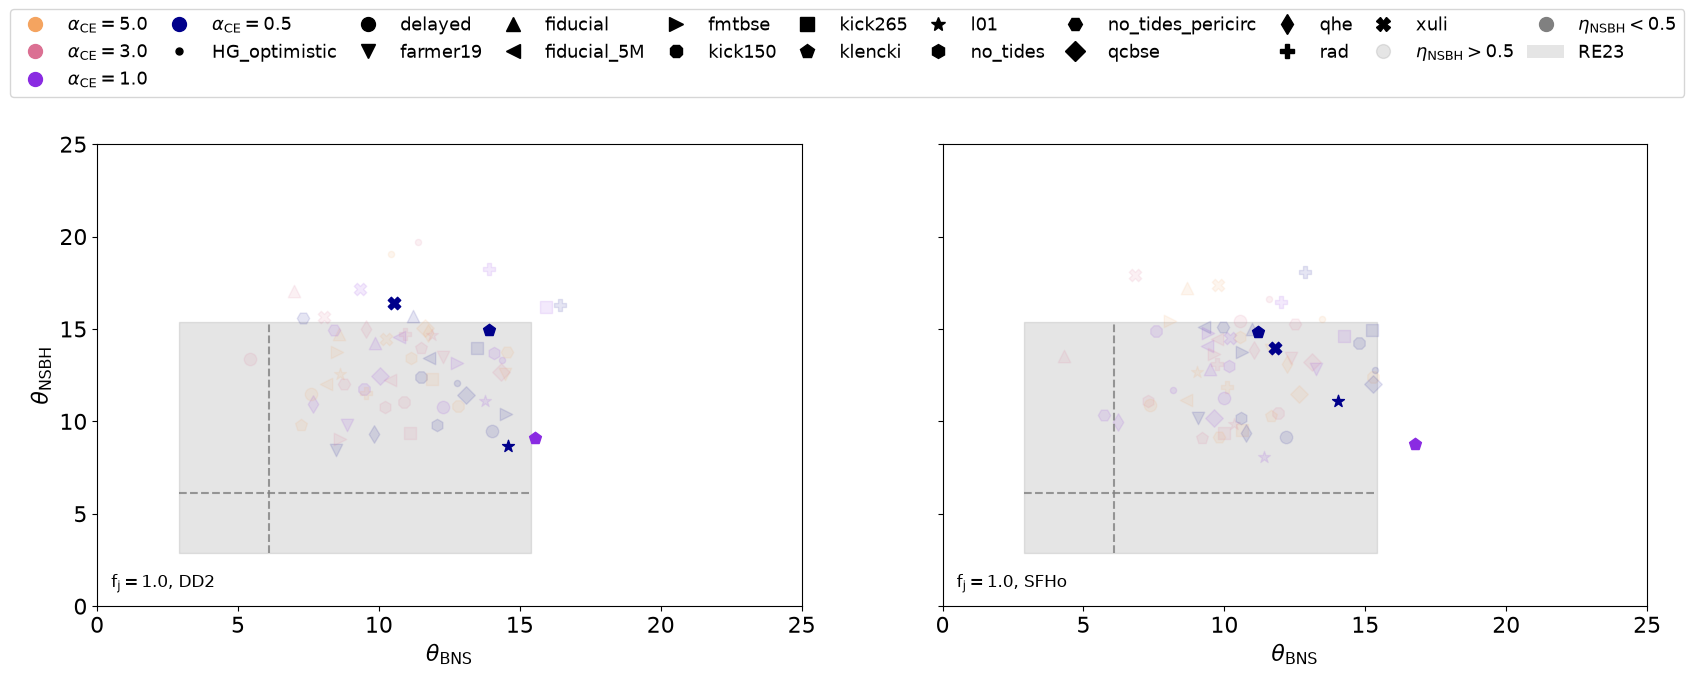

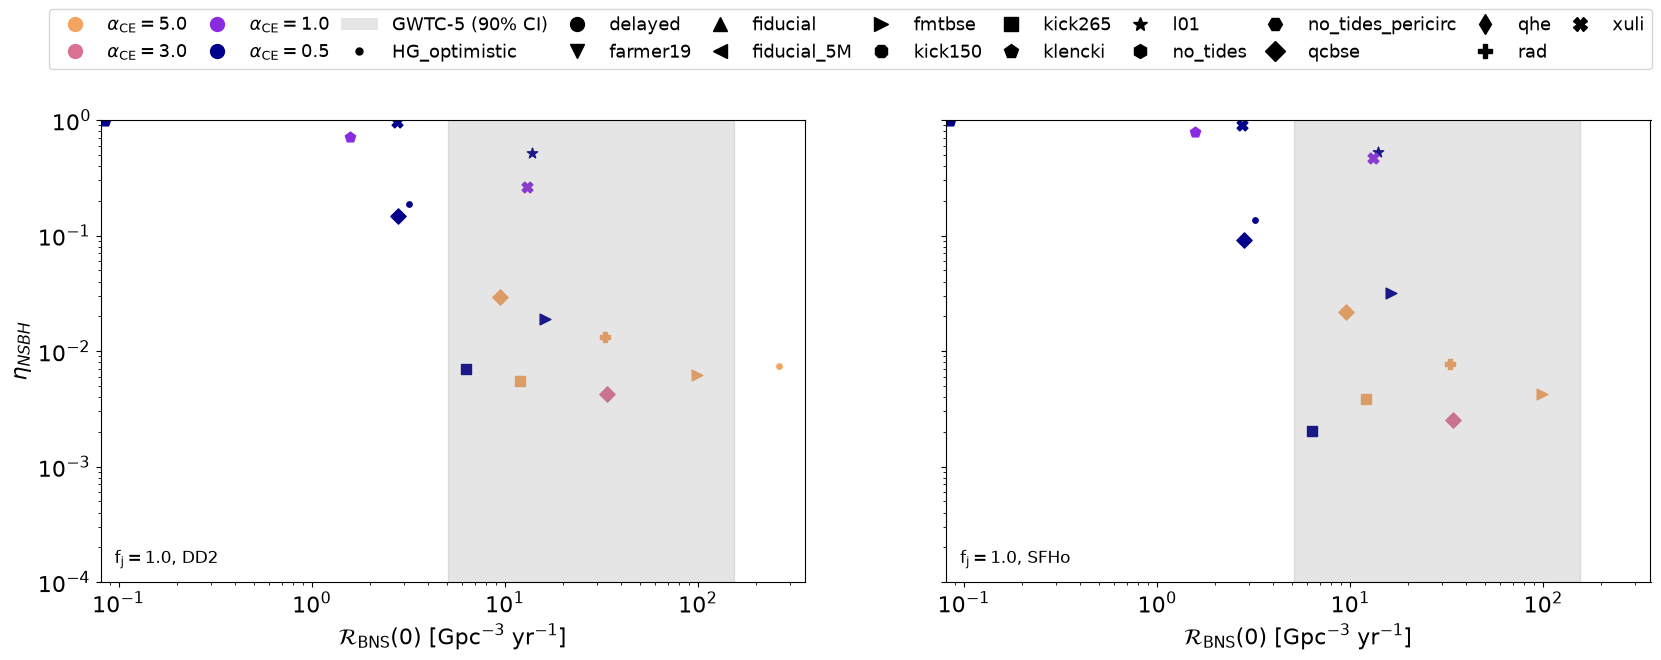

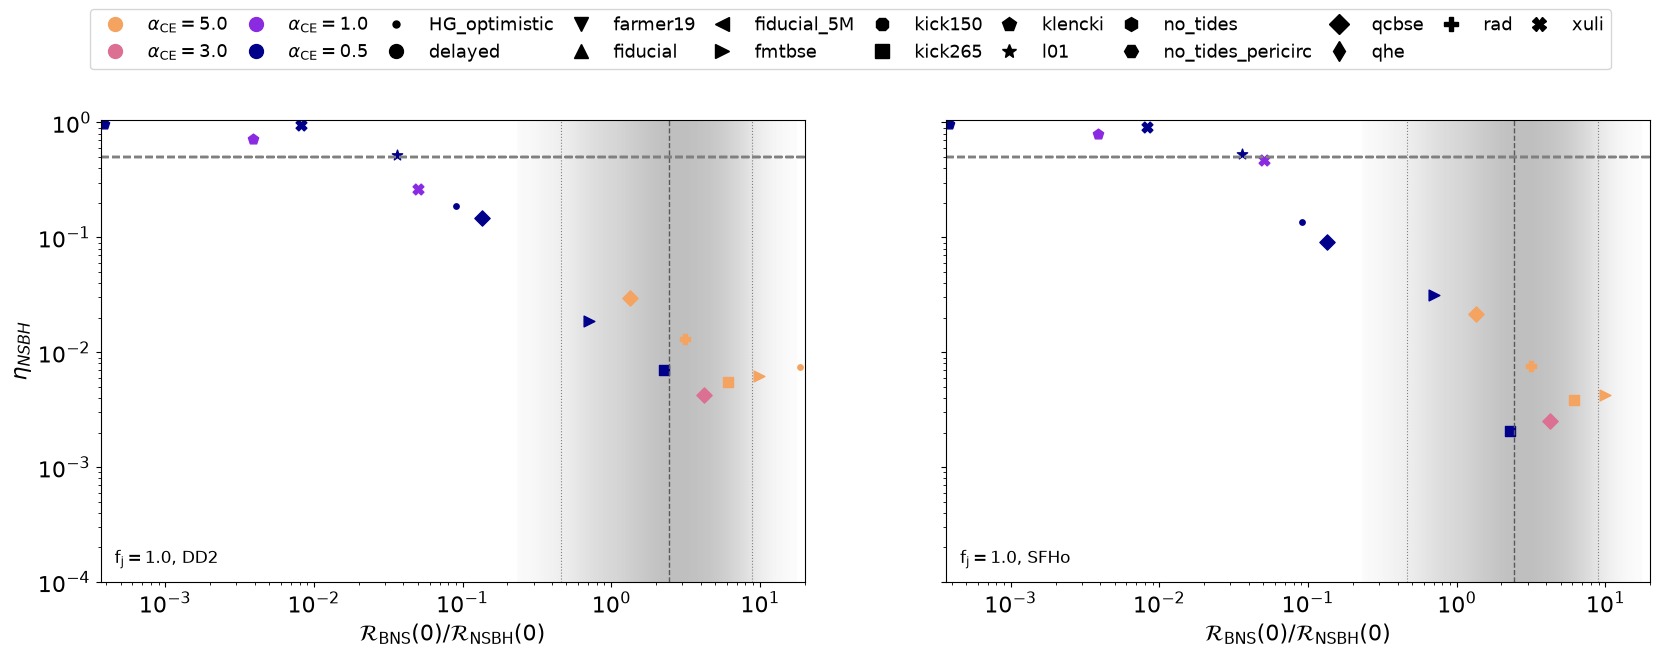

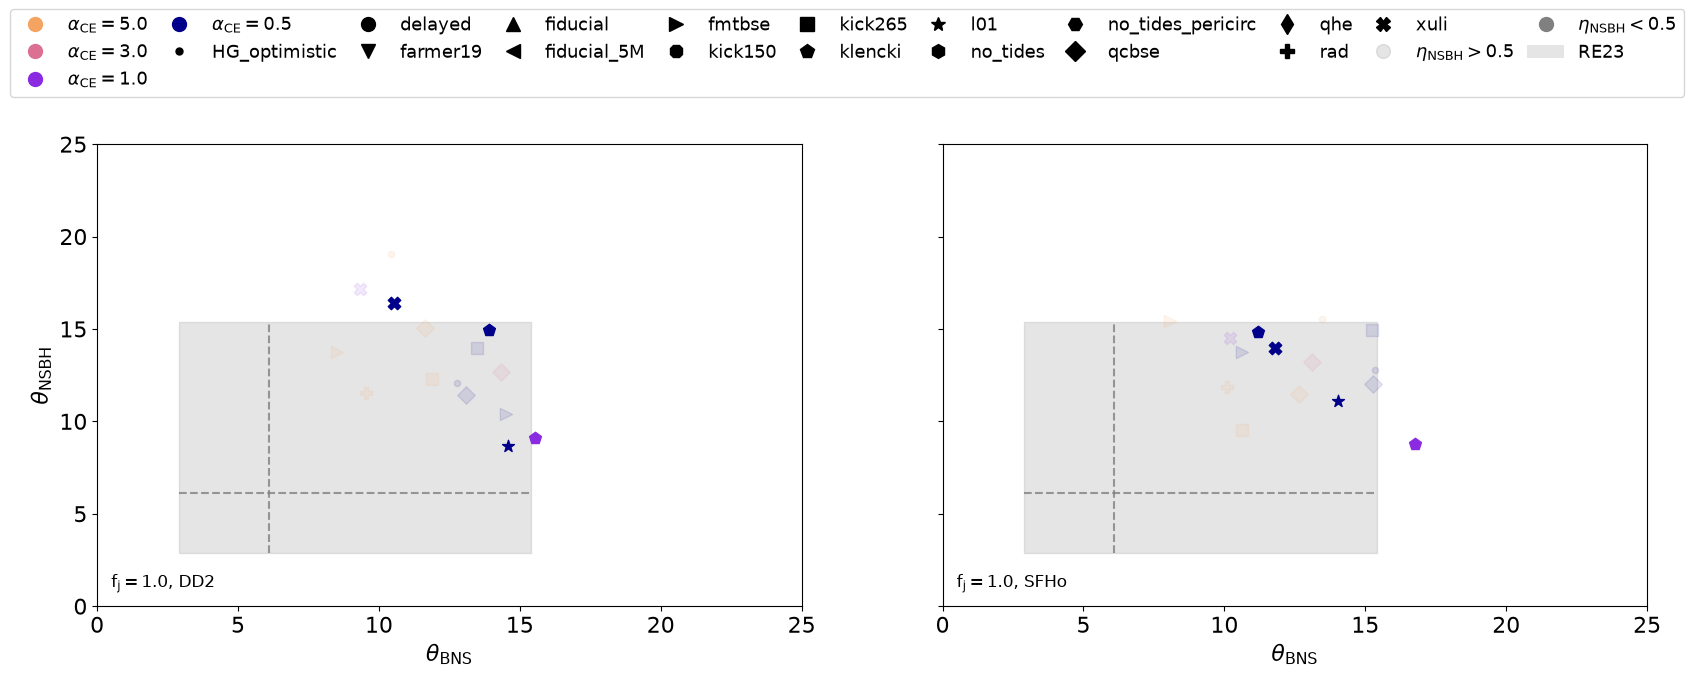

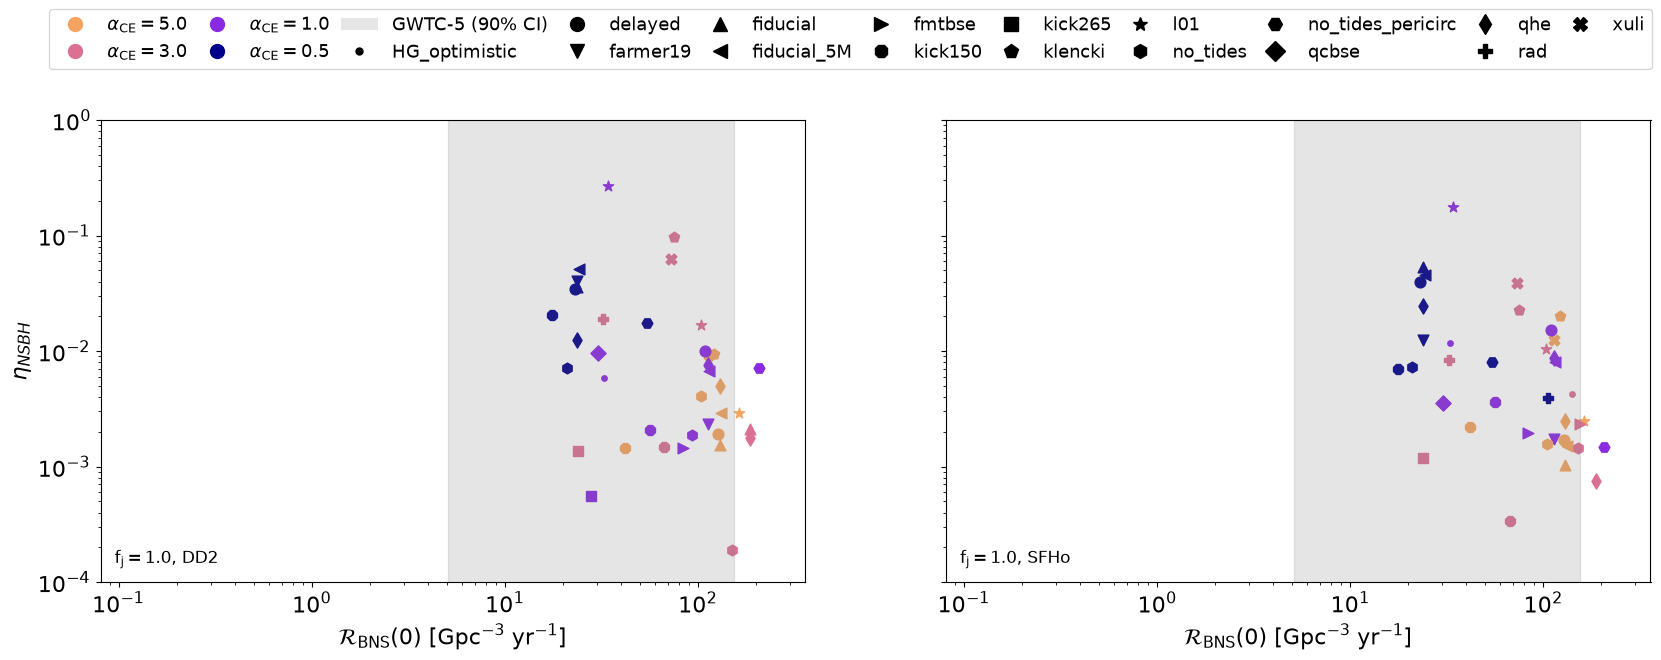

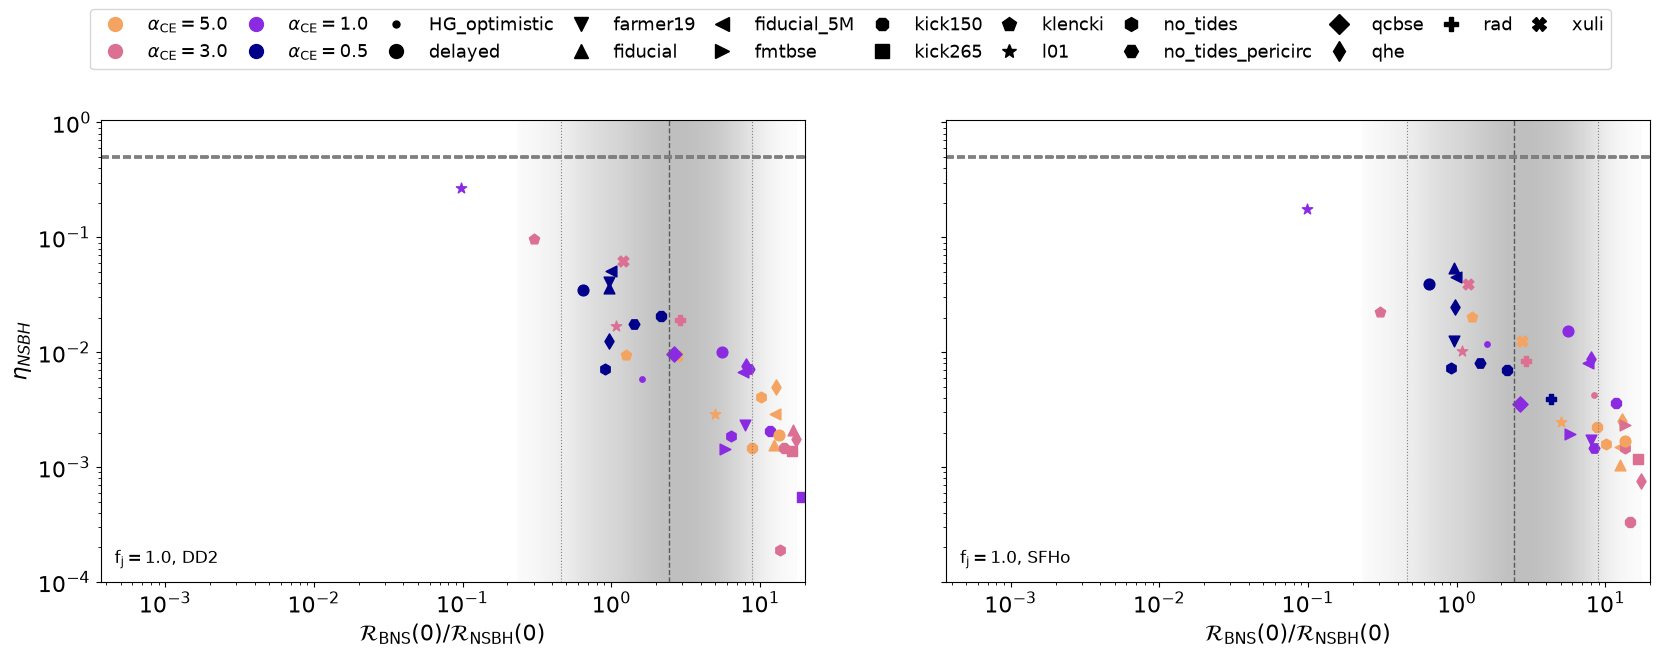

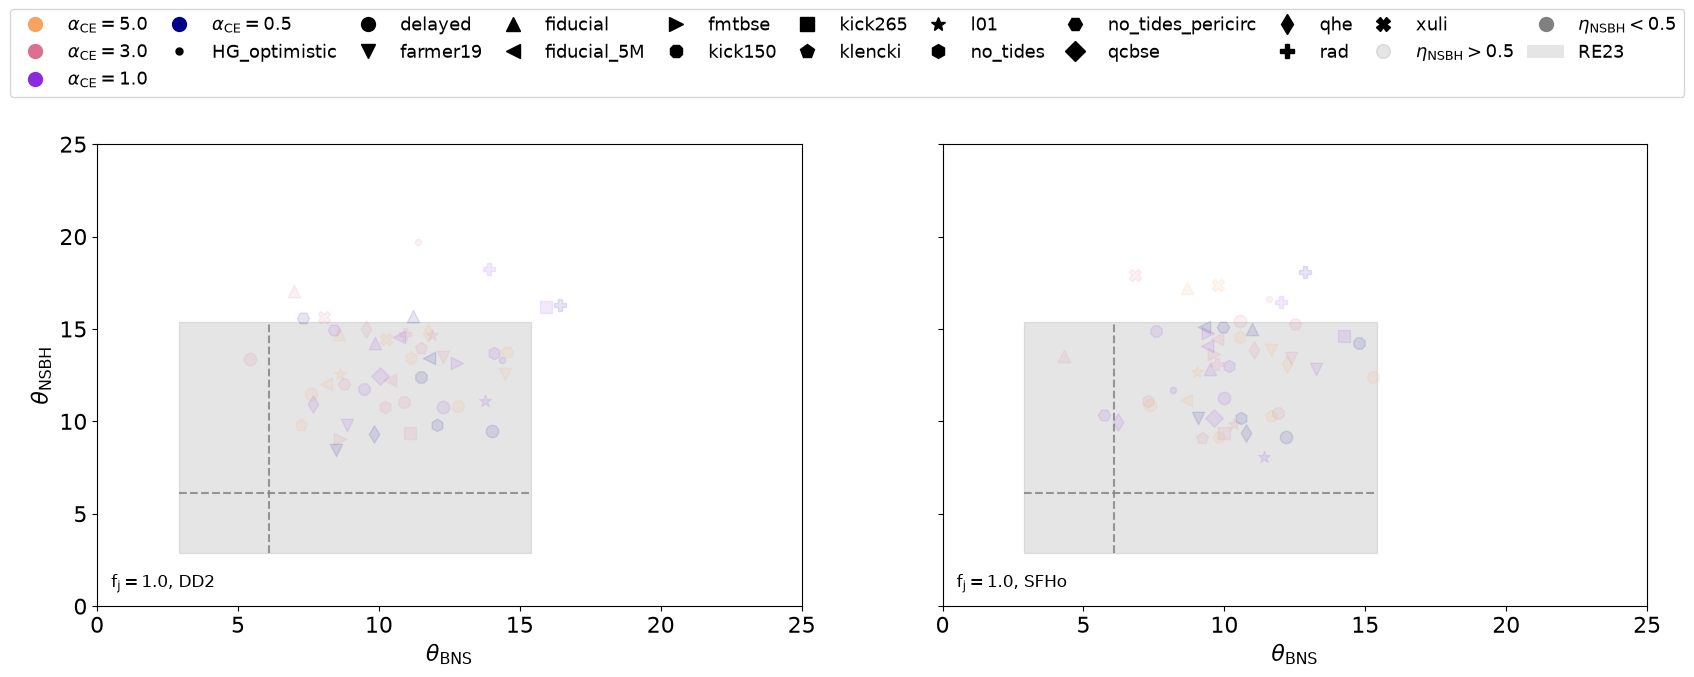

In [63]:
from itertools import product

def model_is_problematic(pop, alpha):
    vals = LOG_NORMAL_COMPATIBLE.get(pop, {})
    return bool(vals) and vals.get(alpha, False) is False

def passes_model_group(pop, alpha, model_group):
    if model_group == "all":
        return True
    if model_group == "problematic":
        return model_is_problematic(pop, alpha)
    if model_group == "okay":
        return not model_is_problematic(pop, alpha)
    raise ValueError(f"Unknown MODEL_GROUP: {model_group}")

def gwtc_ok(bns_rate, nsbh_rate):
    return (
        (GWTC_5[0] <= bns_rate <= GWTC_5[1])
        and (GWTC_5_NSBH[0] <= nsbh_rate <= GWTC_5_NSBH[1])
    )

def plot_eta_vs_bns_local_rate(fj_bsn, gwtc_only, model_group):
    fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
    nsbh_index = {nsbh_series: i for i, nsbh_series in enumerate(NSBH_AFFIX)}

    for pop, alpha, nsbh_series in product(selected_populations, POSSIBLE_ALPHAS, NSBH_AFFIX):
        key = (pop, alpha, fj_bsn, nsbh_series)
        data = eta_dict[key]
        bns_local_rate = data["bns_local_rate"][1]
        nsbh_local_rate = data["nsbh_local_rate"][1]
        eta_nsbh_50 = data["eta_nsbh"][0]

        if not passes_model_group(pop, alpha, model_group):
            continue

        alpha_key = str(alpha).replace("_", ".").replace("A", "")
        opacity = 1.0 if (not gwtc_only or gwtc_ok(bns_local_rate, nsbh_local_rate)) else 0.2

        axes[nsbh_index[nsbh_series]].scatter(
            bns_local_rate,
            eta_nsbh_50,
            marker=MODEL_MARKERS[pop],
            color=ALPHA_COLORS[alpha_key],
            alpha=opacity,
            s=60,
        )

    axes[0].text(0.02, 0.03, rf"$\rm f_j = {fj_bsn}$, DD2", transform=axes[0].transAxes,
                 fontsize=FONTSIZE-4, verticalalignment='bottom', horizontalalignment='left')
    axes[1].text(0.02, 0.03, rf"$\rm f_j = {fj_bsn}$, SFHo", transform=axes[1].transAxes,
                 fontsize=FONTSIZE-4, verticalalignment='bottom', horizontalalignment='left')

    axes[0].fill_between(GWTC_5, [0, 0], [1, 1], color='gray', alpha=0.2)
    axes[1].fill_between(GWTC_5, [0, 0], [1, 1], color='gray', alpha=0.2)
    axes[0].set_yscale('log')
    axes[0].set_ylim(1e-4, 1)
    axes[0].set_xlim(minimum_bns_local_rate * 0.95, maximum_bns_local_rate * 1.05)
    axes[1].set_xlim(minimum_bns_local_rate * 0.95, maximum_bns_local_rate * 1.05)
    axes[0].set_xscale('log')
    axes[1].set_xscale('log')
    axes[0].set_xlabel(r"$\mathcal{R}_{\rm BNS}(0)$ [Gpc$^{-3}$ yr$^{-1}$]")
    axes[1].set_xlabel(r"$\mathcal{R}_{\rm BNS}(0)$ [Gpc$^{-3}$ yr$^{-1}$]")
    axes[0].set_ylabel(r"$\eta_{NSBH}$")

    gwtc_rect = Rectangle((GWTC_5[0], 0), GWTC_5[1] - GWTC_5[0], 1,
                          facecolor='gray', alpha=0.2, label='GWTC-5 (90% CI)')
    fig.legend(handles=alpha_handles + [gwtc_rect] + model_handles,
               loc="upper center", ncol=11, bbox_to_anchor=(0.5, 1.08),
               fontsize=FONTSIZE - 3, columnspacing=0.6)

    save_figure(fig, "eta_nsbh_vs_bns_local_rate", fj_bsn,
                gwtc_only=gwtc_only, model_group=model_group)
    plt.show()

ratio_edges, density, q05, q50, q95, ratio_cmap = prep_ratio_posterior()
def plot_ratio_vs_eta(fj_bsn, gwtc_only, model_group):
    fig, axes = plt.subplots(1, len(NSBH_AFFIX), figsize=(10 * len(NSBH_AFFIX), 6), sharey=True)
    nsbh_index = {nsbh_series: i for i, nsbh_series in enumerate(NSBH_AFFIX)}

    for pop, alpha, nsbh_series in product(selected_populations, POSSIBLE_ALPHAS, NSBH_AFFIX):
        key = (pop, alpha, fj_bsn, nsbh_series)
        data = eta_dict[key]
        bns_local_rate = data["bns_local_rate"][1]
        nsbh_local_rate = data["nsbh_local_rate"][1]
        eta_nsbh_50 = data["eta_nsbh"][0]

        if not passes_model_group(pop, alpha, model_group):
            continue

        rate_ratio = bns_local_rate / nsbh_local_rate
        alpha_key = str(alpha).replace("_", ".").replace("A", "")
        opacity = 1.0 if (not gwtc_only or gwtc_ok(bns_local_rate, nsbh_local_rate)) else 0.2

        k = nsbh_index[nsbh_series]
        axes[k].scatter(
            rate_ratio,
            eta_nsbh_50,
            marker=MODEL_MARKERS[pop],
            color=ALPHA_COLORS[alpha_key],
            alpha=opacity,
            s=60,
        )
        axes[k].axhline(y=ETA_THRESHOLD, color='gray', linestyle='--', alpha=0.8)

    fig.legend(handles=alpha_handles + model_handles,
               loc="upper center", ncol=11, bbox_to_anchor=(0.5, 1.08),
               fontsize=FONTSIZE - 3, columnspacing=0.5)

    axes[0].text(0.02, 0.03, rf"$\rm f_j = {fj_bsn}$, DD2", transform=axes[0].transAxes,
                 fontsize=FONTSIZE-4, verticalalignment='bottom', horizontalalignment='left')
    axes[1].text(0.02, 0.03, rf"$\rm f_j = {fj_bsn}$, SFHo", transform=axes[1].transAxes,
                 fontsize=FONTSIZE-4, verticalalignment='bottom', horizontalalignment='left')
    axes[0].set_yscale('log')
    axes[0].set_ylim(1e-4, 1.05)
    axes[0].set_xlim(minimum_rate_ratio * 0.95, maximum_rate_ratio * 1.05)
    axes[1].set_xlim(minimum_rate_ratio * 0.95, maximum_rate_ratio * 1.05)
    axes[0].set_xscale('log')
    axes[1].set_xscale('log')
    axes[0].set_xlabel(r"$\mathcal{R}_{\rm BNS}(0) / \mathcal{R}_{\rm NSBH}(0)$")
    axes[1].set_xlabel(r"$\mathcal{R}_{\rm BNS}(0) / \mathcal{R}_{\rm NSBH}(0)$")
    axes[0].set_ylabel(r"$\eta_{NSBH}$")

    for ax in np.atleast_1d(axes).ravel():
        ax.pcolormesh(
            ratio_edges, [0, 1], density[None, :],
            transform=ax.get_xaxis_transform(),
            cmap=ratio_cmap, vmin=0, vmax=density.max(),
            shading="flat", edgecolors="none", antialiased=False,
            rasterized=True, zorder=0,
        )

        for bound in (q05, q95):
            ax.axvline(bound, color="0.5", ls=":", lw=0.8, zorder=1)

        ax.axvline(q50, color="0.35", ls="--", lw=1, zorder=1)

    save_figure(fig, "eta_nsbh_vs_bns_nsbh_local_rate_ratio", fj_bsn,
                gwtc_only=gwtc_only, model_group=model_group)
    plt.show()

def plot_theta_scatter(fj_bsn, gwtc_only, model_group):
    fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

    for pop, alpha, nsbh_series in product(selected_populations, POSSIBLE_ALPHAS, NSBH_AFFIX):
        alpha_key = str(alpha).replace("_", ".").replace("A", "")
        point_color = ALPHA_COLORS[alpha_key]
        point_marker = MODEL_MARKERS[pop]

        key = (pop, alpha, fj_bsn, nsbh_series)
        if not passes_model_group(pop, alpha, model_group):
            continue

        theta_bns = angle_vals[key]["theta_bns"]
        theta_nsbh = angle_vals[key]["theta_nsbh"]
        eta_nsbh_50 = eta_dict[key]["eta_nsbh"][0]
        point_alpha = 1.0 if eta_nsbh_50 > ETA_THRESHOLD else 0.1

        bns_local_rate = eta_dict[key]["bns_local_rate"][1]
        nsbh_local_rate = eta_dict[key]["nsbh_local_rate"][1]
        if gwtc_only and not gwtc_ok(bns_local_rate, nsbh_local_rate): continue

        k = 0 if nsbh_series == "NSBH_DD2_uniform_chi_0_1" else 1
        axes[k].scatter(
            theta_bns,
            theta_nsbh,
            marker=point_marker,
            color=point_color,
            alpha=point_alpha,
            s=80,
        )

    for ax, series_label in zip(axes, ["DD2", "SFHo"]):
        ax.fill_between(RE23, [RE23[0], RE23[0]], [RE23[1], RE23[1]], color="gray", alpha=0.2, zorder=0)
        ax.vlines(RE23_MEDIAN, RE23[0], RE23[1], color="gray", linestyle="--", alpha=0.8)
        ax.hlines(RE23_MEDIAN, RE23[0], RE23[1], color="gray", linestyle="--", alpha=0.8)
        ax.set_xlim(0, 25)
        ax.set_ylim(0, 25)
        ax.set_xlabel(r"$\theta_{\rm BNS}$")
        ax.text(0.02, 0.03, rf"$\rm f_j = {fj_bsn}$, {series_label}",
                transform=ax.transAxes, fontsize=FONTSIZE - 4,
                verticalalignment='bottom', horizontalalignment='left')

    axes[0].set_ylabel(r"$\theta_{\rm NSBH}$")

    re23_handle = Rectangle((0, 0), 1, 1, facecolor="gray", alpha=0.2, label="RE23")
    fig.legend(handles=(alpha_handles + model_handles + transparency_handles + [re23_handle]),
               loc="upper center", ncol=11, bbox_to_anchor=(0.5, 1.12),
               fontsize=FONTSIZE - 3, columnspacing=0.7)

    save_figure(fig, "theta_nsbh_vs_theta_bns", fj_bsn,
                gwtc_only=gwtc_only, model_group=model_group)
    plt.show()

# ---- run all combinations ----
for fj_bsn in FJ_LIST:
    for gwtc_only in [True, False]:
        for model_group in ["all", "problematic", "okay"]:
            plot_eta_vs_bns_local_rate(fj_bsn, gwtc_only, model_group)
            plot_ratio_vs_eta(fj_bsn, gwtc_only, model_group)
            plot_theta_scatter(fj_bsn, gwtc_only, model_group)